**Instaling libraries**

In [1]:
!pip install geopandas rasterio rasterstats rioxarray shapely numpy pandas matplotlib seaborn adjustText


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Importing libraries**

In [2]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
BASE_DIR = Path(".").resolve()

# Set paths to subfolders
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"

# Create output folder automatically if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project initialized inside: {BASE_DIR.name}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project initialized inside: geo_project
Data directory: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\data
Output directory: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output


**Loading dataset**

In [4]:
csv_path = DATA_DIR / "Data_Chtouka_Reduced.csv"
df = pd.read_csv(csv_path)


**Display the first 5 rows of the dataset**

---




In [5]:
df.head()

,Unnamed: 0,code.x,date,longitude,latitude,t,p_h,ec
0,1,471/69,1986-05-30,99750,372800,24.0,7.35,1230.0
1,2,4897/70,1986-06-03,122800,366750,25.0,7.25,840.0
2,3,1131/69,1986-05-30,99110,347700,23.0,7.40,980.0
3,4,972/69,1986-05-30,97250,379000,23.5,7.70,530.0
4,5,5774/70,1986-05-31,109070,351200,23.0,7.55,1430.0


**Display the last 5 rows of the dataset**

In [6]:
df.tail()

,Unnamed: 0,code.x,date,longitude,latitude,t,p_h,ec
405,406,1205/78,2025-03-09,100481,328465,22.6,7.8,8470.0
406,407,1210/78,2025-03-08,95550,331550,20.1,7.9,6430.0
407,408,471/69,2025-02-10,99700,372700,21.0,7.6,1363.0
408,409,Domaine Lakhrarza,2025-02-10,122445,381359,24.0,7.6,1450.0
409,410,6187/70,2025-02-13,121852,383597,25.0,7.8,2590.0


**Display summary statistics of numerical variables**

In [7]:
df.describe()

,Unnamed: 0,longitude,latitude,t,p_h,ec
count,410.000000,410.000000,410.000000,179.000000,178.000000,404.000000
mean,205.500000,107752.234146,356526.426829,22.892179,7.458258,1826.727723
std,118.501055,10168.080965,12498.954575,2.971616,0.363625,2069.130107
min,1.000000,88118.000000,328465.000000,16.100000,6.250000,420.000000
25%,103.250000,99750.000000,347700.000000,21.000000,7.250000,810.000000
50%,205.500000,108250.000000,355781.000000,23.000000,7.480000,1051.000000
75%,307.750000,117284.000000,366380.000000,25.000000,7.687500,1931.500000
max,410.000000,126800.000000,383597.000000,30.500000,8.550000,16200.000000


**Overview of the dataset structure and missing values**

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  410 non-null    int64  
 1   code.x      410 non-null    str    
 2   date        410 non-null    str    
 3   longitude   410 non-null    int64  
 4   latitude    410 non-null    int64  
 5   t           179 non-null    float64
 6   p_h         178 non-null    float64
 7   ec          404 non-null    float64
dtypes: float64(3), int64(3), str(2)
memory usage: 25.8 KB


**Convert date from object type to datetime for proper date handling**

In [9]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

**Verify that date column has been successfully converted to datetime type**

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  410 non-null    int64         
 1   code.x      410 non-null    str           
 2   date        410 non-null    datetime64[us]
 3   longitude   410 non-null    int64         
 4   latitude    410 non-null    int64         
 5   t           179 non-null    float64       
 6   p_h         178 non-null    float64       
 7   ec          404 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(3), str(1)
memory usage: 25.8 KB


**Remove unnecessary column**


In [11]:
df = df.drop(columns=['Unnamed: 0'])

**Checking the column drop**

In [12]:
df.columns

Index(['code.x', 'date', 'longitude', 'latitude', 't', 'p_h', 'ec'], dtype='str')

**Count missing values in each column**

In [13]:
df.isna().sum()

code.x         0
date           0
longitude      0
latitude       0
t            231
p_h          232
ec             6
dtype: int64

**Sort DataFrame by code and date, then reset index**

In [14]:
df = df.sort_values(by=['code.x', 'date']).reset_index(drop=True)

**Verify that the index has been reset correctly after sorting the DataFrame**

In [15]:
df.head()

,code.x,date,longitude,latitude,t,p_h,ec
0,1018/69,2002-03-20,88325,339760,17.0,7.52,3800.0
1,1018/69,2003-01-01,88325,339750,NaN,NaN,1876.0
2,1018/69,2004-01-01,88325,339750,NaN,NaN,1853.0
3,1018/69,2010-01-01,88325,339750,NaN,NaN,2550.0
4,1018/69,2022-01-01,88325,339750,16.1,7.60,2132.0


**Verify data types and confirm missing values have been handled**

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   code.x     410 non-null    str           
 1   date       410 non-null    datetime64[us]
 2   longitude  410 non-null    int64         
 3   latitude   410 non-null    int64         
 4   t          179 non-null    float64       
 5   p_h        178 non-null    float64       
 6   ec         404 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(1)
memory usage: 22.6 KB


**Creating year column**

In [17]:
df['year'] = df['date'].dt.year

### **Create descriptive summary**

In [18]:
summary = {
    "Number of rows": len(df),
    "Number of wells": df['code.x'].nunique(),
    "Start date": df['date'].min(),
    "End date": df['date'].max(),
    "Missing values": df.isna().sum().to_dict(),
    "Mean EC": df['ec'].mean(),
    "Min EC": df['ec'].min(),
    "Max EC": df['ec'].max()
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

summary_df

,Metric,Value
0,Number of rows,410
1,Number of wells,94
2,Start date,1986-05-30 00:00:00
3,End date,2025-08-18 00:00:00
4,Missing values,"{'code.x': 0, 'date': 0, 'longitude': 0, 'lati..."
5,Mean EC,1826.727723
6,Min EC,420.0
7,Max EC,16200.0


**Saving the dataframe file**

In [19]:
 # Create the output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define save path using pathlib
save_path = OUTPUT_DIR / "Summary_Salinity_Data.csv"

# Save the DataFrame to CSV
summary_df.to_csv(save_path, index=False)
print(f"File successfully saved at: {save_path}")

File successfully saved at: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\Summary_Salinity_Data.csv


**Convert to a GeoDataFrame**

In [20]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs="EPSG:26192"
)

**Save original values to compare**

In [21]:
old_long = df['longitude'].iloc[0]
old_lat = df['latitude'].iloc[0]

**Transform to WGS84 (EPSG:4326)**

In [22]:
gdf = gdf.to_crs("EPSG:4326")
new_long = gdf.geometry.x.iloc[0]
new_lat = gdf.geometry.y.iloc[0]

**Checking value have transform**

In [23]:
print(f"Well 1 Before: {old_long}, {old_lat} (Meters)")
print(f"Well 1 After:  {new_long:.4f}, {new_lat:.4f} (Degrees)")

Well 1 Before: 88325, 339760 (Meters)
Well 1 After:  -9.6671, 29.9879 (Degrees)


**Save the processed data as a CSV file in the output folder**

In [24]:
# Create the output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define the file path using pathlib
save_path = OUTPUT_DIR / "Processed_qgis_Data.csv"

# Save the file (index=False prevents adding an extra row number column)
gdf.to_csv(save_path, index=False)
print(f"File successfully saved at: {save_path}")

File successfully saved at: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\Processed_qgis_Data.csv


**Clean and format the QGIS dataset by parsing coordinates, formatting dates, cleaning columns, and exporting it as a GEE-ready CSV**

In [25]:
import pandas as pd
from shapely import wkt

# Load the file
save_path = OUTPUT_DIR / "Processed_qgis_Data.csv"
df_new = pd.read_csv(save_path)

# 1. Extract correct WGS84 lat/lon from the geometry column
df_new['geometry_parsed'] = df_new['geometry'].apply(wkt.loads)
df_new['longitude_wgs84'] = df_new['geometry_parsed'].apply(lambda p: p.x)
df_new['latitude_wgs84']  = df_new['geometry_parsed'].apply(lambda p: p.y)

# 2. Rename code.x to well_code (GEE doesn't allow dots)
#df = df.rename(columns={'code.x': 'well_code'})

# 3. Make sure date is clean YYYY-MM-DD format
df_new['date'] = pd.to_datetime(df_new['date']).dt.strftime('%Y-%m-%d')

# 4. Drop old wrong lat/lon and geometry column
df_new = df_new.drop(columns=['longitude', 'latitude', 'geometry', 'geometry_parsed'])

# 5. Rename the new columns to longitude / latitude for GEE
df_new = df_new.rename(columns={'longitude_wgs84': 'longitude', 'latitude_wgs84': 'latitude'})

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_path = OUTPUT_DIR / "Wells_Chtouka_GEE_Ready.csv"

# Use na_rep='NA' and fillna('NA') for explicit missing value representation in CSV
df_new = df_new.fillna("NA")
df_new.to_csv(output_path, index=False, na_rep="NA")

print("✅ Done!")
print("Columns:", df_new.columns.tolist())
print(df_new.head())

✅ Done!
Columns: ['code.x', 'date', 't', 'p_h', 'ec', 'year', 'longitude', 'latitude']
    code.x        date     t   p_h      ec  year  longitude   latitude
0  1018/69  2002-03-20  17.0  7.52  3800.0  2002  -9.667129  29.987872
1  1018/69  2003-01-01    NA    NA  1876.0  2003  -9.667125  29.987782
2  1018/69  2004-01-01    NA    NA  1853.0  2004  -9.667125  29.987782
3  1018/69  2010-01-01    NA    NA  2550.0  2010  -9.667125  29.987782
4  1018/69  2022-01-01  16.1   7.6  2132.0  2022  -9.667125  29.987782


**Reading limite shape file**

In [26]:
path_limite = DATA_DIR / "DataBaseChtoukaFinal_WGS" / "Limite" / "00_LimiteChtoukaWGS.shp"

**Read the boundary (limite) shapefile from the specified file path**

In [27]:
limite = gpd.read_file(path_limite)
print(limite.crs)

EPSG:4326


**Load geology shapefile and convert to WGS84 (EPSG:4326)**

In [28]:
path_geologie=DATA_DIR / "GeologyBuffer_new" / "Geology.shp"
geologie = gpd.read_file(path_geologie)
geologie = geologie.to_crs("EPSG:4326")


**Display all column names in the geologie DataFrame**

In [29]:
print(geologie.columns)

Index(['OBJECTID', 'AREA', 'PERIMETER', 'R_MOS2_', 'R_MOS2_ID', 'POLY_',
       'SUBCLASS', 'SUBCLASS_', 'RINGS_OK', 'RINGS_NOK', 'ID', 'GRIDCODE',
       'CODE', 'CODE_DESCR', 'CODE_DES_1', 'SHAPE_LENG', 'IGDS_TEXT', 'desc_',
       'Shape_Le_1', 'Shape_Area', 'geometry'],
      dtype='str')


**Show the first few rows of the geologie DataFrame**

In [30]:
print(geologie.head())

   OBJECTID         AREA    PERIMETER  R_MOS2_  R_MOS2_ID  POLY_ SUBCLASS  \
0         1   518427.700  3115599.774      0.0        0.0    0.0     None   
1         2  5784457.390   434873.942      0.0        0.0    0.0     None   
2         3  5928460.532   112568.612      0.0        0.0    0.0     None   
3         4  8858462.330   103751.971      0.0        0.0    0.0     None   
4         5  6269590.073    97739.803      0.0        0.0    0.0     None   

   SUBCLASS_  RINGS_OK  RINGS_NOK  ...  GRIDCODE  CODE  \
0        0.0         0          0  ...       0.0  None   
1        0.0         0          0  ...       0.0  None   
2        0.0         0          0  ...       0.0  None   
3        0.0         0          0  ...       0.0  None   
4        0.0         0          0  ...       0.0  None   

                                          CODE_DESCR  \
0  ÕÎæÑ ÑÓæÈíÉ ÇáÈÑæÊíÑæÒæí ÇáÇæÓØ-ÇáÚáæí (ÇáÌÒÁ ...   
1                        ÕÎæÑ ÑÓæÈíÉ  ÇáåæáæÓíä äåÑí   
2                   

**Load farm data, convert to WGS84 coordinate system, and display its columns and first rows**

In [31]:
path_farms = DATA_DIR / "DataBaseChtoukaFinal_WGS" / "FermesIrriguéesDessalemen" / "04_FermesIrriguéesDessalemen.shp"
farms = gpd.read_file(path_farms).to_crs("EPSG:4326")

print(farms.columns)
print(farms.head())

Index(['OID_', 'Name', 'FolderPath', 'SymbolID', 'AltMode', 'Base', 'Snippet',
       'PopupInfo', 'HasLabel', 'LabelID', 'geometry'],
      dtype='str')
   OID_         Name                FolderPath  SymbolID  AltMode  Base  \
0     0   CU_471 (1)  Document/centre_parcelle         0       -1   0.0   
1     0  CU_292 (F5)  Document/centre_parcelle         0       -1   0.0   
2     0    CU_40 (2)  Document/centre_parcelle         0       -1   0.0   
3     0    CU_55 (1)  Document/centre_parcelle         0       -1   0.0   
4     0   CU_458 (8)  Document/centre_parcelle         0       -1   0.0   

  Snippet PopupInfo  HasLabel  LabelID                       geometry  
0    None      None        -1        0  POINT Z (-9.50086 30.18332 0)  
1    None      None        -1        0   POINT Z (-9.3303 30.14531 0)  
2    None      None        -1        0  POINT Z (-9.51908 30.14369 0)  
3    None      None        -1        0  POINT Z (-9.54068 30.09039 0)  
4    None      None        -1      

**Load wells and boreholes data, convert to WGS84 coordinate system, and display its columns and first rows**

In [32]:
path_wells_bareholes= DATA_DIR / "DataBaseChtoukaFinal_WGS" / "Wells_Bareholes" / "05_Wells and Bareholes.shp"
wells_bareholes= gpd.read_file(path_wells_bareholes).to_crs("EPSG:4326")
print(wells_bareholes.columns)
print(wells_bareholes.head())

Index(['OBJECTID', 'Id', 'geometry'], dtype='str')
   OBJECTID  Id                   geometry
0         1   0  POINT (-9.52674 29.93615)
1         2   0    POINT (-9.529 29.94141)
2         3   0  POINT (-9.53504 29.93945)
3         4   0    POINT (-9.53512 29.943)
4         5   0  POINT (-9.53716 29.94299)


**Load irrigated perimeters data, convert to WGS84 coordinate system, and display its columns and first rows**

In [33]:
path_perimeters= DATA_DIR / "DataBaseChtoukaFinal_WGS" / "Irrigated_perimeters_Fig6&7" / "06_Irrigated_perimeters_Fig6&7.shp"
perimeters = gpd.read_file(path_perimeters).to_crs("EPSG:4326")

print(perimeters.columns)
print(perimeters.head())

Index(['OBJECTID', 'FID_MassaU', 'OBJECTID_1', 'Shape_Leng', 'Name',
       'FID_Expans', 'Id', 'Shape_Le_1', 'Shape_Area', 'geometry'],
      dtype='str')
   OBJECTID  FID_MassaU  OBJECTID_1  Shape_Leng                          Name  \
0         1           0           1    1.012743               Massa perimeter   
1         2           1           2    0.448015       Traditional Agriculture   
2         3           2           3    0.678030             Private perimeter   
3         4           3           4    0.802534                 National parc   
4         5          -1           0    0.000000  Expansion private Irrigation   

   FID_Expans  Id  Shape_Le_1  Shape_Area  \
0          -1   0    1.013277    0.037978   
1          -1   0    0.448015    0.003011   
2          -1   0    0.677760    0.020364   
3          -1   0    0.802570    0.015155   
4           0   0    1.272449    0.015020   

                                            geometry  
0  POLYGON ((-9.36991 30.11452,

**Load soil types data, convert to WGS84 coordinate system, and display its columns and first rows**

In [34]:
path_soil = DATA_DIR/"SoilType_latest_one"/"SoilTypesChtoukaBuffer10km_f.shp"
soil = gpd.read_file(path_soil).to_crs("EPSG:4326")

# See what columns we have
print(soil.columns)
#  display first 5 rows
print(soil.head())

Index(['OBJECTID', 'FID_Raster', 'Id', 'gridcode', 'FID_solsm6', 'Row', 'Name',
       'Couleur', 'Classifica', 'Classifi_1', 'TEXTURE', 'Shape_Leng',
       'Shape_Area', 'geometry'],
      dtype='str')
   OBJECTID  FID_Raster  Id  gridcode  FID_solsm6  Row   Name Couleur  \
0        10          -1   0         0          11   13     16       j   
1        11          -1   0         0          49    0      6       j   
2        12          -1   0         0         113    0  41+47       o   
3        13          -1   0         0         116    0      7       r   
4        14          -1   0         0         204  823  20+24       r   

                                          Classifica  \
0  CARBONATES : sables et limons calcaires sur gr...   
1  EOLIENS : sables et limons calcaires / EOLIENS...   
2  SOLS POLYGENIQUES-POLYPHASES et ASSOCIATION DE...   
3  ALLUVIAUX : sables et limons calcaires faiblem...   
4  SOLS POLYGENIQUES-POLYPHASES et ASSOCIATION DE...   

                    

**Count and display the top 10 wells with the most years of available data**

In [35]:
# This shows you how many years of data you have for each well
evolution_counts = df.groupby('code.x')['year'].nunique().sort_values(ascending=False)
print("Wells with the most years of data:")
print(evolution_counts.head(10))

Wells with the most years of data:
code.x
471/69     15
4897/70    15
4130/70    14
5463/70    13
1037/69    11
1205/78    10
1280/70     9
4302/70     7
4210/70     7
4209/70     7
Name: year, dtype: int64


**Clean the dates and well IDs to count how many years of data each well has**

In [36]:
import pandas as pd

# 1. Force reload the core data to bypass any farm spatial errors or missing columns
#df = pd.read_csv("Data_Chtouka_Reduced.csv")

# 2. Handle your date types and construct the clean 'year' column 
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year

# 3. Clean the well codes column to prevent spacing issues
df['code.x'] = df['code.x'].astype(str).str.strip()

# 4. Run the data grouping directly on your base dataset (without farm influences)
evolution_counts = df.groupby('code.x')['year'].nunique().sort_values(ascending=False)
print("Wells with the most years of data:")
print(evolution_counts.head(10))

Wells with the most years of data:
code.x
471/69     15
4897/70    15
4130/70    14
5463/70    13
1037/69    11
1205/78    10
1280/70     9
4302/70     7
4210/70     7
4209/70     7
Name: year, dtype: int64


**Plot the salinity trend over time for the well with the most data**

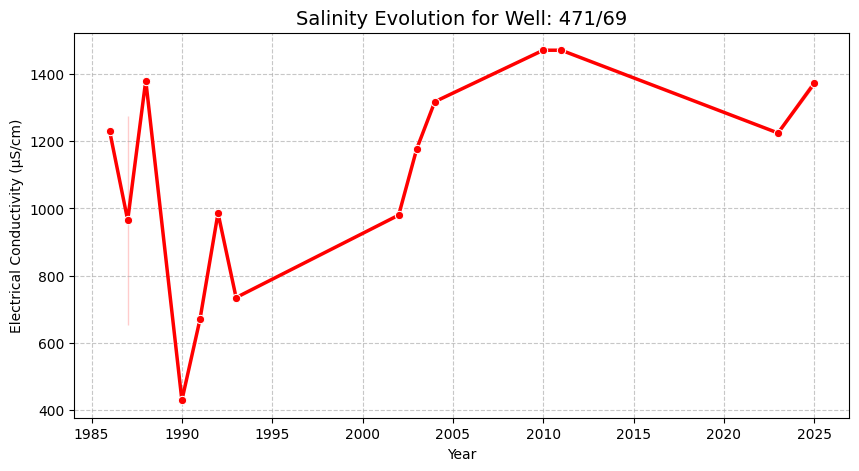

In [37]:
# Pick one specific well that has many years of data
target_well = evolution_counts.index[0]
well_data = df[df['code.x'] == target_well].sort_values('year')

plt.figure(figsize=(10, 5))
sns.lineplot(data=well_data, x='year', y='ec', marker='o', color='red', linewidth=2.5)

plt.title(f"Salinity Evolution for Well: {target_well}", fontsize=14)
plt.ylabel("Electrical Conductivity (µS/cm)")
plt.xlabel("Year")
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

**Load desalination network data, convert to WGS84 coordinate system, and display its columns and first rows**

In [38]:
path_desalinization = DATA_DIR/"DataBaseChtoukaFinal_WGS"/"Desalinization_Network"/"08_Reseau_dessalement.shp"
desalination = gpd.read_file(path_desalinization).to_crs("EPSG:4326")

# See what columns we have
print(desalination.columns)
#  display first 5 rows
print(desalination.head())


Index(['Id', 'geometry'], dtype='str')
   Id                                           geometry
0   0  LINESTRING (-9.64608 30.13812, -9.64223 30.137...
1   0   LINESTRING (-9.47019 30.13848, -9.52491 30.1402)
2   0   LINESTRING (-9.46885 30.15752, -9.4919 30.15656)
3   0  LINESTRING (-9.60285 30.17238, -9.60084 30.166...
4   0  LINESTRING (-9.55193 30.18618, -9.55107 30.17152)


**Load a landcover raster file, reproject it to WGS84, and display its structure**

In [39]:
import rioxarray

path_landcover2017 = DATA_DIR/"DataBaseChtoukaFinal_WGS"/"LULC_10m_2024_2017"/"Landcover2017"/"Landcover2017.tif"

# Open the raster file
landcover2017 = rioxarray.open_rasterio(path_landcover2017)

# Reproject to EPSG:4326 if needed
landcover2017_4326 = landcover2017.rio.reproject("EPSG:4326")

# View the data structure
print(landcover2017_4326)

<xarray.DataArray (band: 1, y: 6465, x: 5306)> Size: 34MB
array([[[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]]],
      shape=(1, 6465, 5306), dtype=uint8)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 52kB 30.39 30.39 30.39 30.39 ... 29.77 29.77 29.77
  * x            (x) float64 42kB -9.683 -9.683 -9.683 ... -9.168 -9.168 -9.167
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:           Area
    RepresentationType:      THEMATIC
    STATISTICS_COVARIANCES:  7.840751302169743
    STATISTICS_MAXIMUM:      11
    STATISTICS_MEAN:         8.2143245114085
    STATISTICS_MINIMUM:      1
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       2.8001341578878
    scale_factor:            1.0


**Load DEM raster data, reproject it to WGS84, and display its structure**

In [40]:
path_demf = DATA_DIR/"DataBaseChtoukaFinal_WGS"/"demf"/"01_demfChtouka.tif"
# Open the raster file
demf = rioxarray.open_rasterio(path_demf)

# Reproject to EPSG:4326 if needed
demf_4326 = landcover2017.rio.reproject("EPSG:4326")

# View the data structure
print(demf_4326)

<xarray.DataArray (band: 1, y: 6465, x: 5306)> Size: 34MB
array([[[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]]],
      shape=(1, 6465, 5306), dtype=uint8)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 52kB 30.39 30.39 30.39 30.39 ... 29.77 29.77 29.77
  * x            (x) float64 42kB -9.683 -9.683 -9.683 ... -9.168 -9.168 -9.167
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:           Area
    RepresentationType:      THEMATIC
    STATISTICS_COVARIANCES:  7.840751302169743
    STATISTICS_MAXIMUM:      11
    STATISTICS_MEAN:         8.2143245114085
    STATISTICS_MINIMUM:      1
    STATISTICS_SKIPFACTORX:  1
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       2.8001341578878
    scale_factor:            1.0


**Count nearby farms within 500m of each well, merge the count into the main dataset, and save it as a CSV.**

In [41]:
import geopandas as gpd
import pandas as pd

# 2. PROJECTION: Ensure we are in meters (EPSG:26191) for the 500m buffer
wells_projected = gdf.to_crs(epsg=26191)
farms_projected = farms.to_crs(epsg=26191)

# 3. BUFFER & COUNT: Use unique wells to save memory/time
unique_wells = wells_projected.drop_duplicates(subset=['code.x']).copy()
unique_wells['geometry'] = unique_wells.geometry.buffer(500)

# Spatial join to count farms in the 500m circle
joined = gpd.sjoin(unique_wells, farms_projected, how='left', predicate='intersects')

# Group by the well code and count the farm occurrences
# .count() ignores NaNs where no farm was found
farm_counts = joined.groupby('code.x')['index_right'].count().reset_index()
farm_counts.columns = ['code.x', 'desalinated farms 500 meter']

# 4. MERGE: Add the single clean column back to your main dataframe
df = df.merge(farm_counts, on='code.x', how='left')

# Fill wells with no nearby farms as 0
df['desalinated farms 500 meter'] = df['desalinated farms 500 meter'].fillna(0).astype(int)

# 5. SAVE: Update your CSV fileoutput_dir = 'project/output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define the file path using pathlib
save_path = OUTPUT_DIR / "well_farm_counts.csv"

# Save the file
df.to_csv(save_path, index=False)

print(f"Success! File saved at: {save_path}")
print("Success! Only 'desalinated farms 500 meter' remains.")
print(df[['code.x', 'desalinated farms 500 meter']].head())

Success! File saved at: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\well_farm_counts.csv
Success! Only 'desalinated farms 500 meter' remains.
    code.x  desalinated farms 500 meter
0  1018/69                            0
1  1018/69                            0
2  1018/69                            0
3  1018/69                            0
4  1018/69                            0


**Calculate farm counts at 500m, 2km, and 5km buffers around wells, merge the results, and save the final dataset to CSV**

In [42]:
import geopandas as gpd
import pandas as pd

# 1. CLEANING: Remove any existing "desalinated" columns to avoid duplicates
cols_to_drop = [c for c in df.columns if 'desalinated' in c.lower()]
df = df.drop(columns=cols_to_drop)
print(f"Cleaned up old columns: {cols_to_drop}")

# 2. PROJECTION: Ensure we are in meters (EPSG:26191)
wells_projected = gdf.to_crs(epsg=26191)
farms_projected = farms.to_crs(epsg=26191)

# Get unique well locations for faster calculation
unique_wells_projected = wells_projected.drop_duplicates(subset=['code.x']).copy()

# 3. DEFINE DISTANCES: 500m, 2km (2000m), and 5km (5000m)
# We use a dictionary to map the distance in meters to the column name
buffer_tasks = {
    500: "desalinated farms 500m",
    2000: "desalinated farms 2km",
    5000: "desalinated farms 5km"
}

# 4. LOOP through each distance and calculate
for meters, col_name in buffer_tasks.items():
    print(f"Calculating for {col_name}...")

    # Create the specific buffer
    temp_buffer = unique_wells_projected.copy()
    temp_buffer['geometry'] = unique_wells_projected.geometry.buffer(meters)

    # Spatial join to find farms inside this buffer
    joined = gpd.sjoin(temp_buffer, farms_projected, how='left', predicate='intersects')

    # Count occurrences (ignoring NaNs)
    counts = joined.groupby('code.x')['index_right'].count().reset_index()
    counts.columns = ['code.x', col_name]

    # Merge the specific column back to the main 'df'
    df = df.merge(counts, on='code.x', how='left')
    df[col_name] = df[col_name].fillna(0).astype(int)

# Create the output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define the file path using pathlib
save_path = OUTPUT_DIR / "well_farm_counts_final.csv"

# Save the file
df.to_csv(save_path, index=False)
print(f"File successfully saved at: {save_path}")

print("Success! All buffer columns added and file saved.")
# Show a preview of the unique wells and their new counts
print(df[['code.x', 'desalinated farms 500m', 'desalinated farms 2km', 'desalinated farms 5km']].drop_duplicates().head())

Cleaned up old columns: ['desalinated farms 500 meter']
Calculating for desalinated farms 500m...
Calculating for desalinated farms 2km...
Calculating for desalinated farms 5km...
File successfully saved at: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\well_farm_counts_final.csv
Success! All buffer columns added and file saved.
     code.x  desalinated farms 500m  desalinated farms 2km  \
0   1018/69                       0                      0   
5   1019/68                       0                      0   
7   1019/69                       0                      0   
15  1037/62                       1                     12   
16  1037/69                       1                     12   

    desalinated farms 5km  
0                       0  
5                       0  
7                       0  
15                     62  
16                     62  


**Calculate regional borehole counts at 500m, 2km, and 5km buffers around study wells, merge the results, and save to CSV**

In [43]:
import geopandas as gpd
import pandas as pd

# 1. CLEANING: Remove any existing borehole buffer columns to avoid duplicates
cols_to_drop = [c for c in df.columns if 'borehole' in c.lower()]
df = df.drop(columns=cols_to_drop)
print(f"Cleaned up old borehole columns: {cols_to_drop}")

# 2. PROJECTION: Ensure both study wells and regional boreholes are in meters (EPSG:26191)
wells_projected = gdf.to_crs(epsg=26191)
boreholes_projected = wells_bareholes.to_crs(epsg=26191)

# Get unique well locations to speed up the spatial calculations
unique_wells_projected = wells_projected.drop_duplicates(subset=['code.x']).copy()

# 3. DEFINE BOREHOLE DISTANCES
# 500m, 2km (2000m), and 5km (5000m)
borehole_tasks = {
    500: "boreholes 500m",
    2000: "boreholes 2km",
    5000: "boreholes 5km"
}

# 4. LOOP through each distance and count the boreholes
for meters, col_name in borehole_tasks.items():
    print(f"Calculating {col_name}...")

    # Create the buffer for the specific distance
    temp_buffer = unique_wells_projected.copy()
    temp_buffer['geometry'] = unique_wells_projected.geometry.buffer(meters)

    # Spatial join: find which regional boreholes fall into the study well buffers
    # 'index_right' will contain the index of the borehole if it matches
    joined = gpd.sjoin(temp_buffer, boreholes_projected, how='left', predicate='intersects')

    # Group by the study well code and count actual borehole matches (ignores NaNs)
    counts = joined.groupby('code.x')['index_right'].count().reset_index()
    counts.columns = ['code.x', col_name]

    # Merge this new count column back into your main dataframe (df)
    df = df.merge(counts, on='code.x', how='left')

    # Fill wells that have 0 nearby boreholes and convert to integer
    df[col_name] = df[col_name].fillna(0).astype(int)

# Create the output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define the file path using pathlib
save_path = OUTPUT_DIR / "well_boreholes_final.csv"

# Save the file
df.to_csv(save_path, index=False)
print(f"File successfully saved at: {save_path}")
print(" Success! Borehole columns added for 500m, 2km, and 5km.")
# Display the counts for the first few unique wells to verify
print(df[['code.x', 'boreholes 500m', 'boreholes 2km', 'boreholes 5km']].drop_duplicates().head())

Cleaned up old borehole columns: []
Calculating boreholes 500m...
Calculating boreholes 2km...
Calculating boreholes 5km...
File successfully saved at: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\well_boreholes_final.csv
 Success! Borehole columns added for 500m, 2km, and 5km.
     code.x  boreholes 500m  boreholes 2km  boreholes 5km
0   1018/69               0              0             44
5   1019/68               0              0             43
7   1019/69               0              0             44
15  1037/62               2             19            158
16  1037/69               2             19            158


In [44]:
df.head()

,code.x,date,longitude,latitude,t,p_h,ec,year,desalinated farms 500m,desalinated farms 2km,desalinated farms 5km,boreholes 500m,boreholes 2km,boreholes 5km
0,1018/69,2002-03-20,88325,339760,17.0,7.52,3800.0,2002,0,0,0,0,0,44
1,1018/69,2003-01-01,88325,339750,NaN,NaN,1876.0,2003,0,0,0,0,0,44
2,1018/69,2004-01-01,88325,339750,NaN,NaN,1853.0,2004,0,0,0,0,0,44
3,1018/69,2010-01-01,88325,339750,NaN,NaN,2550.0,2010,0,0,0,0,0,44
4,1018/69,2022-01-01,88325,339750,16.1,7.60,2132.0,2022,0,0,0,0,0,44


**Calculate soil texture area percentages within 500m, 2km, and 5km buffers, normalize them to 100%, and export the ordered dataset**

In [45]:
import geopandas as gpd
import pandas as pd

# 1. PREPARE DATA
# Using a fresh copy of df to ensure no old columns exist
analysis_df = df.copy()
# Remove any existing percentage columns to avoid _x, _y duplicates
analysis_df = analysis_df.drop(columns=[c for c in analysis_df.columns if '%' in c], errors='ignore')

wells_projected = gdf.to_crs(epsg=26191)
soil_projected = soil.to_crs(epsg=26191)
unique_wells = wells_projected.drop_duplicates(subset=['code.x']).copy()

# 2. CALCULATION LOOP
distances = [500, 2000, 5000]
all_distance_results = []

for dist in distances:
    print(f"Processing {dist}m buffer...")

    # Create the buffer
    well_buffers = unique_wells.copy()
    well_buffers['geometry'] = well_buffers.geometry.buffer(dist)

    # Intersect with soil map
    soil_intersect = gpd.overlay(well_buffers, soil_projected, how='intersection')
    soil_intersect['area_m2'] = soil_intersect.geometry.area

    # --- THE NORMALIZATION FIX ---
    # Sum up the area of soil found for each well
    total_found = soil_intersect.groupby('code.x')['area_m2'].transform('sum')

    # Calculate percentage based ONLY on that found area
    soil_intersect[f'perc_{dist}m'] = (soil_intersect['area_m2'] / total_found) * 100
    # ------------------------------

    # Pivot the results
    area_sum = soil_intersect.groupby(['code.x', 'TEXTURE'])[f'perc_{dist}m'].sum().reset_index()
    pivot_df = area_sum.pivot(index='code.x', columns='TEXTURE', values=f'perc_{dist}m')
    pivot_df.columns = [f"{col}%_{dist}m" for col in pivot_df.columns]
    all_distance_results.append(pivot_df.fillna(0))

# Combine results across all distances
final_soil_stats = pd.concat(all_distance_results, axis=1).reset_index()

# ------------------------------------------------------------------
# 3. FORCE COLUMNS INTO EXISTENCE & RE-ARRANGE THEM BY DISTANCE SEQUENCE
# ------------------------------------------------------------------
# List of all possible unique soil textures in your entire study area
all_textures = ['A','AL','LS', 'LSA', 'S', 'SL', 'SLA', 'IMP', 'LA', 'LAS', 'SA', 'SAL']

# Create the ordered list of columns exactly as you requested: 
# (e.g., LS%_500m, LS%_2000m, LS%_5000m, LSA%_500m, LSA%_2000m...)
ordered_soil_columns = []
for tex in all_textures:
    for dist in distances:
        ordered_soil_columns.append(f"{tex}%_{dist}m")

# Check if any of these columns are missing in final_soil_stats, if so, add them with 0
for col in ordered_soil_columns:
    if col not in final_soil_stats.columns:
        final_soil_stats[col] = 0.0

# 4. MERGE RESULTS
# Merge to our clean analysis_df
analysis_df = analysis_df.merge(final_soil_stats, on='code.x', how='left')
analysis_df = analysis_df.fillna(0)

# 5. FINAL FORCE (Just to be 100% safe)
# This step checks every well and scales it to 100 if it's not already
for dist in distances:
    cols_for_dist = [f"{tex}%_{dist}m" for tex in all_textures]
    row_sums = analysis_df[cols_for_dist].sum(axis=1)
    # If the sum is > 0 but not 100 (like 50), scale it
    mask = (row_sums > 0) & (row_sums != 100)
    analysis_df.loc[mask, cols_for_dist] = analysis_df.loc[mask, cols_for_dist].div(row_sums[mask], axis=0) * 100

# 6. RE-ORDER ALL THE COLUMNS IN THE FINAL DATASET
# This moves the newly created soil columns next to each other in perfect distance sequence
other_cols = [c for c in analysis_df.columns if c not in ordered_soil_columns]
final_column_order = other_cols + ordered_soil_columns
analysis_df = analysis_df[final_column_order]

# Ensure output directory exists and construct path using pathlib
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
save_path = OUTPUT_DIR / "Data_Chtouka_Soil_Percentages_Corrected.csv"

analysis_df.to_csv(save_path, index=False)
print(f"File successfully saved at: {save_path}")


Processing 500m buffer...
Processing 2000m buffer...
Processing 5000m buffer...
File successfully saved at: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\Data_Chtouka_Soil_Percentages_Corrected.csv


**Calculate geological composition percentages and unique rock type counts within 500m, 2km, and 5km buffers, merge with the main dataset, and export to CSV**

In [46]:
import geopandas as gpd
import pandas as pd
import numpy as np

# 1. PREPARE DATA
analysis_df = analysis_df.copy()
 
geo_cols_to_drop = [c for c in analysis_df.columns if '_Geo%' in c or 'geo_unique_count_' in c]
analysis_df = analysis_df.drop(columns=geo_cols_to_drop, errors='ignore')

# Project geology to metric CRS
geologie_projected = geologie.to_crs(epsg=26191)
wells_projected = gdf.to_crs(epsg=26191)
unique_wells = wells_projected.drop_duplicates(subset=['code.x']).copy()


all_rock_types = sorted(list(geologie_projected['desc_'].dropna().unique()))
print(f"Total geology types found dynamically: {len(all_rock_types)}")
print("The types are:", all_rock_types)

# 2. CALCULATION LOOP
distances = [500, 2000, 5000]
all_geology_results = []

for dist in distances:
    print(f"Processing {dist}m geology buffer...")

    # Create buffer
    well_buffers = unique_wells.copy()
    well_buffers['geometry'] = well_buffers.geometry.buffer(dist)

    # Intersect with geology map
    geo_intersect = gpd.overlay(well_buffers, geologie_projected, how='intersection')
    geo_intersect['area_m2'] = geo_intersect.geometry.area

    # --- COUNT CALCULATION ---
    geo_counts = geo_intersect.groupby('code.x')['desc_'].nunique().reset_index()
    geo_counts.columns = ['code.x', f'geo_unique_count_{dist}m']

    # --- PERCENTAGE CALCULATION ---
    total_found = geo_intersect.groupby('code.x')['area_m2'].transform('sum')
    geo_intersect[f'perc_{dist}m'] = (geo_intersect['area_m2'] / total_found) * 100

    # Pivot percentages
    area_sum = geo_intersect.groupby(['code.x', 'desc_'])[f'perc_{dist}m'].sum().reset_index()
    pivot_df = area_sum.pivot(index='code.x', columns='desc_', values=f'perc_{dist}m')
    pivot_df.columns = [f"{col}_Geo%_{dist}m" for col in pivot_df.columns]

    # Merge Count and Percentages
    dist_stats = geo_counts.merge(pivot_df.reset_index(), on='code.x', how='left')
    all_geology_results.append(dist_stats.fillna(0))

# Combined all results
final_geo_stats = all_geology_results[0]
for next_result in all_geology_results[1:]:
    final_geo_stats = final_geo_stats.merge(next_result, on='code.x', how='left')

# ------------------------------------------------------------------
# 3. FORCE COLUMNS FOR ALL 7 TYPES & RE-ARRANGE BY SEQUENCE
# ------------------------------------------------------------------
ordered_geo_columns = []

for dist in distances:
    ordered_geo_columns.append(f'geo_unique_count_{dist}m')

for rock in all_rock_types:
    for dist in distances:
        ordered_geo_columns.append(f"{rock}_Geo%_{dist}m")


for col in ordered_geo_columns:
    if col not in final_geo_stats.columns:
        final_geo_stats[col] = 0.0

final_geo_stats = final_geo_stats[['code.x'] + ordered_geo_columns]

# 4. MERGE TO MAIN DATAFRAME
analysis_df = analysis_df.merge(final_geo_stats, on='code.x', how='left')
analysis_df = analysis_df.fillna(0)

# 5. SAFETY NORMALIZATION CHECK 
for dist in distances:
    cols_for_dist = [f"{rock}_Geo%_{dist}m" for rock in all_rock_types]
    row_sums = analysis_df[cols_for_dist].sum(axis=1)
    mask = (row_sums > 0) & (row_sums != 100)
    analysis_df.loc[mask, cols_for_dist] = analysis_df.loc[mask, cols_for_dist].div(row_sums[mask], axis=0) * 100

# 6. RE-ORDER DATASET COLUMNS
other_cols = [c for c in analysis_df.columns if c not in ordered_geo_columns]
final_column_order = other_cols + ordered_geo_columns
analysis_df = analysis_df[final_column_order]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
save_path = OUTPUT_DIR / "Data_Chtouka_Soil_and_Geology.csv"

analysis_df.to_csv(save_path, index=False)
print(f"File successfully saved at: {save_path}")

Total geology types found dynamically: 16
The types are: ['Calcaire lacustre', 'Cambrien moyen continental', 'Faciès marin et/ou dunaire', 'Pliocène superieur marin', 'ROCHES SEDIMENTAIRE CAMBRIEN MOYEN', 'ROCHES SEDIMENTAIRES CAMBRIEN INFERIEUR', 'ROCHES SEDIMENTAIRES CRETACE CENOMANIEN-TURONIEN', 'ROCHES SEDIMENTAIRES CRETACE SENONIEN', 'ROCHES SEDIMENTAIRES EOCENE', 'ROCHES SEDIMENTAIRES HOLOCENE EOLIEN', 'ROCHES SEDIMENTAIRES HOLOCENE FLUVIATILE', 'ROCHES SEDIMENTAIRES PALEOCENE', 'ROCHES SEDIMENTAIRES PLEISTOCENE CONTINENTAL', 'ROCHES SEDIMENTAIRES PLIOCENE', 'ROCHES SEDIMENTAIRES PROTEROZOIQUE SUPERIEUR', 'ROCHES SEDIMENTAIRES PROTEROZOIQUE SUPERIEUR (partie superieur)']
Processing 500m geology buffer...
Processing 2000m geology buffer...
Processing 5000m geology buffer...
File successfully saved at: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\Data_Chtouka_Soil_and_Geology.csv


**Calculate annual Land Use/Land Cover (LULC) percentages within 500m, 2km, 5km, and 10km buffers from yearly rasters (2017–2025), merge with the main dataset, and save to CSV**

In [47]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
from rasterstats import zonal_stats

# --- 1. SETUP ---
years = list(range(2017, 2026))
lulc_names = {1: "Water", 2: "Trees", 4: "FloodedVeg", 5: "Crops", 7: "BuiltArea", 8: "BareGround", 11: "Rangeland"}
distances = [500, 2000, 5000, 10000]

# Ensure the 'year' column is numeric
analysis_df['year'] = pd.to_numeric(analysis_df['year'], errors='coerce')

all_years_lulc_results = []

# --- 2. THE YEARLY LOOP ---
for target_year in years:
    df_year = analysis_df[analysis_df['year'] == target_year].copy()

    if df_year.empty:
        print(f"Skipping {target_year}: No data found in analysis_df.")
        continue

    num_unique_wells = len(df_year.drop_duplicates(subset=['code.x']))

    if target_year == 2025:
        use_year = 2024
        print(f"--- Processing {target_year}: {num_unique_wells} unique wells (Using {use_year} Raster) ---")
    else:
        use_year = target_year
        print(f"--- Processing {target_year}: {num_unique_wells} unique wells ---")

    # Updated path using pathlib
    raster_path = DATA_DIR / "DataBaseChtoukaFinal_WGS" / "LULC_10m_2024_2017" / f"Landcover{use_year}" / f"Landcover{use_year}.tif"
    if not os.path.exists(raster_path):
        print(f"Skipping {target_year}: Raster file not found at {raster_path}")
        continue

    gdf_wells = gpd.GeoDataFrame(
        df_year,
        geometry=gpd.points_from_xy(df_year.longitude, df_year.latitude),
        crs="EPSG:26192"
    )

    unique_wells = gdf_wells.drop_duplicates(subset=['code.x']).copy()
    unique_wells = unique_wells[unique_wells.geometry.is_valid & ~unique_wells.geometry.is_empty & unique_wells.geometry.notna()]

    for dist in distances:
        temp_buffers = unique_wells.to_crs(epsg=26191).copy()
        temp_buffers['geometry'] = temp_buffers.geometry.buffer(dist)
        temp_buffers_4326 = temp_buffers.to_crs("EPSG:4326")

        try:
            stats = zonal_stats(temp_buffers_4326, raster_path, categorical=True)
            for i, row_stats in enumerate(stats):
                if not row_stats:
                    # No pixels at all for this well/distance — still emit a row of zeros
                    # so the columns exist consistently across the whole dataset.
                    row_stats = {}

                total_pixels = sum(row_stats.values())
                well_code = temp_buffers_4326.iloc[i]['code.x']

                result_entry = {'code.x': well_code, 'year': target_year}

                # KEY FIX: loop over every known class, not just the ones that
                # happened to appear in this particular polygon. This guarantees
                # every LULC class gets a column at every buffer distance, with
                # an explicit 0% when the class truly isn't present.
                for class_id, class_name in lulc_names.items():
                    count = row_stats.get(class_id, 0)
                    col_name = f"{class_name}_{dist}m"
                    pct = round((count / total_pixels) * 100, 4) if total_pixels > 0 else 0.0
                    result_entry[col_name] = pct

                # Optional: keep any unexpected/unmapped class codes too, in case
                # your raster has values not listed in lulc_names.
                for class_id, count in row_stats.items():
                    if class_id not in lulc_names:
                        col_name = f"Class_{class_id}_{dist}m"
                        pct = round((count / total_pixels) * 100, 4) if total_pixels > 0 else 0.0
                        result_entry[col_name] = pct

                all_years_lulc_results.append(result_entry)
        except Exception as e:
            print(f"Error in {target_year} at {dist}m: {e}")

# --- 3. CONSOLIDATE ---
if all_years_lulc_results:
    lulc_df_all = pd.DataFrame(all_years_lulc_results)

    lulc_wide_all = lulc_df_all.groupby(['code.x', 'year']).first().reset_index()

    final_combined_df = analysis_df[analysis_df['year'].isin(years)].merge(
        lulc_wide_all,
        on=['code.x', 'year'],
        how='left'
    ).fillna(0)

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    save_path = OUTPUT_DIR / "Data_Chtouka_LULC_2017_2025_Final.csv"

    final_combined_df.to_csv(save_path, index=False)

    print(f"\nCOMPLETED!")
    print(f"Output saved to: {save_path}")
    print(f"Final shape: {final_combined_df.shape}")
else:
    print("\nERROR: No data processed.")

Skipping 2017: No data found in analysis_df.
Skipping 2018: No data found in analysis_df.
Skipping 2019: No data found in analysis_df.
Skipping 2020: No data found in analysis_df.
Skipping 2021: No data found in analysis_df.
--- Processing 2022: 32 unique wells ---
--- Processing 2023: 35 unique wells ---
Skipping 2024: No data found in analysis_df.
--- Processing 2025: 35 unique wells (Using 2024 Raster) ---

COMPLETED!
Output saved to: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\Data_Chtouka_LULC_2017_2025_Final.csv
Final shape: (166, 129)


**Extract historical ESA CCI Land Cover percentages (1992–2015) across 500m, 2km, 5km, and 10km buffers around wells and save the aggregated dataset to CSV**

In [48]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
from rasterstats import zonal_stats

# --- 1. SETUP ---
# Update years for the historical dataset
hist_years = list(range(1992, 2016)) 

# ESA CCI LC Legend (300m dataset)
cci_lulc_names = {
    0: "NoData",
    10: "Cropland_Rainfed",
    20: "Cropland_Irrigated",
    30: "Mosaic_Cropland",
    40: "Mosaic_NatVeg",
    50: "Tree_Broadleaf_Evergreen",
    60: "Tree_Broadleaf_Deciduous",
    70: "Tree_Needleleaf_Evergreen",
    80: "Tree_Needleleaf_Deciduous",
    90: "Tree_Mixed",
    100: "Mosaic_Tree_Shrub",
    110: "Mosaic_Herbaceous",
    120: "Shrubland",
    130: "Grassland",
    140: "Lichens_Mosses",
    150: "Sparse_Veg",
    160: "Tree_Flooded_Fresh",
    170: "Tree_Flooded_Saline",
    180: "Shrub_Herb_Flooded",
    190: "Urban",
    200: "Bare",
    210: "Water",
    220: "Snow_Ice"
}

distances = [500, 2000, 5000,10000]
analysis_df['year'] = pd.to_numeric(analysis_df['year'], errors='coerce')
hist_lulc_results = []

# --- 2. THE YEARLY LOOP ---
for target_year in hist_years:
    df_year = analysis_df[analysis_df['year'] == target_year].copy()
    
    if df_year.empty:
        print(f"Skipping {target_year}: No data in analysis_df.")
        continue

    # Path for your specific historical file format
    # Note: Adjust the folder path if these files are in a different directory
    raster_path = DATA_DIR / "land_cover_cropped" / f"Cropped_ESACCI-LC-L4-LCCS-Map-300m-P1Y-{target_year}-v2.0.7.tif"

    if not os.path.exists(raster_path):
        print(f"Skipping {target_year}: File {raster_path} not found.")
        continue

    # Initialize GeoDataFrame
    gdf_wells = gpd.GeoDataFrame(
        df_year,
        geometry=gpd.points_from_xy(df_year.longitude, df_year.latitude),
        crs="EPSG:26192" # Moroccan Projection
    )
    
    unique_wells = gdf_wells.drop_duplicates(subset=['code.x']).copy()
    unique_wells = unique_wells[unique_wells.geometry.is_valid].copy()

    print(f"--- Processing Historical {target_year}: {len(unique_wells)} wells ---")

    for dist in distances:
        # Buffer logic (EPSG 26191 for metric accuracy)
        temp_buffers = unique_wells.to_crs(epsg=26191).copy()
        temp_buffers['geometry'] = temp_buffers.geometry.buffer(dist)
        temp_buffers_4326 = temp_buffers.to_crs("EPSG:4326")
        
        try:
            stats = zonal_stats(temp_buffers_4326, raster_path, categorical=True)

            for i, row_stats in enumerate(stats):
                if not row_stats: continue
                
                total_pixels = sum(row_stats.values())
                if total_pixels == 0: continue

                well_code = temp_buffers_4326.iloc[i]['code.x']
                
                result_entry = {'code.x': well_code, 'year': target_year}
                for class_id, count in row_stats.items():
                    # Look up the CCI legend name
                    class_name = cci_lulc_names.get(class_id, f"Class_{class_id}")
                    col_name = f"CCI_{class_name}_{dist}m"
                    result_entry[col_name] = round((count / total_pixels) * 100, 4)
                
                hist_lulc_results.append(result_entry)

        except Exception as e:
            print(f"Error in {target_year} at {dist}m: {e}")

# --- 3. CONSOLIDATE ---
if hist_lulc_results:
    lulc_df_hist = pd.DataFrame(hist_lulc_results)
    
    # Group to combine columns from 500m, 2000m ,5000m and 10000m
    lulc_wide_hist = lulc_df_hist.groupby(['code.x', 'year']).first().reset_index()

    # Final merge
    final_hist_df = analysis_df[analysis_df['year'].isin(hist_years)].merge(
        lulc_wide_hist, 
        on=['code.x', 'year'], 
        how='left'
    ).fillna(0)

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    save_path = OUTPUT_DIR / "Historical_LULC_CCI_1992_2015.csv"

    final_hist_df.to_csv(save_path, index=False)

    print(f"\nSUCCESS! Historical period saved to: {save_path}")
else:
    print("\nERROR: No historical data processed.")

--- Processing Historical 1992: 11 wells ---
--- Processing Historical 1993: 11 wells ---
Skipping 1994: No data in analysis_df.
Skipping 1995: No data in analysis_df.
Skipping 1996: No data in analysis_df.
Skipping 1997: No data in analysis_df.
Skipping 1998: No data in analysis_df.
Skipping 1999: No data in analysis_df.
Skipping 2000: No data in analysis_df.
Skipping 2001: No data in analysis_df.
--- Processing Historical 2002: 9 wells ---
--- Processing Historical 2003: 31 wells ---
--- Processing Historical 2004: 11 wells ---
Skipping 2005: No data in analysis_df.
Skipping 2006: No data in analysis_df.
Skipping 2007: No data in analysis_df.
--- Processing Historical 2008: 29 wells ---
Skipping 2009: No data in analysis_df.
--- Processing Historical 2010: 32 wells ---
--- Processing Historical 2011: 28 wells ---
Skipping 2012: No data in analysis_df.
Skipping 2013: No data in analysis_df.
--- Processing Historical 2014: 24 wells ---
Skipping 2015: No data in analysis_df.

SUCCESS! H

**Extract historical ESA CCI Land Cover percentages (1992–2015) using an expanded, detailed class legend across 500m, 2km, 5km, and 10km buffers around wells, and save the dataset to CSV**

In [49]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
from rasterstats import zonal_stats

# --- 1. COMPREHENSIVE LEGEND SETUP ---
# This map covers the detailed ESA CCI LC classes (v2.0.7)
detailed_cci_map = {
    0: "NoData",
    10: "Crops_Rainfed",
    11: "Crops_Rainfed_Herbaceous",
    12: "Crops_Rainfed_TreeShrub",
    20: "Crops_Irrigated",
    30: "Mosaic_Crops",
    40: "Mosaic_NatVeg",
    50: "Trees_Broadleaf_Evergreen",
    60: "Trees_Broadleaf_Deciduous",
    61: "Trees_Broadleaf_Deciduous_Closed",
    62: "Trees_Broadleaf_Deciduous_Open",
    70: "Trees_Needleleaf_Evergreen",
    71: "Trees_Needleleaf_Evergreen_Closed",
    72: "Trees_Needleleaf_Evergreen_Open",
    80: "Trees_Needleleaf_Deciduous",
    90: "Trees_Mixed",
    100: "Mosaic_TreeShrub",
    110: "Mosaic_Herbaceous",
    120: "Shrubland",
    121: "Shrubland_Evergreen",
    122: "Shrubland_Deciduous",
    130: "Grassland",
    140: "Lichens_Mosses",
    150: "Sparse_Veg",
    151: "Sparse_Tree",
    152: "Sparse_Shrub",
    153: "Sparse_Herbaceous",  
    160: "Trees_Flooded_Fresh",
    170: "Trees_Flooded_Saline",
    180: "Shrub_Herb_Flooded",
    190: "Urban",
    200: "Bare",
    201: "Bare_Consolidated",
    202: "Bare_Unconsolidated",
    210: "Water",
    220: "Snow_Ice"
}

hist_years = list(range(1992, 2016))
distances = [500, 2000, 5000, 10000]

# Ensure year is numeric
analysis_df['year'] = pd.to_numeric(analysis_df['year'], errors='coerce')
hist_lulc_results = []

# --- 2. PROCESSING LOOP ---
for target_year in hist_years:
    df_year = analysis_df[analysis_df['year'] == target_year].copy()
    if df_year.empty:
        print(f"Skipping {target_year}: No data in analysis_df.")
        continue

    raster_path = DATA_DIR / "land_cover_cropped" / f"Cropped_ESACCI-LC-L4-LCCS-Map-300m-P1Y-{target_year}-v2.0.7.tif"
    if not os.path.exists(raster_path):
        print(f"Skipping {target_year}: File not found.")
        continue

    gdf_wells = gpd.GeoDataFrame(
        df_year,
        geometry=gpd.points_from_xy(df_year.longitude, df_year.latitude),
        crs="EPSG:26192"
    )
    unique_wells = gdf_wells.drop_duplicates(subset=['code.x']).copy()
    unique_wells = unique_wells[unique_wells.geometry.is_valid].copy()

    print(f"--- Processing Historical {target_year}: {len(unique_wells)} wells ---")

    for dist in distances:
        temp_buffers = unique_wells.to_crs(epsg=26191).copy()
        temp_buffers['geometry'] = temp_buffers.geometry.buffer(dist)
        temp_buffers_4326 = temp_buffers.to_crs("EPSG:4326")
        
        try:
            stats = zonal_stats(temp_buffers_4326, raster_path, categorical=True)

            for i, row_stats in enumerate(stats):
                if not row_stats: continue
                
                total_pixels = sum(row_stats.values())
                if total_pixels == 0: continue

                well_code = temp_buffers_4326.iloc[i]['code.x']
                
                # Base entry
                result_entry = {'code.x': well_code, 'year': target_year}
                
                # Map every possible pixel value found in the buffer
                for class_id, count in row_stats.items():
                    class_name = detailed_cci_map.get(class_id, f"Unknown_Class_{class_id}")
                    col_name = f"{class_name}_{dist}m"
                    result_entry[col_name] = round((count / total_pixels) * 100, 4)
                
                hist_lulc_results.append(result_entry)

        except Exception as e:
            print(f"Error in {target_year} at {dist}m: {e}")

# --- 3. CONSOLIDATE & ENSURE ALL COLUMNS EXIST ---
if hist_lulc_results:
    # 1. Create DataFrame from flat list
    lulc_df_long = pd.DataFrame(hist_lulc_results)
    
    # 2. Group by code and year. Since we appended results per distance, 
    # we use 'sum' to merge the columns into one single row per well/year.
    lulc_wide = lulc_df_long.groupby(['code.x', 'year']).sum().reset_index()

    # 3. Create the list of ALL expected columns to ensure none are missing
    # (e.g., if Water_500m exists, but Water_10000m doesn't, we create it)
    expected_classes = [name for name in detailed_cci_map.values() if name != "NoData"]
    all_expected_cols = [f"{cls}_{dist}m" for dist in distances for cls in expected_classes]
    
    # Add columns that are missing from the result with 0.0
    for col in all_expected_cols:
        if col not in lulc_wide.columns:
            lulc_wide[col] = 0.0

    # 4. Final Merge with analysis_df
    final_hist_df = analysis_df[analysis_df['year'].isin(hist_years)].merge(
        lulc_wide, 
        on=['code.x', 'year'], 
        how='left'
    ).fillna(0)

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    save_path = (
        OUTPUT_DIR / "Historical_LULC_Detailed_1992_2015_more_columns.csv"
    )

    final_hist_df.to_csv(save_path, index=False)
    print(f"\nSUCCESS! File saved with full legend coverage at: {save_path}")
else:
    print("\nERROR: No data processed.")

--- Processing Historical 1992: 11 wells ---
--- Processing Historical 1993: 11 wells ---
Skipping 1994: No data in analysis_df.
Skipping 1995: No data in analysis_df.
Skipping 1996: No data in analysis_df.
Skipping 1997: No data in analysis_df.
Skipping 1998: No data in analysis_df.
Skipping 1999: No data in analysis_df.
Skipping 2000: No data in analysis_df.
Skipping 2001: No data in analysis_df.
--- Processing Historical 2002: 9 wells ---
--- Processing Historical 2003: 31 wells ---
--- Processing Historical 2004: 11 wells ---
Skipping 2005: No data in analysis_df.
Skipping 2006: No data in analysis_df.
Skipping 2007: No data in analysis_df.
--- Processing Historical 2008: 29 wells ---
Skipping 2009: No data in analysis_df.
--- Processing Historical 2010: 32 wells ---
--- Processing Historical 2011: 28 wells ---
Skipping 2012: No data in analysis_df.
Skipping 2013: No data in analysis_df.
--- Processing Historical 2014: 24 wells ---
Skipping 2015: No data in analysis_df.

SUCCESS! F

****

**Extract historical land cover percentages (1992–2015) within multiple buffer distances around wells, reclassify them into common land cover categories, and save the final dataset**

In [50]:
import os
import geopandas as gpd
import numpy as np
import pandas as pd
from rasterstats import zonal_stats

# --- 1. SETUP & CONFIGURATION ---
# Define the historical range and buffer distances
hist_years = list(range(1992, 2016))
distances = [500, 2000, 5000, 10000]

# Modern landcover mapping based on target schema
reclass_map = {        
    # 5: Crops (Rainfed, Irrigated, Crop Mosaics)
    10: "Crops",
    11: "Crops",
    12: "Crops",                
    20: "Crops",
    30: "Crops",

    # 11: Rangeland (Natural Vegetation Mosaics, Shrublands, Grasslands, Lichens/Mosses)
    40: "Rangeland",
    110: "Rangeland",
    120: "Rangeland",
    121: "Rangeland",
    122: "Rangeland",
    130: "Rangeland",
    140: "Rangeland",

    # 2: Trees (Evergreen, Deciduous, Mixed, Tree/Shrub Mosaics, Sparse Trees)
    50: "Trees",
    60: "Trees",
    61: "Trees",
    62: "Trees",
    70: "Trees",
    71: "Trees",
    72: "Trees",
    80: "Trees",
    90: "Trees",
    100: "Trees",
    151: "Trees",

    # 4: FloodedVeg (Flooded Fresh/Saline Trees, Flooded Shrubs/Herbs)
    160: "FloodedVeg",
    170: "FloodedVeg",
    180: "FloodedVeg",

    # 7: BuiltArea (Urban)
    190: "BuiltArea",

    # 8: BareGround (Sparse Veg, Bare Soil/Rock, Snow/Ice)
    150: "BareGround",
    152: "BareGround",
    153: "BareGround",
    200: "BareGround",
    201: "BareGround",
    202: "BareGround",
    220: "BareGround",

    # 1: Water
    210: "Water"
}
     

# Unique modern target classes list for dynamic column initialization
modern_classes = [
    "Water",
    "Trees",
    "FloodedVeg",
    "Crops",
    "BuiltArea",
    "BareGround",
    "Rangeland",
]

# Ensure year is numeric for filtering
analysis_df["year"] = pd.to_numeric(analysis_df["year"], errors="coerce")
hist_lulc_results = []

# --- 2. THE YEARLY PROCESSING LOOP ---
for target_year in hist_years:
    # Filter dataframe for the specific year
    df_year = analysis_df[analysis_df["year"] == target_year].copy()

    # Check if any data exists for this year in the CSV
    if df_year.empty:
        print(f"Skipping {target_year}: No data in analysis_df.")
        continue

    # Construct path and check if the Raster file exists
    raster_path = DATA_DIR / "land_cover_cropped" / f"Cropped_ESACCI-LC-L4-LCCS-Map-300m-P1Y-{target_year}-v2.0.7.tif"

    if not os.path.exists(raster_path):
        print(f"Skipping {target_year}: File not found.")
        continue

    # Convert to GeoDataFrame (Using EPSG:26192 for Morocco context)
    gdf_wells = gpd.GeoDataFrame(
        df_year,
        geometry=gpd.points_from_xy(df_year.longitude, df_year.latitude),
        crs="EPSG:26192",
    )

    # Remove duplicates and invalid geometries
    unique_wells = gdf_wells.drop_duplicates(subset=["code.x"]).copy()
    unique_wells = unique_wells[unique_wells.geometry.is_valid].copy()

    # Print status updates
    print(
        f"--- Processing Historical {target_year}: {len(unique_wells)} wells ---"
    )

    # Loop through each buffer distance
    for dist in distances:
        # Buffer the points (Projecting to metric CRS for accurate buffering)
        temp_buffers = unique_wells.to_crs(epsg=26191).copy()
        temp_buffers["geometry"] = temp_buffers.geometry.buffer(dist)

        # Convert back to WGS84 to match the Raster CRS
        temp_buffers_4326 = temp_buffers.to_crs("EPSG:4326")

        try:
            # Extract categorical pixel counts
            stats = zonal_stats(
                temp_buffers_4326, raster_path, categorical=True
            )

            for i, row_stats in enumerate(stats):
                if not row_stats:
                    continue

                total_pixels = sum(row_stats.values())
                well_code = temp_buffers_4326.iloc[i]["code.x"]

                # Initialize dictionary with metadata
                reclassed_entry = {"code.x": well_code, "year": target_year}

                # Initialize all modern classes to 0 for this specific distance buffer
                for cls in modern_classes:
                    reclassed_entry[f"{cls}_{dist}m"] = 0

                # Reclassify raw IDs into modern categories
                for class_id, count in row_stats.items():
                    class_name = reclass_map.get(class_id)
                    if class_name:
                        percentage = (count / total_pixels) * 100
                        col_name = f"{class_name}_{dist}m"
                        # Accumulate percentages for grouped classes
                        reclassed_entry[col_name] = round(
                            reclassed_entry.get(col_name, 0) + percentage, 4
                        )

                hist_lulc_results.append(reclassed_entry)

        except Exception as e:
            print(f"Error in {target_year} at {dist}m: {e}")

# --- 3. CONSOLIDATION & EXPORT ---
if hist_lulc_results:
    # Create DataFrame from results
    lulc_df_hist = pd.DataFrame(hist_lulc_results)

    # Group by well and year to merge the different distance rows into one wide row
    lulc_wide_hist = (
        lulc_df_hist.groupby(["code.x", "year"]).sum().reset_index()
    )

    # Merge the LULC data back into the original analysis dataframe
    final_hist_df = analysis_df[analysis_df["year"].isin(hist_years)].merge(
        lulc_wide_hist, on=["code.x", "year"], how="left"
    )

    # Fill NaNs only in the newly generated metric columns to avoid breaking metadata strings
    fill_cols = [
        col for col in final_hist_df.columns if any(d in col for d in ["_500m", "_2000m", "_5000m", "_10000m"])
    ]
    final_hist_df[fill_cols] = final_hist_df[fill_cols].fillna(0)

    # Save to CSV
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = OUTPUT_DIR / "Historical_LULC_Reclassed_1992_2015.csv"

    final_hist_df.to_csv(output_path, index=False)
    print(f"\nSUCCESS! File saved at: {output_path}")
else:
    print("\nNo results generated. Check your file paths and data filters.")

--- Processing Historical 1992: 11 wells ---
--- Processing Historical 1993: 11 wells ---
Skipping 1994: No data in analysis_df.
Skipping 1995: No data in analysis_df.
Skipping 1996: No data in analysis_df.
Skipping 1997: No data in analysis_df.
Skipping 1998: No data in analysis_df.
Skipping 1999: No data in analysis_df.
Skipping 2000: No data in analysis_df.
Skipping 2001: No data in analysis_df.
--- Processing Historical 2002: 9 wells ---
--- Processing Historical 2003: 31 wells ---
--- Processing Historical 2004: 11 wells ---
Skipping 2005: No data in analysis_df.
Skipping 2006: No data in analysis_df.
Skipping 2007: No data in analysis_df.
--- Processing Historical 2008: 29 wells ---
Skipping 2009: No data in analysis_df.
--- Processing Historical 2010: 32 wells ---
--- Processing Historical 2011: 28 wells ---
Skipping 2012: No data in analysis_df.
Skipping 2013: No data in analysis_df.
--- Processing Historical 2014: 24 wells ---
Skipping 2015: No data in analysis_df.

SUCCESS! F

**Extract historical land cover percentages (1986–2014) using multi-buffer analysis, apply the 1992 land cover raster for pre-1992 years, and generate the final reclassified land cover dataset**

In [51]:
import os
import warnings
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterstats import zonal_stats

# Suppress geometry warnings
warnings.filterwarnings("ignore", "GeoSeries.notna", UserWarning)

# --- 1. SETUP & CONFIGURATION ---
analysis_df["year"] = pd.to_numeric(analysis_df["year"], errors="coerce")

# Define the specific output range requested
START_YEAR = 1986
END_YEAR = 2014

# Identify years present in your data within that range
historical_target_years = sorted(
    [
        y
        for y in analysis_df["year"].unique()
        if START_YEAR <= y <= END_YEAR and not pd.isna(y)
    ]
)

distances = [500, 2000, 5000, 10000]

reclass_map = {
    # 5: Crops (Rainfed, Irrigated, Crop Mosaics)
    10: "Crops",
    11: "Crops",
    12: "Crops",                
    20: "Crops",
    30: "Crops",

    # 11: Rangeland (Natural Vegetation Mosaics, Shrublands, Grasslands, Lichens/Mosses)
    40: "Rangeland",
    110: "Rangeland",
    120: "Rangeland",
    121: "Rangeland",
    122: "Rangeland",
    130: "Rangeland",
    140: "Rangeland",

    # 2: Trees (Evergreen, Deciduous, Mixed, Tree/Shrub Mosaics, Sparse Trees)
    50: "Trees",
    60: "Trees",
    61: "Trees",
    62: "Trees",
    70: "Trees",
    71: "Trees",
    72: "Trees",
    80: "Trees",
    90: "Trees",
    100: "Trees",
    151: "Trees",

    # 4: FloodedVeg (Flooded Fresh/Saline Trees, Flooded Shrubs/Herbs)
    160: "FloodedVeg",
    170: "FloodedVeg",
    180: "FloodedVeg",

    # 7: BuiltArea (Urban)
    190: "BuiltArea",

    # 8: BareGround (Sparse Veg, Bare Soil/Rock, Snow/Ice)
    150: "BareGround",
    152: "BareGround",
    153: "BareGround",
    200: "BareGround",
    201: "BareGround",
    202: "BareGround",
    220: "BareGround",

    # 1: Water
    210: "Water"
}

# Get a unique list of all target landcover categories from your map
unique_classes = sorted(list(set(reclass_map.values())))

hist_lulc_results = []

# --- 2. AUTO-DETECT COORDINATE SYSTEM ---
if analysis_df["longitude"].abs().max() > 180:
    INPUT_CRS = "EPSG:26192"
else:
    INPUT_CRS = "EPSG:4326"

# --- 3. THE YEARLY PROCESSING LOOP ---
print(
    f"\n--- Starting Processing for Range: {START_YEAR} to {END_YEAR} ---"
)

for target_year in historical_target_years:
    df_year = analysis_df[analysis_df["year"] == target_year].copy()
    df_year = df_year.dropna(subset=["longitude", "latitude"])

    if df_year.empty:
        print(f"Skipping {int(target_year)}: No data in analysis_df.")
        continue

    # --- SUPERVISOR LOGIC: USE 1992 RASTER FOR ALL YEARS BEFORE 1992 ---
    if target_year < 1992:
        use_raster_year = 1992
        well_count = len(df_year.drop_duplicates("code.x"))
        print(
            f"--- Processing {int(target_year)}: {well_count} wells (Using 1992 Raster) ---"
        )
    else:
        use_raster_year = int(target_year)
        well_count = len(df_year.drop_duplicates("code.x"))
        print(f"--- Processing {int(target_year)}: {well_count} wells ---")

    raster_path = DATA_DIR / "land_cover_cropped" / f"Cropped_ESACCI-LC-L4-LCCS-Map-300m-P1Y-{use_raster_year}-v2.0.7.tif"

    if not os.path.exists(raster_path):
        print(f"      ! File not found: {raster_path}")
        continue

    with rasterio.open(raster_path) as src:
        raster_crs = src.crs

    gdf_wells = gpd.GeoDataFrame(
        df_year,
        geometry=gpd.points_from_xy(df_year.longitude, df_year.latitude),
        crs=INPUT_CRS,
    ).drop_duplicates(subset=["code.x"])

    # Create a dictionary structure to store results grouped cleanly per well
    year_well_data = {}
    for well_code in gdf_wells["code.x"].unique():
        # Initialize record with baseline details and 0 for every single possible class/buffer combination
        record = {"code.x": well_code, "year": target_year}
        for dist in distances:
            for cls in unique_classes:
                record[f"{cls}_{dist}m"] = 0.0
        year_well_data[well_code] = record

    for dist in distances:
        temp_buffers = gdf_wells.to_crs(epsg=26191)
        temp_buffers["geometry"] = temp_buffers.geometry.buffer(dist)
        temp_buffers = temp_buffers.to_crs(raster_crs)

        valid_buffers = temp_buffers[
            temp_buffers.geometry.notna() & (~temp_buffers.geometry.is_empty)
        ].copy()

        if valid_buffers.empty:
            continue

        try:
            stats = zonal_stats(
                valid_buffers, raster_path, categorical=True
            )

            for i, row_stats in enumerate(stats):
                if not row_stats:
                    continue

                well_code = valid_buffers.iloc[i]["code.x"]

                # 1. Aggregate counts based on reclass map & calculate valid total pixels
                reclassed_counts = {}
                for class_id, count in row_stats.items():
                    class_name = reclass_map.get(class_id)
                    if class_name:
                        reclassed_counts[class_name] = (
                            reclassed_counts.get(class_name, 0) + count
                        )

                total_valid_pixels = sum(reclassed_counts.values())

                # 2. If no matching pixels were found, skip calculation (keeps columns at 0.0)
                if total_valid_pixels == 0:
                    continue

                # 3. Assign percentages calculated against only valid map pixels (sums to 100%)
                for class_name, count in reclassed_counts.items():
                    col_name = f"{class_name}_{dist}m"
                    percentage = (count / total_valid_pixels) * 100
                    year_well_data[well_code][col_name] = round(
                        percentage, 4
                    )

        except Exception as e:
            print(f"      ! Error at {dist}m: {e}")

    # Append all fully built well records for this year to the master results list
    hist_lulc_results.extend(year_well_data.values())

# --- 4. CONSOLIDATION & FILTERED MERGE ---
if hist_lulc_results:
    print("\nFinalizing and filtering dataset...")

    # Directly create DataFrame without needing risky .groupby().first() logic
    lulc_wide_hist = pd.DataFrame(hist_lulc_results)

    # Clean strings
    analysis_df["code.x"] = analysis_df["code.x"].astype(str).str.strip()
    lulc_wide_hist["code.x"] = (
        lulc_wide_hist["code.x"].astype(str).str.strip()
    )

    # 1. Filter analysis_df to ONLY the requested years
    filtered_analysis = analysis_df[
        (analysis_df["year"] >= START_YEAR)
        & (analysis_df["year"] <= END_YEAR)
    ].copy()

    # 2. Left Merge LULC results into the filtered data
    final_output_df = filtered_analysis.merge(
        lulc_wide_hist, on=["code.x", "year"], how="left"
    )

    # 3. Fill NaNs with 0 for LULC columns if any well missed processing entirely
    new_lulc_cols = [
        c
        for c in final_output_df.columns
        if any(f"{d}m" in c for d in distances)
    ]
    final_output_df[new_lulc_cols] = final_output_df[new_lulc_cols].fillna(
        0
    )

   # 4. Final Export via pathlib
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = OUTPUT_DIR / f"LULC_Results_{START_YEAR}_{END_YEAR}.csv"
    final_output_df.to_csv(output_path, index=False)

    print("-" * 40)
    print("SUCCESS!")
    print(f"Output Period: {START_YEAR} to {END_YEAR}")
    print(f"File Saved: {output_path}")
    print(f"Final Data Shape: {final_output_df.shape}")
    print("-" * 40)
else:
    print(
        "\nNo data was processed. Check your year range and file paths."
    )


--- Starting Processing for Range: 1986 to 2014 ---
--- Processing 1986: 5 wells (Using 1992 Raster) ---
--- Processing 1987: 11 wells (Using 1992 Raster) ---
--- Processing 1988: 11 wells (Using 1992 Raster) ---
--- Processing 1990: 12 wells (Using 1992 Raster) ---
--- Processing 1991: 11 wells (Using 1992 Raster) ---
--- Processing 1992: 11 wells ---
--- Processing 1993: 11 wells ---
--- Processing 2002: 9 wells ---
--- Processing 2003: 31 wells ---
--- Processing 2004: 11 wells ---
--- Processing 2008: 29 wells ---
--- Processing 2010: 32 wells ---
--- Processing 2011: 28 wells ---
--- Processing 2014: 24 wells ---

Finalizing and filtering dataset...
----------------------------------------
SUCCESS!
Output Period: 1986 to 2014
File Saved: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\LULC_Results_1986_2014.csv
Final Data Shape: (244, 129)
----------------------------------------


**Combine the historical (1986–2014) and modern (2017–2025) land cover datasets into a single dataset, fill missing values, sort by well and year, and export the final combined dataset**

In [52]:
import pandas as pd

# --- 1. PREPARATION ---
print("Starting Row Binding (Historical + Modern)...")

# Ensure both dataframes are using string codes for matching
final_output_df['code.x'] = final_output_df['code.x'].astype(str).str.strip()
final_combined_df['code.x'] = final_combined_df['code.x'].astype(str).str.strip()

# --- 2. CONCATENATION (Binding Rows) ---
# This stacks the dataframes on top of each other. 
# axis=0 means vertical stacking (rows).
combined_dataset_1986_2025 = pd.concat([final_output_df, final_combined_df], axis=0, ignore_index=True)

# --- 3. CLEANING & FILLING GAPS ---
# Filling NaNs with 0:
# Historical data (1986-2014) will now have 'Rangeland' columns with 0.
# Modern data (2017-2025) will now have '10000m' columns with 0.
combined_dataset_1986_2025 = combined_dataset_1986_2025.fillna(0)

# Sort by Code and Year so the timeline is sequential for every well
combined_dataset_1986_2025 = combined_dataset_1986_2025.sort_values(by=['code.x', 'year'])

# --- 4. EXPORT ---
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = OUTPUT_DIR / "Dataset_Combined_1986_2025_LULC.csv"

combined_dataset_1986_2025.to_csv(output_path, index=False)

print("-" * 40)
print(f"SUCCESS! Data Bound Together.")
print(f"Total Rows: {len(combined_dataset_1986_2025)}")
print(f"Timeline: {int(combined_dataset_1986_2025['year'].min())} to {int(combined_dataset_1986_2025['year'].max())}")
print(f"Saved to: {output_path}")
print("-" * 40)

Starting Row Binding (Historical + Modern)...
----------------------------------------
SUCCESS! Data Bound Together.
Total Rows: 410
Timeline: 1986 to 2025
Saved to: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\Dataset_Combined_1986_2025_LULC.csv
----------------------------------------


**Check the coordinate reference system (CRS), resolution, and measurement units of the DEM raster**

In [53]:
with rasterio.open(path_demf) as src:
    print(f"--- Raster Metadata Check ---")
    print(f"CRS: {src.crs}")
    print(f"Resolution (x, y): {src.res}")
    print(f"Units: {src.crs.linear_units if src.crs else 'Unknown'}")
    
    # Check logic
    if src.crs and src.crs.is_geographic:
        print("\nRESULT: This file is in DEGREES (Geographic).")
    elif src.crs and src.crs.is_projected:
        print("\nRESULT: This file is in METERS (Projected).")
    else:
        print("\nRESULT: CRS is undefined.")

--- Raster Metadata Check ---
CRS: EPSG:4326
Resolution (x, y): (0.0002777777777777784, 0.0002777777777777784)
Units: unknown

RESULT: This file is in DEGREES (Geographic).


**Read the DEM raster and extract its spatial information and metadata**

In [54]:
with rasterio.open(path_demf) as src:     
    data = src.read(1)        
    profile = src.profile 
    crs = src.crs
    transform = src.transform 
    extent = [src.bounds.left, src.bounds.right,src.bounds.bottom, src.bounds.top]

**Check the data type of the DEM raster**

In [55]:
with rasterio.open(path_demf) as src:
    print(src.dtypes)  

('uint16',)


**Check the scale factor and offset values of the DEM raster**

In [56]:
with rasterio.open(path_demf) as src:
    print(src.scales) 
    print(src.offsets)

(1.0,)
(0.0,)


**Read the DEM raster and apply the scale factor and offset to obtain the corrected elevation values**

In [57]:
with rasterio.open(path_demf) as src:     
    data = src.read(1, masked=True)     
    scale  = src.scales[0]  
    offset = src.offsets[0] 
    data_scaled = data * scale + offset

In [58]:
from rasterio.plot import show  
with rasterio.open(path_demf) as src:
    # Read and scale the data
    data = src.read(1, masked=True)
    scale = src.scales[0] if src.scales[0] else 1.0
    offset = src.offsets[0] if src.offsets[0] else 0.0
    data_scaled = data * scale + offset
    
    # Capture the spatial extent and CRS
    raster_extent = rasterio.plot.plotting_extent(src)
    raster_crs = src.crs

# --- 2. Prepare the Well and Buffer Data ---
# Dropping duplicates
wells_unique = gdf.drop_duplicates(subset=['code.x']).copy()

# CRS Check: Buffering requires a projected CRS (meters), not geographic (degrees)
if raster_crs.is_geographic:
    working_crs = "EPSG:26191" 
else:
    working_crs = raster_crs

# Project wells to the working CRS for accurate metric buffering
wells_projected = wells_unique.to_crs(working_crs)

**Calculate elevation statistics (minimum, maximum, and median) within different buffer zones around wells**

In [59]:
from rasterstats import zonal_stats
import pandas as pd
# We will store results in a list to view them clearly
all_stats = []

# Define the distances we want to analyze
buffer_distances = [500, 2000, 5000]

print("--- Elevation Statistics per Buffer ---")

for dist in buffer_distances:
    # 1. Create the buffer for all wells (ensure it's in meters, then match raster CRS)
    # Using the 'wells_projected' (meters) we created earlier
    current_buffers = wells_projected.buffer(dist).to_crs(raster_crs)
    
    # 2. Calculate Zonal Statistics
    # 'stats' parameter defines exactly which metrics we want
    stats = zonal_stats(
        current_buffers, 
        data_scaled, 
        affine=src.transform, 
        stats=['min', 'max', 'median'],
        nodata=src.nodata
    )
    
    # 3. Process results into a readable format
    # We'll attach the well 'code.x' to identify which well is which
    df_stats = pd.DataFrame(stats)
    df_stats['well_id'] = wells_unique['code.x'].values
    df_stats['buffer_radius'] = f"{dist}m"
    
    all_stats.append(df_stats)

# Combine everything into one final table
final_stats_df = pd.concat(all_stats, ignore_index=True)

# --- Print the Results ---
# Displaying the first few rows as an example
print(final_stats_df[['well_id', 'buffer_radius', 'min', 'max', 'median']])

# If you want the GLOBAL min/max/median of the ENTIRE raster (not just buffers):
print("\n--- Global Raster Statistics ---")
print(f"Global Min:    {data_scaled.min():.2f}")
print(f"Global Max:    {data_scaled.max():.2f}")
print(f"Global Median: {pd.Series(data_scaled.compressed()).median():.2f}")

--- Elevation Statistics per Buffer ---
                      well_id buffer_radius    min    max  median
0                     1018/69          500m    8.0   49.0    12.0
1                     1019/68          500m    8.0   46.0    12.0
2                     1019/69          500m    8.0   46.0    12.0
3                     1037/62          500m   47.0   74.0    60.0
4                     1037/69          500m   47.0   74.0    60.0
..                        ...           ...    ...    ...     ...
277                   NP97_22         5000m    0.0  145.0    85.0
278  PUITS ASSOCIATION DOUIRA         5000m    0.0  137.0    82.0
279                 R-4130/70         5000m   53.0  116.0    82.0
280                 R-4897/70         5000m  108.0  199.0   146.0
281             RACHID TAJTAJ         5000m   44.0  143.0    94.0

[282 rows x 5 columns]

--- Global Raster Statistics ---
Global Min:    0.00
Global Max:    439.00
Global Median: 108.00


**Calculate elevation statistics for multiple buffer zones, merge them with the combined dataset, and export the final dataset with elevation features**

In [60]:
import pandas as pd
from rasterstats import zonal_stats

# --- 1. CALCULATE ZONAL STATISTICS ---
all_buffer_stats = []
buffer_distances = [500, 2000, 5000]

print("Calculating Elevation Statistics for each buffer...")

for dist in buffer_distances:
    # Create the buffer in meters, then project to raster CRS
    current_buffers = wells_projected.buffer(dist).to_crs(raster_crs)
    
    # Calculate stats
    stats = zonal_stats(
        current_buffers, 
        data_scaled, 
        affine=src.transform, 
        stats=['min', 'max', 'median'],
        nodata=src.nodata
    )
    
    # Convert to DataFrame and add ID and Radius
    df_temp = pd.DataFrame(stats)
    df_temp['code.x'] = wells_unique['code.x'].values
    
    # Rename columns to include the buffer distance (e.g., min -> elev_min_500m)
    df_temp = df_temp.rename(columns={
        'min': f'elev_min_{dist}m',
        'max': f'elev_max_{dist}m',
        'median': f'elev_median_{dist}m'
    })
    
    all_buffer_stats.append(df_temp.set_index('code.x'))

# Join all buffer stats (500, 2000, 5000) into one wide table
elevation_final_df = pd.concat(all_buffer_stats, axis=1).reset_index()

# --- 2. PREPARE THE COMBINED DATASET (Your existing code) ---
final_output_df['code.x'] = final_output_df['code.x'].astype(str).str.strip()
final_combined_df['code.x'] = final_combined_df['code.x'].astype(str).str.strip()
elevation_final_df['code.x'] = elevation_final_df['code.x'].astype(str).str.strip()

# Bind rows
combined_dataset_1986_2025 = pd.concat([final_output_df, final_combined_df], axis=0, ignore_index=True)

# --- 3. MERGE ELEVATION STATS INTO DATASET ---
# We use 'left' merge so every year entry for a well gets the same elevation data
combined_dataset_1986_2025 = pd.merge(
    combined_dataset_1986_2025, 
    elevation_final_df, 
    on='code.x', 
    how='left'
)

# --- 5. EXPORT VIA PATHLIB ---
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_Elevation.csv"
)

combined_dataset_1986_2025.to_csv(output_path, index=False)

print("-" * 40)
print("SUCCESS! Elevation stats added to combined dataset.")
print(f"New Columns Added: {list(elevation_final_df.columns[1:])}")
print(f"Saved to: {output_path}")
print("-" * 40)

Calculating Elevation Statistics for each buffer...
----------------------------------------
SUCCESS! Elevation stats added to combined dataset.
New Columns Added: ['elev_min_500m', 'elev_max_500m', 'elev_median_500m', 'elev_min_2000m', 'elev_max_2000m', 'elev_median_2000m', 'elev_min_5000m', 'elev_max_5000m', 'elev_median_5000m']
Saved to: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\Dataset_Combined_1986_2025_with_Elevation.csv
----------------------------------------


**Inspect the HydroRIVERS dataset structure, CRS, spatial extent, and sample records**

In [61]:
import geopandas as gpd

# Load the clipped file you just created
path_rivers = DATA_DIR / "hydrorivers" / "Chtouka_Hydrorivers_Clipped.shp"
gdf_rivers = gpd.read_file(path_rivers)

print("--- 1. Basic Structure & Data Types ---")
print(gdf_rivers.info())

print("\n--- 2. Coordinate Reference System (CRS) ---")
print(gdf_rivers.crs)

print("\n--- 3. Spatial Extent (Bounding Box) ---")
# Returns (minx, miny, maxx, maxy)
print(gdf_rivers.total_bounds)

print("\n--- 4. First 5 Rows of Data ---")
display(gdf_rivers.head())

--- 1. Basic Structure & Data Types ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   HYRIV_ID    118 non-null    int32   
 1   NEXT_DOWN   118 non-null    int32   
 2   MAIN_RIV    118 non-null    int32   
 3   LENGTH_KM   118 non-null    float64 
 4   DIST_DN_KM  118 non-null    float64 
 5   DIST_UP_KM  118 non-null    float64 
 6   CATCH_SKM   118 non-null    float64 
 7   UPLAND_SKM  118 non-null    float64 
 8   ENDORHEIC   118 non-null    int32   
 9   DIS_AV_CMS  118 non-null    float64 
 10  ORD_STRA    118 non-null    int32   
 11  ORD_CLAS    118 non-null    int32   
 12  ORD_FLOW    118 non-null    int32   
 13  HYBAS_L12   118 non-null    int64   
 14  geometry    118 non-null    geometry
dtypes: float64(6), geometry(1), int32(7), int64(1)
memory usage: 10.7 KB
None

--- 2. Coordinate Reference System (CRS) ---
EPSG:432

,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,ORD_STRA,ORD_CLAS,ORD_FLOW,HYBAS_L12,geometry
0,10066243,10066494,10066812,6.91,29.4,19.8,18.88,82.7,0,0.147,2,2,7,1121691230,"LINESTRING (-9.38542 30.44375, -9.37708 30.435..."
1,10066244,10066316,10066812,2.93,32.9,24.7,3.70,99.3,0,0.188,2,2,7,1120155070,"LINESTRING (-9.32708 30.41458, -9.32708 30.406..."
2,10066245,10066316,10066812,4.42,33.1,256.5,24.07,14329.7,0,30.795,5,1,5,1120155070,"LINESTRING (-9.28958 30.39792, -9.29792 30.397..."
3,10066315,10066494,10066812,2.63,29.4,260.1,17.03,15812.5,0,33.379,5,1,5,1121691230,"LINESTRING (-9.33958 30.38542, -9.34375 30.389..."
4,10066316,10066315,10066812,1.01,32.1,257.5,1.30,14430.3,0,30.990,5,1,5,1120155070,"LINESTRING (-9.33125 30.38958, -9.33542 30.389..."


**Calculate the distance from each groundwater well to different river stream order classes**

In [62]:
import geopandas as gpd
import pandas as pd

# --- 1. Load Your Data Layers ---
path_rivers = DATA_DIR / "hydrorivers" / "Chtouka_Hydrorivers_Clipped.shp"
gdf_rivers = gpd.read_file(path_rivers)

# --- 2. Align Coordinate Systems ---
target_crs = "EPSG:26191"
gdf_rivers_proj = gdf_rivers.to_crs(target_crs)
gdf_wells_proj = gdf.drop_duplicates(subset=['code.x']).to_crs(target_crs)

# --- 3. Separate Rivers into 3 Distinct Classes ---
rivers_class_1 = gdf_rivers_proj[gdf_rivers_proj['ORD_CLAS'] == 1]
rivers_class_2 = gdf_rivers_proj[gdf_rivers_proj['ORD_CLAS'] == 2]
rivers_class_3 = gdf_rivers_proj[gdf_rivers_proj['ORD_CLAS'] == 3]

print(f"Your project unit is: {gdf_wells_proj.crs.axis_info[0].unit_name}")
# --- 4. Spatial Analysis: Calculate Distances ---
print("Calculating distances for each specific river class...")

# Column 1: Distance to Class 1
gdf_wells_proj['dist_to_river_class_1'] = gdf_wells_proj['geometry'].apply(
    lambda well_geom: rivers_class_1.distance(well_geom).min()
)

# Column 2: Distance to Class 2
gdf_wells_proj['dist_to_river_class_2'] = gdf_wells_proj['geometry'].apply(
    lambda well_geom: rivers_class_2.distance(well_geom).min()
)

# Column 3: Distance to Class 3
gdf_wells_proj['dist_to_river_class_3'] = gdf_wells_proj['geometry'].apply(
    lambda well_geom: rivers_class_3.distance(well_geom).min()
)

# --- 5. Print the Extracted Values ---
output_table = gdf_wells_proj[[
    'code.x', 
    'dist_to_river_class_1', 
    'dist_to_river_class_2', 
    'dist_to_river_class_3'
]]

print("\n--- DISTANCE TO RIVERS EXTRACTION RESULT ---")
print(output_table.to_string(index=False))

# Optional: Save to CSV for easy import into Excel or GIS
# output_table.to_csv('wells_distance_by_class.csv', index=False)

Your project unit is: metre
Calculating distances for each specific river class...

--- DISTANCE TO RIVERS EXTRACTION RESULT ---
                               code.x  dist_to_river_class_1  dist_to_river_class_2  dist_to_river_class_3
                              1018/69             310.752276            1222.468859            4384.844700
                              1019/68             742.777149             875.418932            4083.936381
                              1019/69             681.399477             836.503219            4042.470502
                              1037/62           15763.292267            3790.200758             932.453517
                              1037/69           15763.292267            3790.200758             932.453517
                              1045/68           12697.325865             641.395786            1798.201853
                              1045/69           12669.305123             640.390122            1777.613077
               

**Merge river distance features with the combined dataset and save the updated file**

In [63]:
import pandas as pd

# --- 1. LOAD EXISTING CSV ---
input_path = OUTPUT_DIR / "Dataset_Combined_1986_2025_with_Elevation.csv"
combined_dataset = pd.read_csv(input_path)
combined_dataset['code.x'] = combined_dataset['code.x'].astype(str).str.strip()

# --- 2. PREPARE RIVER DISTANCE TABLE ---
river_distance_df = output_table[['code.x', 
                                   'dist_to_river_class_1', 
                                   'dist_to_river_class_2', 
                                   'dist_to_river_class_3']].copy()
river_distance_df['code.x'] = river_distance_df['code.x'].astype(str).str.strip()

# --- 3. MERGE RIVER DISTANCES INTO EXISTING CSV ---
combined_dataset = pd.merge(
    combined_dataset,
    river_distance_df,
    on='code.x',
    how='left'
)

# --- 4. CLEANING & SORTING ---
combined_dataset = combined_dataset.fillna(0)
combined_dataset = combined_dataset.sort_values(by=['code.x', 'year'])

 # --- 5. SAVE VIA PATHLIB ---
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_river_distance.csv"
)

combined_dataset.to_csv(output_path, index=False)

print("-" * 40)
print("SUCCESS! River distance columns added.")
print(f"New columns: {list(river_distance_df.columns[1:])}")
print(f"Total rows: {len(combined_dataset)}")
print(f"Total columns: {len(combined_dataset.columns)}")
print("-" * 40) 


----------------------------------------
SUCCESS! River distance columns added.
New columns: ['dist_to_river_class_1', 'dist_to_river_class_2', 'dist_to_river_class_3']
Total rows: 410
Total columns: 141
----------------------------------------


**Calculate the distance from each groundwater well to the nearest coastline**

In [64]:
path_coastline = DATA_DIR / "DataBaseChtoukaFinal_WGS" / "Costal_line" / "Coast_line_final_last.shp"
gdf_coastline = gpd.read_file(path_coastline)
metric_crs ='EPSG:26191'

gdf_coastline_proj = gdf_coastline.to_crs(metric_crs)
gdf_well_proj = gdf.drop_duplicates(subset=['code.x']).to_crs(metric_crs)

print("Calculating closest distance to the coastline for each well ...")

gdf_well_proj['dist_to_coast_m'] = gdf_well_proj['geometry'].apply(
    lambda well_geom: gdf_coastline_proj.distance(well_geom).min()
)

output_table = gdf_well_proj[['code.x','dist_to_coast_m']].copy()

print("\n --- DISTANCE TO COASTLINE EXTRACTION RESULT (M)-----")
print(output_table[['code.x','dist_to_coast_m']].to_string(index=False))

Calculating closest distance to the coastline for each well ...

 --- DISTANCE TO COASTLINE EXTRACTION RESULT (M)-----
                               code.x  dist_to_coast_m
                              1018/69      5169.378535
                              1019/68      5192.658908
                              1019/69      5267.957649
                              1037/62      5475.285530
                              1037/69      5475.285530
                              1045/68      8747.387911
                              1045/69      8741.575579
                               113/69     10848.766498
                              1131/69     10848.766498
                              1205/78     21043.124665
                              1205/79     21043.124665
                              1210/78     15239.921503
                              1256/69     11644.184200
                              1256/96     11516.591568
                              1280/70     20130.115755
 

**Merge coastline distance features with the combined dataset and save the updated file**

In [65]:
import pandas as pd

# --- 1. LOAD EXISTING CSV ---
# --- 1. LOAD EXISTING CSV VIA PATHLIB ---
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_river_distance.csv"
)
combined_dataset = pd.read_csv(input_path)
combined_dataset['code.x'] = combined_dataset['code.x'].astype(str).str.strip()

# --- 2. PREPARE COASTLINE DISTANCE TABLE (already computed) ---
coast_distance_df = output_table[['code.x', 'dist_to_coast_m']].copy()
coast_distance_df['code.x'] = coast_distance_df['code.x'].astype(str).str.strip()

# --- 3. MERGE INTO CSV ---
combined_dataset = pd.merge(
    combined_dataset,
    coast_distance_df,
    on='code.x',
    how='left'
)

# --- 4. CLEANING & SORTING ---
combined_dataset = combined_dataset.fillna(0)
combined_dataset = combined_dataset.sort_values(by=['code.x', 'year'])

# --- 5. SAVE ---
# --- 5. SAVE VIA PATHLIB ---
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_coastline_distance.csv"
)

combined_dataset.to_csv(output_path, index=False)

print("-" * 40)
print("SUCCESS! dist_to_coast_m column added.")
print(f"Total rows: {len(combined_dataset)}")
print(f"Total columns: {len(combined_dataset.columns)}")
print("-" * 40)

----------------------------------------
SUCCESS! dist_to_coast_m column added.
Total rows: 410
Total columns: 142
----------------------------------------


**Merge CHIRPS precipitation variables with the combined dataset using well ID and date, then save the updated dataset**

In [66]:
import pandas as pd

# --- 1. LOAD BOTH FILES ---
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_coastline_distance.csv"
)
combined_dataset = pd.read_csv(input_path)
# Updated to read your newly uploaded CHIRPS file
chirps_path = DATA_DIR / "DataBaseChtoukaFinal_WGS" / "CHIRPS_Chtouka_Basin_Wide_Precip_With_Volumes_v2.csv"
chirps_df = pd.read_csv(chirps_path)

# --- 2. STANDARDISE KEY COLUMNS ---
# Normalise well code column name and strip whitespace
chirps_df = chirps_df.rename(columns={'well_code': 'code.x'})
combined_dataset['code.x'] = combined_dataset['code.x'].astype(str).str.strip()
chirps_df['code.x']        = chirps_df['code.x'].astype(str).str.strip()

# Normalise date to YYYY-MM-DD string for safe matching
combined_dataset['date'] = pd.to_datetime(combined_dataset['date']).dt.strftime('%Y-%m-%d')
chirps_df['date']        = pd.to_datetime(chirps_df['date']).dt.strftime('%Y-%m-%d')

# --- 3. EXTRACT ALL 5 REQUESTED COLUMNS FROM CHIRPS ---
columns_to_extract = [
    'code.x', 
    'date', 
    'precip_mean_mm', 
    'precip_mean_30D_mm', 
    'Precip_Volume_30D_Mm3', 
    'precip_mean_90D_mm', 
    'Precip_Volume_90D_Mm3'
]
precip_lookup = chirps_df[columns_to_extract].copy()

# --- 4. MERGE ---
# This brings all 5 columns across based on matching 'code.x' and 'date'
combined_dataset = pd.merge(
    combined_dataset,
    precip_lookup,
    on=['code.x', 'date'],
    how='left'
)

# --- 5. VERIFY ---
print(f"Total Rows: {len(combined_dataset)}")
print(f"Total Columns: {len(combined_dataset.columns)}")
print("\n--- Null Counts Check ---")
print(f"Null precip_mean_mm:       {combined_dataset['precip_mean_mm'].isna().sum()}")
print(f"Null precip_mean_30D_mm:   {combined_dataset['precip_mean_30D_mm'].isna().sum()}")
print(f"Null Precip_Volume_30D_Mm3: {combined_dataset['Precip_Volume_30D_Mm3'].isna().sum()}")
print(f"Null precip_mean_90D_mm:   {combined_dataset['precip_mean_90D_mm'].isna().sum()}")
print(f"Null Precip_Volume_90D_Mm3: {combined_dataset['Precip_Volume_90D_Mm3'].isna().sum()}")

print("\n--- Preview of Merged Columns ---")
preview_cols = ['code.x', 'date', 'precip_mean_mm', 'precip_mean_30D_mm', 'Precip_Volume_30D_Mm3']
print(combined_dataset[preview_cols].head(5))

# --- 6. SAVE ---
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_precip_mean.csv"
)

combined_dataset.to_csv(output_path, index=False)
print("\nSaved → Dataset_Combined_1986_2025_with_precip_mean.csv")

Total Rows: 410
Total Columns: 147

--- Null Counts Check ---
Null precip_mean_mm:       0
Null precip_mean_30D_mm:   0
Null Precip_Volume_30D_Mm3: 0
Null precip_mean_90D_mm:   0
Null Precip_Volume_90D_Mm3: 0

--- Preview of Merged Columns ---
    code.x        date  precip_mean_mm  precip_mean_30D_mm  \
0  1018/69  2002-03-20             0.0            1.487996   
1  1018/69  2003-01-01             0.0           53.398577   
2  1018/69  2004-01-01             0.0           34.603835   
3  1018/69  2010-01-01             0.0           74.956184   
4  1018/69  2022-01-01             0.0           10.901273   

   Precip_Volume_30D_Mm3  
0               3.022662  
1             108.471933  
2              70.292976  
3             152.263274  
4              22.144451  

Saved → Dataset_Combined_1986_2025_with_precip_mean.csv


**Merge ERA5 land surface temperature variables with the combined dataset using well ID and date, then save the updated dataset**

In [67]:
import pandas as pd

# --- 1. LOAD BOTH FILES ---
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_precip_mean.csv"
)
combined_dataset = pd.read_csv(input_path)
era5_path = DATA_DIR / "DataBaseChtoukaFinal_WGS" / "ERA5_SkinTemp_AllWells_Chtouka_Stats_Celsius.csv"
era5_df = pd.read_csv(era5_path)

# --- 2. STANDARDISE KEY COLUMNS ---
era5_df = era5_df.rename(columns={'well_code': 'code.x'})  
combined_dataset['code.x'] = combined_dataset['code.x'].astype(str).str.strip()
era5_df['code.x']          = era5_df['code.x'].astype(str).str.strip()  

combined_dataset['date'] = pd.to_datetime(combined_dataset['date']).dt.strftime('%Y-%m-%d')
era5_df['date']          = pd.to_datetime(era5_df['date']).dt.strftime('%Y-%m-%d')

# --- 3. EXTRACT ONLY WHAT WE NEED FROM ERA5 ---
skin_temp_lookup = era5_df[['code.x', 'date', 'skin_temp_mean_celsius']].copy()

# --- 4. MERGE ---
combined_dataset = pd.merge(
    combined_dataset,
    skin_temp_lookup,
    on=['code.x', 'date'],
    how='left'
)

# --- 5. VERIFY ---
print(f"Rows: {len(combined_dataset)}")
print(f"Columns: {len(combined_dataset.columns)}")
print(f"Null skin_temp_mean_celsius: {combined_dataset['skin_temp_mean_celsius'].isna().sum()}")
print(combined_dataset[['code.x', 'date', 'skin_temp_mean_celsius']].head(5))

# --- 6. SAVE ---
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_skin_temp.csv"
)

combined_dataset.to_csv(output_path, index=False)
print("\nSaved → Dataset_Combined_1986_2025_with_skin_temp.csv")

Rows: 410
Columns: 148
Null skin_temp_mean_celsius: 0
    code.x        date  skin_temp_mean_celsius
0  1018/69  2002-03-20               20.224999
1  1018/69  2003-01-01               15.139805
2  1018/69  2004-01-01               13.425237
3  1018/69  2010-01-01               12.406207
4  1018/69  2022-01-01               16.842679

Saved → Dataset_Combined_1986_2025_with_skin_temp.csv


**Merge ERA5 2-meter air temperature variables with the combined dataset using well ID and date, then save the updated dataset**

In [68]:
import pandas as pd

# --- 1. LOAD THE PREVIOUS COMBINED DATASET AND THE NEW ERA5 TEMP 2M FILE ---
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_skin_temp.csv"
)
combined_dataset = pd.read_csv(input_path)
temp2m_path = DATA_DIR / "DataBaseChtoukaFinal_WGS" / "ERA5_Temp2m_AllWells_Chtouka_Stats_Celsius.csv"
temp2m_df = pd.read_csv(temp2m_path)

# --- 2. STANDARDISE KEY COLUMNS ---
temp2m_df = temp2m_df.rename(columns={'well_code': 'code.x'})
combined_dataset['code.x'] = combined_dataset['code.x'].astype(str).str.strip()
temp2m_df['code.x']        = temp2m_df['code.x'].astype(str).str.strip()

combined_dataset['date'] = pd.to_datetime(combined_dataset['date']).dt.strftime('%Y-%m-%d')
temp2m_df['date']        = pd.to_datetime(temp2m_df['date']).dt.strftime('%Y-%m-%d')

# --- 3. EXTRACT ONLY WHAT WE NEED FROM THE NEW FILE ---
temp2m_lookup = temp2m_df[['code.x', 'date', 'temp_2m_mean_celsius']].copy()

# --- 4. MERGE ---
combined_dataset = pd.merge(
    combined_dataset,
    temp2m_lookup,
    on=['code.x', 'date'],
    how='left'
)

# --- 5. VERIFY ---
print(f"Rows: {len(combined_dataset)}")
print(f"Columns: {len(combined_dataset.columns)}")
print(f"Null temp_2m_mean_celsius: {combined_dataset['temp_2m_mean_celsius'].isna().sum()}")
print(combined_dataset[['code.x', 'date', 'temp_2m_mean_celsius']].head(5))

# --- 6. SAVE ---
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_temp_2m.csv"
)

combined_dataset.to_csv(output_path, index=False)
print("\nSaved → Dataset_Combined_1986_2025_with_temp_2m.csv")

Rows: 410
Columns: 149
Null temp_2m_mean_celsius: 0
    code.x        date  temp_2m_mean_celsius
0  1018/69  2002-03-20             20.251536
1  1018/69  2003-01-01             16.300530
2  1018/69  2004-01-01             13.519905
3  1018/69  2010-01-01             14.460669
4  1018/69  2022-01-01             17.718166

Saved → Dataset_Combined_1986_2025_with_temp_2m.csv


**Create a daily precipitation time series plot showing the regional mean rainfall trend from 1986 to 2025**

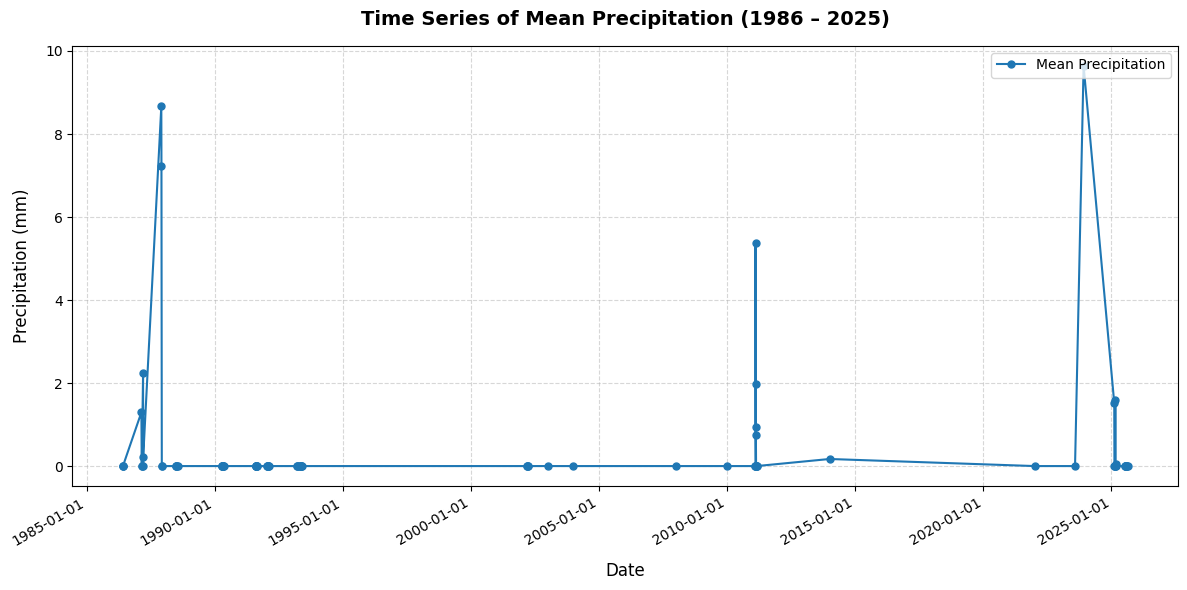

Saved → 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\precipitation_daily_time_series.png'


<Figure size 640x480 with 0 Axes>

In [69]:
import matplotlib.dates as mdates
# 2. Convert date column to datetime format
combined_dataset['date'] = pd.to_datetime(combined_dataset['date'])

# 3. Group by date to find the regional mean precipitation
daily_ts = combined_dataset.groupby('date')['precip_mean_mm'].mean().sort_index().reset_index()

# Initialize the plot using subplots
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the timeline
ax.plot(
    daily_ts['date'], 
    daily_ts['precip_mean_mm'], 
    marker='o', 
    markersize=5, 
    linestyle='-', 
    color='#1f77b4', 
    linewidth=1.5, 
    label='Mean Precipitation'
)

# === FIX FOR THE BLACK/CROWDED X-AXIS ===
# This tells matplotlib to automatically find a clean interval for dates (e.g., every few years)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
# This formats the visible labels cleanly as 'Year-Month-Day' (or just '%Y' if you only want years)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# This auto-rotates the date text slightly so they don't crash into each other
fig.autofmt_xdate()
# ========================================

# Customize elements for a professional layout
ax.set_title('Time Series of Mean Precipitation (1986 – 2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12, labelpad=10)
ax.set_ylabel('Precipitation (mm)', fontsize=12, labelpad=10)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

# Ensure layout fits labels properly and save
plt.tight_layout()
plt.show()
output_image_path = OUTPUT_DIR / "precipitation_daily_time_series.png"
plt.savefig(output_image_path, dpi=300)
plt.close(fig)
print(f"Saved → '{output_image_path}'") 

**Create a 2-year interval precipitation time series plot to visualize rainfall trends from 1986 to 2025**

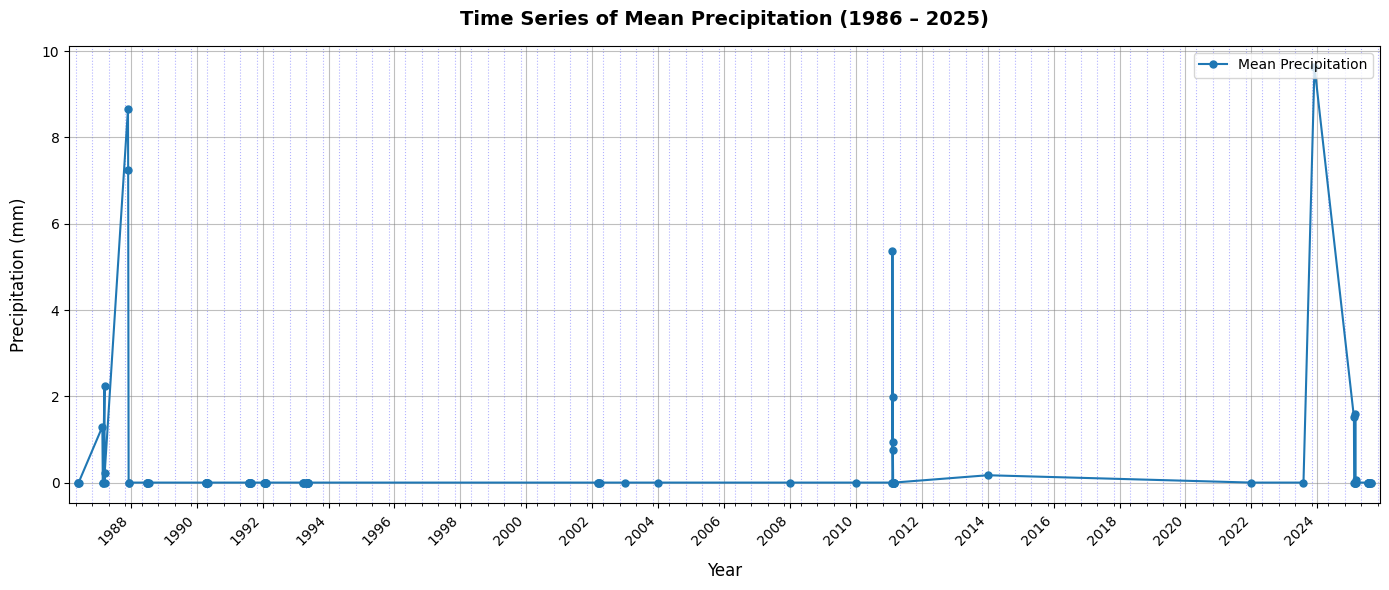

Saved → 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\precipitation_daily_time_year_wise_series.png'


<Figure size 640x480 with 0 Axes>

In [70]:
daily_ts = combined_dataset.groupby('date')['precip_mean_mm'].mean().sort_index().reset_index()

# Initialize the plot using subplots
fig, ax = plt.subplots(figsize=(14, 6))  # Slightly widened to give text more room

# Plot the timeline
ax.plot(
    daily_ts['date'], 
    daily_ts['precip_mean_mm'], 
    marker='o', 
    markersize=5, 
    linestyle='-', 
    color='#1f77b4', 
    linewidth=1.5, 
    label='Mean Precipitation'
)

# === THE ULTIMATE OVERLAP FIX FOR A 40-YEAR SPAN ===
# Major Ticks: Display text labels every 2 years so they stay cleanly spaced apart
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Minor Ticks: Place small sub-tick marks every 6 months without adding text blocks
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))

# Set the timeline limits tightly to your data range
ax.set_xlim(daily_ts['date'].min() - pd.Timedelta(days=100), daily_ts['date'].max() + pd.Timedelta(days=100))

# Rotate the year labels by 45 degrees so they never touch each other
plt.xticks(rotation=45, ha='right')
# ===================================================

# Customize elements for a professional layout
ax.set_title('Time Series of Mean Precipitation (1986 – 2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12, labelpad=10)
ax.set_ylabel('Precipitation (mm)', fontsize=12, labelpad=10)

# Add clear grid lines for both major years and minor 6-month ticks
ax.grid(True, which='major', linestyle='-', alpha=0.5, color='gray')
ax.grid(True, which='minor', linestyle=':', alpha=0.3, color='blue') # Light blue dots for 6-months
ax.legend(loc='upper right')

# Ensure layout fits labels perfectly and save
plt.tight_layout()
plt.show()
output_image_path = OUTPUT_DIR / "precipitation_daily_time_year_wise_series.png"
plt.savefig(output_image_path, dpi=300)
plt.close(fig)
print(f"Saved → '{output_image_path}'") 

**Create a 6-month interval precipitation time series plot to visualize rainfall variation from 1986 to 2025**

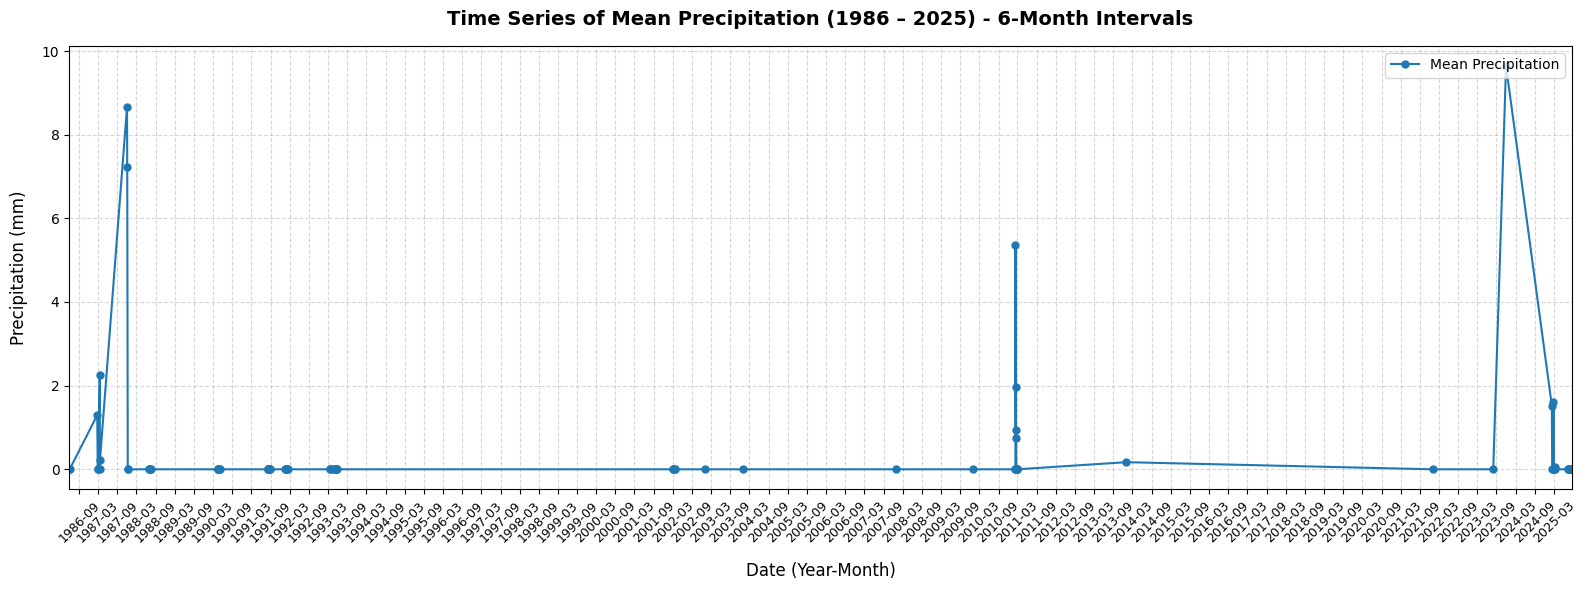

Saved → 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\precipitation_6_months_time_series.png'


<Figure size 640x480 with 0 Axes>

In [71]:
combined_dataset['date'] = pd.to_datetime(combined_dataset['date'])

# 3. Group by date to find the regional mean precipitation
daily_ts = combined_dataset.groupby('date')['precip_mean_mm'].mean().sort_index().reset_index()

# Initialize the plot using subplots (Widen to 16 to give the labels room)
fig, ax = plt.subplots(figsize=(16, 6))

# Plot the timeline
ax.plot(
    daily_ts['date'], 
    daily_ts['precip_mean_mm'], 
    marker='o', 
    markersize=5, 
    linestyle='-', 
    color='#1f77b4', 
    linewidth=1.5, 
    label='Mean Precipitation'
)

# === SUPERVISOR REQUEST: TICK & LABEL EVERY 6 MONTHS ===
# 1. Place a tick mark every 6 months
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

# 2. Format as 'YYYY-MM' (Shorter text length prevents horizontal overlapping)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 3. Rotate text vertically (90 degrees) so they line up like columns instead of rows
plt.xticks(rotation=45, fontsize=9, ha='center')

# 4. Snap the axis edges tightly to your actual data boundaries
ax.set_xlim(daily_ts['date'].min(), daily_ts['date'].max())
# ========================================================

# Customize elements for a professional layout
ax.set_title('Time Series of Mean Precipitation (1986 – 2025) - 6-Month Intervals', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date (Year-Month)', fontsize=12, labelpad=12)
ax.set_ylabel('Precipitation (mm)', fontsize=12, labelpad=10)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

# Ensure layout fits labels perfectly and save
plt.tight_layout()
plt.show()
output_image_path = OUTPUT_DIR / "precipitation_6_months_time_series.png"
plt.savefig(output_image_path, dpi=300)
plt.close(fig)
print(f"Saved → '{output_image_path}'") 

**Create an annual precipitation distribution plot to compare rainfall variations across sampling years**

Saved → 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\precipitation_yearly_trend.png'


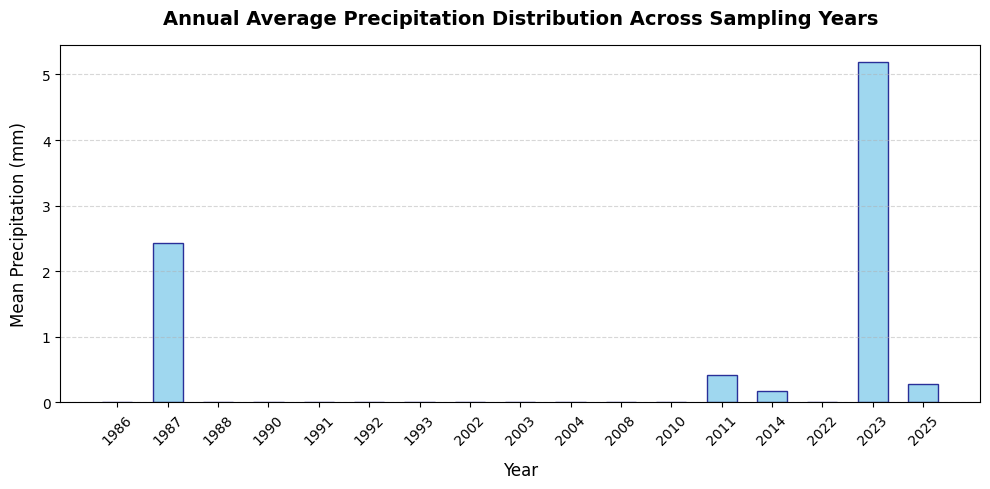

In [72]:

# =====================================================================
# APPROACH 2: Annual Precipitation Distribution (Aggregated by Year)
# =====================================================================
# Group by year to check long-term shifts across your specific sampling years
yearly_ts = combined_dataset.groupby('year')['precip_mean_mm'].mean().sort_index().reset_index()

fig2, ax2 = plt.subplots(figsize=(10, 5))

# Plot as a bar chart to easily see wet vs. dry sampling years
ax2.bar(
    yearly_ts['year'].astype(str), 
    yearly_ts['precip_mean_mm'], 
    color='skyblue', 
    edgecolor='navy', 
    alpha=0.8,
    width=0.6
)

# Customize titles and labels
ax2.set_title('Annual Average Precipitation Distribution Across Sampling Years', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Year', fontsize=12, labelpad=10)
ax2.set_ylabel('Mean Precipitation (mm)', fontsize=12, labelpad=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Rotate labels slightly to make them easy to read
plt.xticks(rotation=45)
plt.tight_layout()
output_image_path = OUTPUT_DIR / "precipitation_yearly_trend.png"
plt.savefig(output_image_path, dpi=300)
plt.close(fig)
print(f"Saved → '{output_image_path}'") 

**Create a 6-month aggregated precipitation distribution plot to analyze rainfall variation over time**

Saved → 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\precipitation_6month_trend_bar.png'


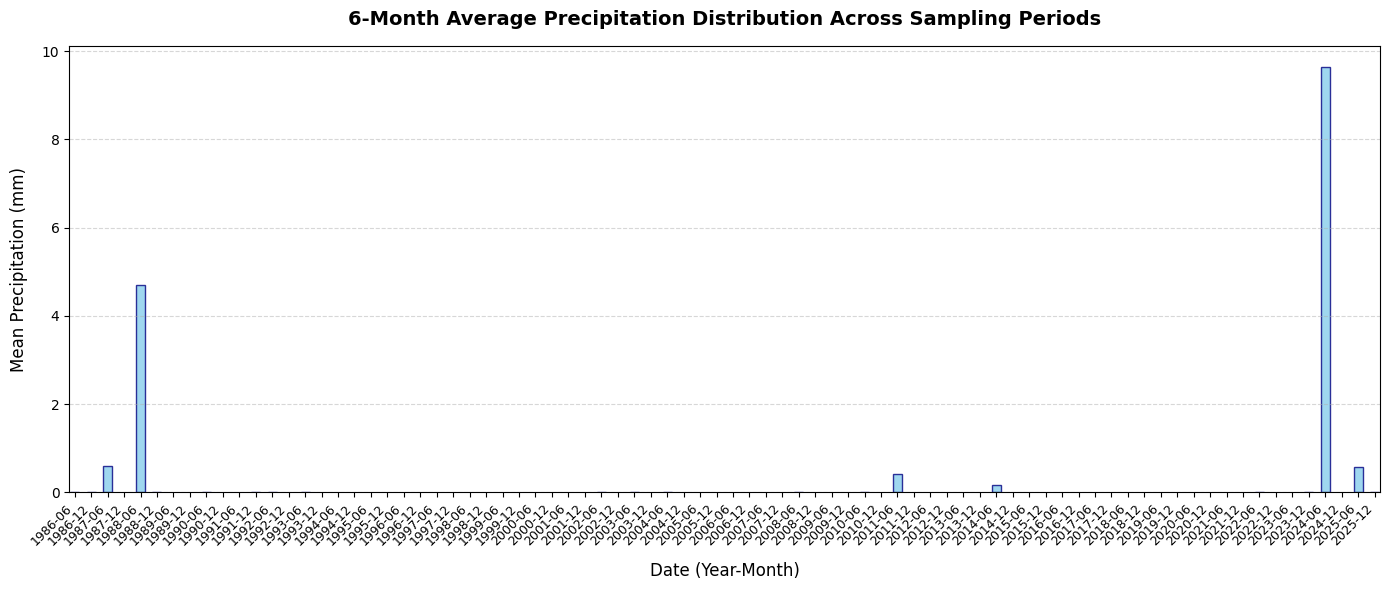

In [73]:
semi_annual_ts = combined_dataset.groupby(pd.Grouper(key='date', freq='6ME'))['precip_mean_mm'].mean().reset_index()

# Drop periods that have no sampling data to keep the chart clean
semi_annual_ts = semi_annual_ts[semi_annual_ts['precip_mean_mm'].notna()].sort_values('date')

# Initialize the plot using subplots
fig2, ax2 = plt.subplots(figsize=(14, 6))

# Plot as a bar chart
ax2.bar(
    semi_annual_ts['date'], 
    semi_annual_ts['precip_mean_mm'], 
    color='skyblue', 
    edgecolor='navy', 
    alpha=0.8,
    width=100  # Sets the physical bar width in days
)

# === TICK & LABEL EVERY 6 MONTHS WITH DIAGONAL ANGLE ===
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# This sets the angle to 45 degrees so they are perfectly legible
plt.xticks(rotation=45, fontsize=9, ha='right')

# Tight bounds around your active sampling periods
ax2.set_xlim(semi_annual_ts['date'].min() - pd.Timedelta(days=60), semi_annual_ts['date'].max() + pd.Timedelta(days=60))
# =======================================================

# Customize titles and labels
ax2.set_title('6-Month Average Precipitation Distribution Across Sampling Periods', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Date (Year-Month)', fontsize=12, labelpad=10)
ax2.set_ylabel('Mean Precipitation (mm)', fontsize=12, labelpad=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Ensure layout fits labels perfectly and save
plt.tight_layout()
output_image_path = OUTPUT_DIR / "precipitation_6month_trend_bar.png"
plt.savefig(output_image_path, dpi=300)
plt.close(fig)
print(f"Saved → '{output_image_path}'") 

**Create a 6-month interval skin temperature time series plot to analyze temperature variation from 1986 to 2025**

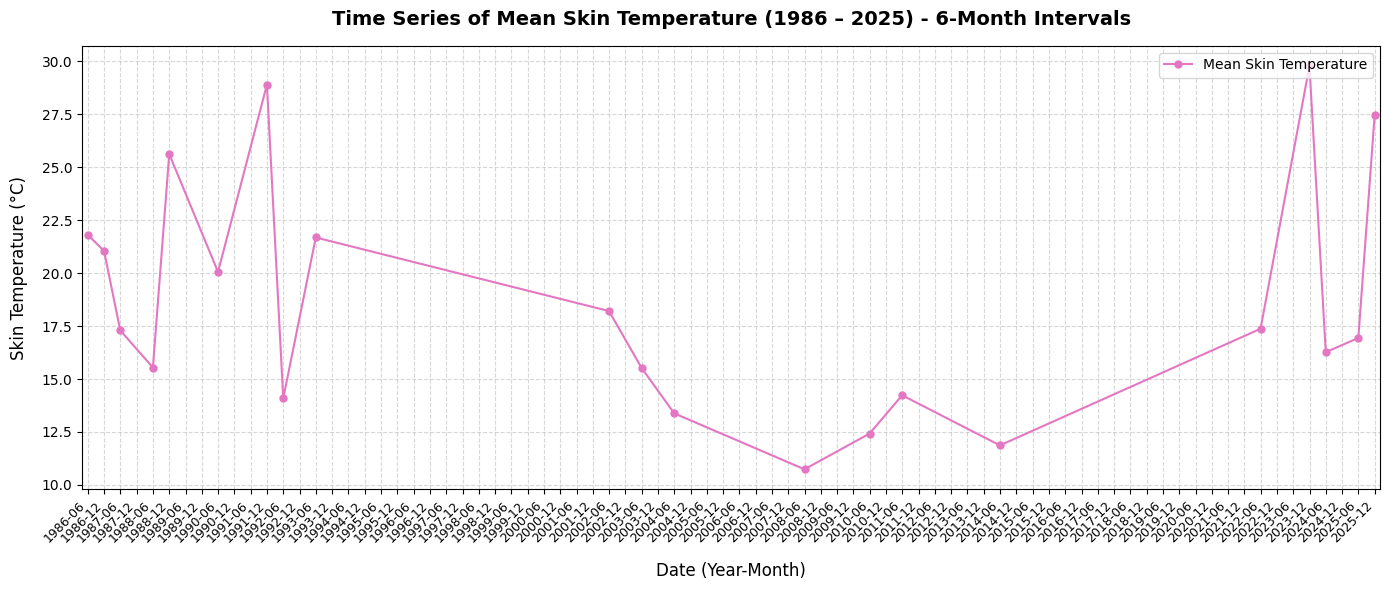

Saved → 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\skin_temperature_6_months_time_series.png'


<Figure size 640x480 with 0 Axes>

In [74]:
semi_annual_skin_ts = combined_dataset.groupby(pd.Grouper(key='date', freq='6ME'))['skin_temp_mean_celsius'].mean().reset_index()

# Drop periods that have no sampling data to keep the chart clean
semi_annual_skin_ts = semi_annual_skin_ts[semi_annual_skin_ts['skin_temp_mean_celsius'].notna()].sort_values('date')

# Initialize the plot using subplots
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the timeline
ax.plot(
    semi_annual_skin_ts['date'], 
    semi_annual_skin_ts['skin_temp_mean_celsius'], 
    marker='o', 
    markersize=5, 
    linestyle='-', 
    color='#e377c2',  # Magenta/Pink color for skin temperature
    linewidth=1.5, 
    label='Mean Skin Temperature'
)

# === TICK & LABEL EVERY 6 MONTHS WITH DIAGONAL ANGLE ===
# 1. Place a tick mark every 6 months
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

# 2. Format labels cleanly as Year-Month (keeps text narrow)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 3. Rotate the axis labels diagonally (45 degrees) to prevent overlapping
plt.xticks(rotation=45, fontsize=9, ha='right')

# 4. Snap the axis edges tightly to your active sampling periods
ax.set_xlim(semi_annual_skin_ts['date'].min() - pd.Timedelta(days=60), semi_annual_skin_ts['date'].max() + pd.Timedelta(days=60))
# =======================================================

# Customize elements for a professional layout
ax.set_title('Time Series of Mean Skin Temperature (1986 – 2025) - 6-Month Intervals', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date (Year-Month)', fontsize=12, labelpad=12)
ax.set_ylabel('Skin Temperature (°C)', fontsize=12, labelpad=10)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

# Ensure layout fits labels perfectly and save
plt.tight_layout()
plt.show()
output_image_path = OUTPUT_DIR / "skin_temperature_6_months_time_series.png"
plt.savefig(output_image_path, dpi=300)
plt.close(fig)
print(f"Saved → '{output_image_path}'") 

**Create an annual skin temperature trend plot to analyze long-term temperature changes across sampling years**

Saved → 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\skin_temperature_yearly_trend.png'


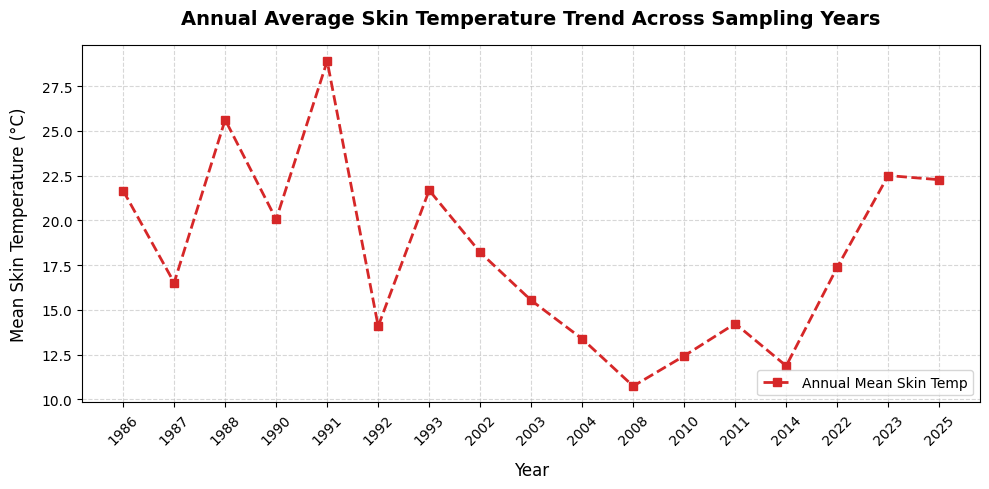

In [75]:
# Group by year to check multi-decadal shifts across your specific sampling years
yearly_skin_ts = combined_dataset.groupby('year')['skin_temp_mean_celsius'].mean().sort_index().reset_index()

fig2, ax2 = plt.subplots(figsize=(10, 5))

# Plot as a line chart with markers to showcase historical temperature shifts
ax2.plot(
    yearly_skin_ts['year'].astype(str), 
    yearly_skin_ts['skin_temp_mean_celsius'], 
    marker='s',           # Square markers
    markersize=6,
    linestyle='--', 
    color='#d62728',      # Red line for clear climate trend tracking
    linewidth=2,
    label='Annual Mean Skin Temp'
)

# Customize titles and labels
ax2.set_title('Annual Average Skin Temperature Trend Across Sampling Years', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Year', fontsize=12, labelpad=10)
ax2.set_ylabel('Mean Skin Temperature (°C)', fontsize=12, labelpad=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

# Rotate labels slightly to ensure clear presentation
plt.xticks(rotation=45)
plt.tight_layout()
output_image_path = OUTPUT_DIR / "skin_temperature_yearly_trend.png"
plt.savefig(output_image_path, dpi=300)
plt.close(fig)
print(f"Saved → '{output_image_path}'")

**Create a monthly skin temperature trend plot to analyze seasonal and long-term temperature variations**

Saved → 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\skin_temperature_monthly_trend_line.png'


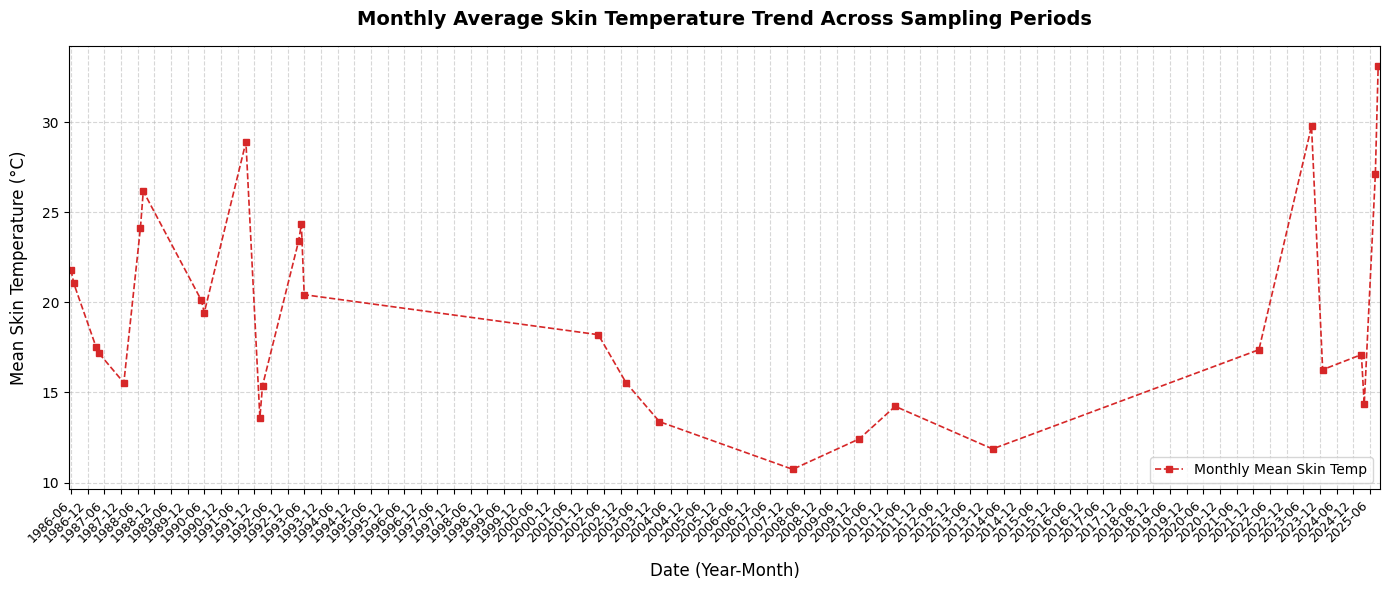

In [76]:
monthly_skin_ts = combined_dataset.groupby(pd.Grouper(key='date', freq='ME'))['skin_temp_mean_celsius'].mean().reset_index()
# Drop periods that have no sampling data to keep the chart clean
monthly_skin_ts = monthly_skin_ts[monthly_skin_ts['skin_temp_mean_celsius'].notna()].sort_values('date')

fig2, ax2 = plt.subplots(figsize=(14, 6))
ax2.plot(
    monthly_skin_ts['date'], 
    monthly_skin_ts['skin_temp_mean_celsius'], 
    marker='s',
    markersize=4,
    linestyle='--', 
    color='#d62728',
    linewidth=1.2,
    label='Monthly Mean Skin Temp'
)

# === TICK & LABEL ON JUNE AND DECEMBER OF EVERY YEAR ===
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[6, 12]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, fontsize=9, ha='right')
ax2.set_xlim(monthly_skin_ts['date'].min() - pd.Timedelta(days=20), monthly_skin_ts['date'].max() + pd.Timedelta(days=20))
# ==========================================================

ax2.set_title('Monthly Average Skin Temperature Trend Across Sampling Periods', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Date (Year-Month)', fontsize=12, labelpad=12)
ax2.set_ylabel('Mean Skin Temperature (°C)', fontsize=12, labelpad=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

plt.tight_layout()
output_image_path = OUTPUT_DIR / "skin_temperature_monthly_trend_line.png"
plt.savefig(output_image_path, dpi=300)
plt.close(fig)
print(f"Saved → '{output_image_path}'")

**Compare 6-month average skin temperature and 2-meter air temperature trends over the sampling period**

Saved → 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\skin_and_2m_temperature_6month_trend_line.png'


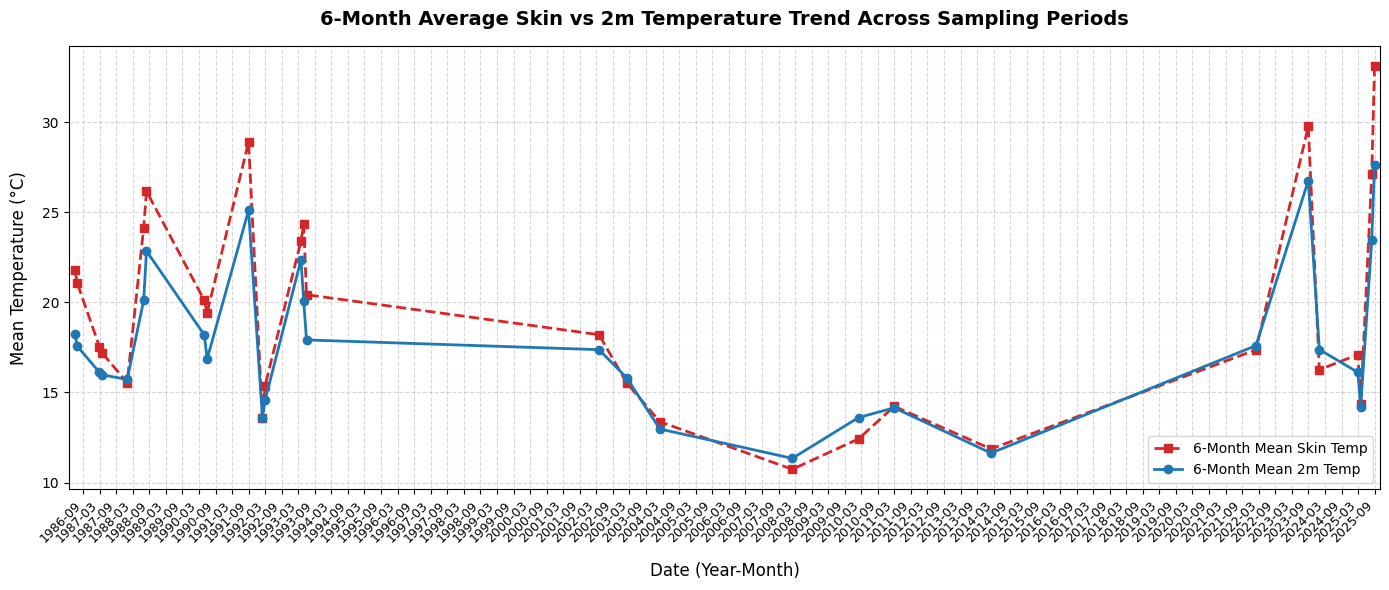

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

semi_annual_ts = combined_dataset.groupby(pd.Grouper(key='date', freq='ME'))[
    ['skin_temp_mean_celsius', 'temp_2m_mean_celsius']
].mean().reset_index()

# 3. Clean up empty periods
semi_annual_ts = semi_annual_ts[semi_annual_ts['skin_temp_mean_celsius'].notna()].sort_values('date')

# 4. Plotting setup
fig2, ax2 = plt.subplots(figsize=(14, 6))

# Plot Skin Temp
ax2.plot(
    semi_annual_ts['date'], 
    semi_annual_ts['skin_temp_mean_celsius'], 
    marker='s', markersize=6, linestyle='--', color='#d62728', linewidth=2,
    label='6-Month Mean Skin Temp'
)

# Plot 2m Temp
ax2.plot(
    semi_annual_ts['date'], 
    semi_annual_ts['temp_2m_mean_celsius'], 
    marker='o', markersize=6, linestyle='-', color='#1f77b4', linewidth=2,
    label='6-Month Mean 2m Temp'
)

# Axis formatting
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, fontsize=9, ha='right')

ax2.set_xlim(semi_annual_ts['date'].min() - pd.Timedelta(days=60), semi_annual_ts['date'].max() + pd.Timedelta(days=60))

ax2.set_title('6-Month Average Skin vs 2m Temperature Trend Across Sampling Periods', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Date (Year-Month)', fontsize=12, labelpad=12)
ax2.set_ylabel('Mean Temperature (°C)', fontsize=12, labelpad=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

plt.tight_layout()
output_image_path = OUTPUT_DIR / "skin_and_2m_temperature_6month_trend_line.png"
plt.savefig(output_image_path, dpi=300)
plt.close(fig)
print(f"Saved → '{output_image_path}'") 

**Create a monthly basin precipitation distribution plot using CHIRPS rainfall data from 1986 to 2025**

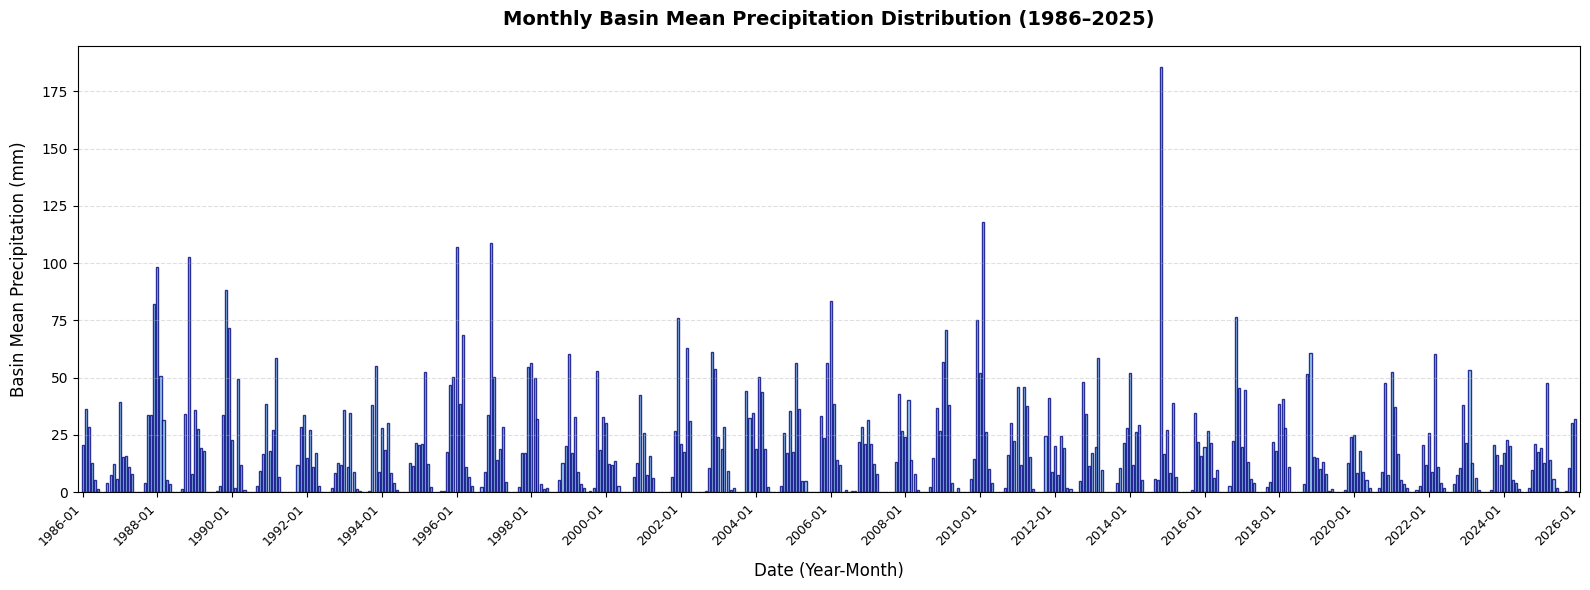

Saved → 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\precipitation_monthly_bar_trend.png'


<Figure size 640x480 with 0 Axes>

In [78]:
chirps_path = DATA_DIR / "DataBaseChtoukaFinal_WGS" / "Chtouka_Basin_Monthly_Precipitation_CHIRPS_new.csv"
df_chirps = pd.read_csv(chirps_path)

# Convert the text string 'YYYY-MM' into a true datetime object
df_chirps['date_parsed'] = pd.to_datetime(df_chirps['date'], format='%Y-%m')

# Drop any rows where precipitation data might be missing and sort chronologically
df_chirps = df_chirps.dropna(subset=['basin_mean_precip_mm']).sort_values('date_parsed')

# Initialize the plot
fig, ax = plt.subplots(figsize=(16, 6))

# 2. Plot as a monthly bar chart
# Note: Using width=20 spreads out individual bars perfectly on a daily timeline
ax.bar(
    df_chirps['date_parsed'], 
    df_chirps['basin_mean_precip_mm'], 
    color='skyblue', 
    edgecolor='navy', 
    alpha=0.8,
    width=20 
)

# === ADVANCED DATE LABELING TO PREVENT TEXT OVERLAPPING ===
# Show an X-axis label major tick every 2 years (change to 1 for every year)
ax.xaxis.set_major_locator(mdates.YearLocator(2)) 

# Format labels explicitly showing both the year and starting month (%Y-%m)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotate labels diagonally (45 degrees) for crisp alignment
plt.xticks(rotation=45, fontsize=9, ha='right')

# Tighten limits around your real data boundaries
ax.set_xlim(df_chirps['date_parsed'].min() - pd.Timedelta(days=45), df_chirps['date_parsed'].max() + pd.Timedelta(days=45))
# ==========================================================

# Customize titles and labels
ax.set_title('Monthly Basin Mean Precipitation Distribution (1986–2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date (Year-Month)', fontsize=12, labelpad=10)
ax.set_ylabel('Basin Mean Precipitation (mm)', fontsize=12, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Ensure layout fits labels and save output
plt.tight_layout()
plt.show()
output_image_path = OUTPUT_DIR / "precipitation_monthly_bar_trend.png"
plt.savefig(output_image_path, dpi=300)
plt.close(fig)
print(f"Saved → '{output_image_path}'") 

**Compare continuous CHIRPS basin precipitation with sampling period precipitation trends from 1986 to 2025**

C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\4138841783.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_comb['date_parsed'] = pd.to_datetime(df_comb['date'])


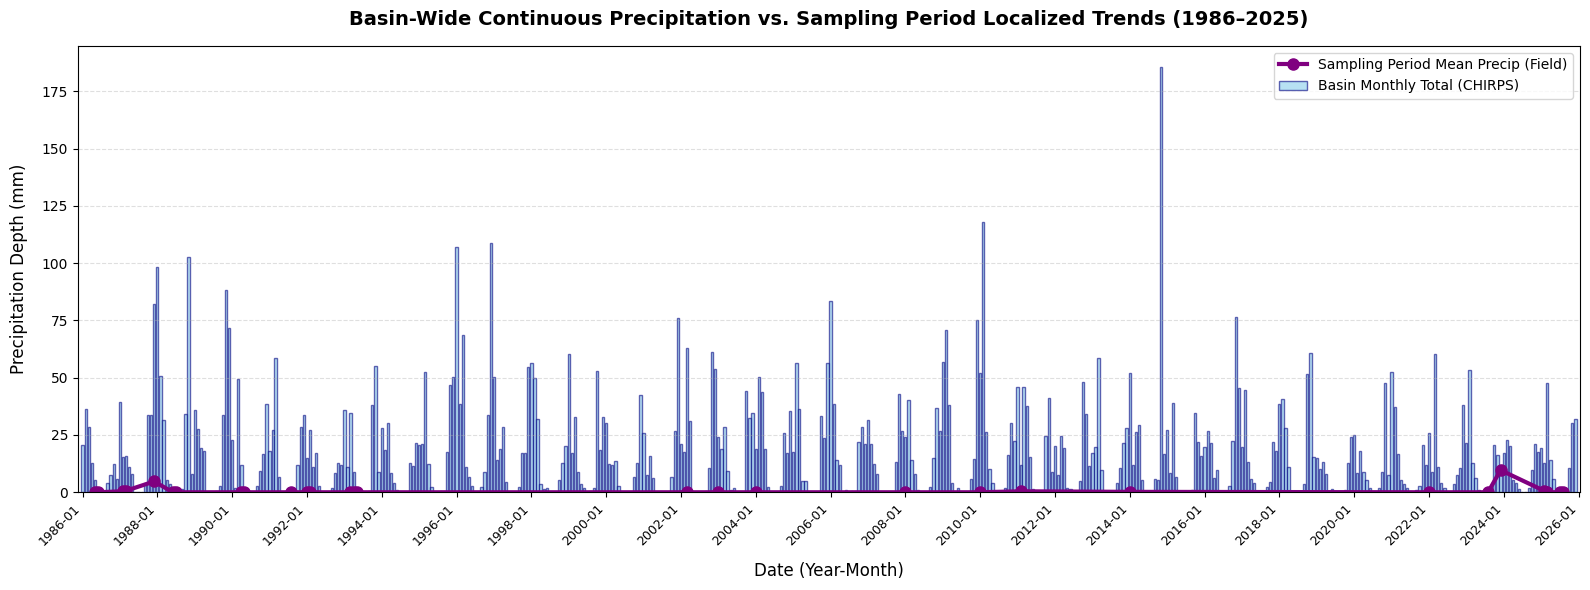

Saved → 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\precipitation_combined_bar_and_line.png'


<Figure size 640x480 with 0 Axes>

In [79]:
df_chirps = df_chirps.dropna(subset=['basin_mean_precip_mm'])

# 2. Load the sampling data containing 'precip_mean_mm' (Line points)
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_temp_2m.csv"
)
df_comb= pd.read_csv(input_path)
df_comb['date_parsed'] = pd.to_datetime(df_comb['date'])

# Group the tracking data by year-month to compute the mean value per sampling month
# This ensures it aligns natively with the x-axis centers of the bar chart rows
df_comb_monthly = df_comb.groupby(df_comb['date_parsed'].dt.to_period('M'))['precip_mean_mm'].mean().reset_index()
df_comb_monthly['date_parsed'] = df_comb_monthly['date_parsed'].dt.to_timestamp()
df_comb_monthly = df_comb_monthly.sort_values('date_parsed')

# Initialize the combined visual frame
fig, ax = plt.subplots(figsize=(16, 6))

# 3. Draw the background continuous basin-wide rainfall bars
ax.bar(
    df_chirps['date_parsed'], 
    df_chirps['basin_mean_precip_mm'], 
    color='skyblue', 
    edgecolor='navy', 
    alpha=0.6,          # Slight transparency so lines and overlaps remain clear
    width=22,           # Sized to fill out the calendar month grid smoothly
    label='Basin Monthly Total (CHIRPS)'
)

# 4. Overlay the localized active sampling precip values as a trend line
ax.plot(
    df_comb_monthly['date_parsed'],
    df_comb_monthly['precip_mean_mm'],
    color='#800080',     # Distinct bright color to highlight field tracking spots
    marker='o',         # Circular coordinate indicators
    markersize=8,
    linestyle='-',
    linewidth=3,
    label='Sampling Period Mean Precip (Field)'
)

# === TICK & LABEL FORMATTING ===
# Display scale marks down the timeline every 2 years
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, fontsize=9, ha='right')

# Tightly seal edges to the limits of your dataset 
ax.set_xlim(
    df_chirps['date_parsed'].min() - pd.Timedelta(days=45), 
    df_chirps['date_parsed'].max() + pd.Timedelta(days=45)
)

# Titles, Legends and Structural Lines
ax.set_title('Basin-Wide Continuous Precipitation vs. Sampling Period Localized Trends (1986–2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date (Year-Month)', fontsize=12, labelpad=10)
ax.set_ylabel('Precipitation Depth (mm)', fontsize=12, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper right', fontsize=10)

# Save high-resolution visualization
plt.tight_layout()
plt.show()
output_image_path = OUTPUT_DIR / "precipitation_combined_bar_and_line.png"
plt.savefig(output_image_path, dpi=300)
plt.close(fig)
print(f"Saved → '{output_image_path}'") 

**Generates individual  boxplots for all numeric variables to visualize data distribution and identify variability and outliers**

In [80]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. LOAD DATASET VIA PATHLIB ---
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_temp_2m.csv"
)
df = pd.read_csv(input_path)

# --- 2. CREATE OUTPUT DIRECTORY VIA PATHLIB ---
plots_output_dir = OUTPUT_DIR / "individual_boxplots"
plots_output_dir.mkdir(parents=True, exist_ok=True)

# --- 3. FILTER NUMERIC COLUMNS ---
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
print(
    f"Found {len(numeric_cols)} numeric columns. Starting boxplot generation..."
)

# Set global theme once outside loop for better performance
sns.set_theme(style="whitegrid")

# --- 4. GENERATE INDIVIDUAL BOXPLOTS ---
for index, col in enumerate(numeric_cols, start=1):
    # Use explicit figure/axes objects for explicit memory management
    fig, ax = plt.subplots(figsize=(6, 5))

    # Create boxplot dropping NaNs
    sns.boxplot(
        y=df[col].dropna(),
        color="skyblue",
        width=0.4,
        flierprops={"marker": "x", "markeredgecolor": "red"},
        ax=ax,
    )

    # Titles and labels
    ax.set_title(f"Box Plot of {col}", fontsize=12, fontweight="bold", pad=15)
    ax.set_ylabel("Value Range", fontsize=10)
    fig.tight_layout()

    # Sanitize column name for filesystem safety
    safe_filename = (
        col.replace("/", "_")
        .replace("%", "_pct")
        .replace(" ", "_")
        .replace(":", "")
    )
    file_path = plots_output_dir / f"boxplot_{safe_filename}.png"

    # Save and close figure explicitly
    fig.savefig(file_path, dpi=100)
    plt.close(fig)

    # Log progress every 10 columns or at completion
    if index % 10 == 0 or index == len(numeric_cols):
        print(f" Progress: Saved {index}/{len(numeric_cols)} plots...")

print(
    f"\n🎉 All done! You can find all {len(numeric_cols)} individual plots inside '{plots_output_dir}'."
)

Found 147 numeric columns. Starting boxplot generation...
 Progress: Saved 10/147 plots...
 Progress: Saved 20/147 plots...
 Progress: Saved 30/147 plots...
 Progress: Saved 40/147 plots...
 Progress: Saved 50/147 plots...
 Progress: Saved 60/147 plots...
 Progress: Saved 70/147 plots...
 Progress: Saved 80/147 plots...
 Progress: Saved 90/147 plots...
 Progress: Saved 100/147 plots...
 Progress: Saved 110/147 plots...
 Progress: Saved 120/147 plots...
 Progress: Saved 130/147 plots...
 Progress: Saved 140/147 plots...
 Progress: Saved 147/147 plots...

🎉 All done! You can find all 147 individual plots inside 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\individual_boxplots'.


**Creates and saves individual jittered boxplots for all numeric variables, showing data distribution, spread, and individual data points**

In [81]:
# --- 1. LOAD DATASET VIA PATHLIB ---
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_temp_2m.csv"
)
df = pd.read_csv(input_path)

# --- 2. CREATE OUTPUT DIRECTORY VIA PATHLIB ---
output_dir = OUTPUT_DIR / "individual_boxplots_with_jitter"
output_dir.mkdir(parents=True, exist_ok=True)

# --- 3. FILTER NUMERIC COLUMNS ---
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

print(
    f"Found {len(numeric_cols)} numeric columns. Starting export with jitter..."
)

# Set global theme once outside the loop
sns.set_theme(style="whitegrid")

# --- 4. GENERATE JITTERED BOXPLOTS ---
for index, col in enumerate(numeric_cols, start=1):
    clean_data = df[col].dropna()

    if clean_data.empty:
        continue

    # Explicit figure/axes creation for safe memory cleanup
    fig, ax = plt.subplots(figsize=(6, 5))

    # Layer 1: Draw base Box Plot (Soft light blue background, no duplicate outliers)
    sns.boxplot(
        y=clean_data,
        color="#add8e6",
        width=0.4,
        showfliers=False,  # Hides standard outliers so stripplot handles them cleanly
        ax=ax,
    )

    # Layer 2: Draw Jittered Raw Points (geom_jitter equivalent)
    sns.stripplot(
        y=clean_data,
        color="black",
        size=3,
        jitter=0.15,
        alpha=0.5,
        linewidth=0,
        ax=ax,
    )

    # Custom Titles and Labels
    ax.set_title(
        f"Distribution & Data Points: {col}",
        fontsize=11,
        fontweight="bold",
        pad=15,
    )
    ax.set_ylabel("Value Range", fontsize=10)
    fig.tight_layout()

    # Sanitize column name for safe filesystem export
    safe_filename = (
        col.replace("/", "_")
        .replace("%", "_pct")
        .replace(" ", "_")
        .replace(":", "")
    )
    file_path = output_dir / f"boxplot_jitter_{safe_filename}.png"

    # Save chart and release figure RAM
    fig.savefig(file_path, dpi=120)
    plt.close(fig)

    # Progress logging updates
    if index % 10 == 0 or index == len(numeric_cols):
        print(f" Progress: Exported {index}/{len(numeric_cols)} plots...")

print(
    f"\n🎉 Success! All {len(numeric_cols)} standalone jittered plots are saved inside: '{output_dir}/'"
)

Found 147 numeric columns. Starting export with jitter...
 Progress: Exported 10/147 plots...
 Progress: Exported 20/147 plots...
 Progress: Exported 30/147 plots...
 Progress: Exported 40/147 plots...
 Progress: Exported 50/147 plots...
 Progress: Exported 60/147 plots...
 Progress: Exported 70/147 plots...
 Progress: Exported 80/147 plots...
 Progress: Exported 90/147 plots...
 Progress: Exported 100/147 plots...
 Progress: Exported 110/147 plots...
 Progress: Exported 120/147 plots...
 Progress: Exported 130/147 plots...
 Progress: Exported 140/147 plots...
 Progress: Exported 147/147 plots...

🎉 Success! All 147 standalone jittered plots are saved inside: 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\individual_boxplots_with_jitter/'


**Creates grouped boxplots comparing land cover percentage distributions across different buffer distances and saves the comparison plots**

In [82]:

# --- 1. LOAD DATASET VIA PATHLIB ---
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_temp_2m.csv"
)
df = pd.read_csv(input_path)

# --- 2. CREATE OUTPUT DIRECTORY VIA PATHLIB ---
output_dir = OUTPUT_DIR / "landcover_buffer_comparisons"
output_dir.mkdir(parents=True, exist_ok=True)

# --- 3. DEFINE LANDCOVER TYPES & DISTANCE ORDER ---
landcover_types = [
    "Crops",
    "Water",
    "Trees",
    "BuiltArea",
    "BareGround",
    "Rangeland",
    "FloodedVeg",
]

distance_order = ["500m", "2000m", "5000m", "10000m"]

print("Generating grouped landcover comparison box plots...")

# Set global theme once outside the loop
sns.set_theme(style="whitegrid")

# --- 4. GENERATE COMPARATIVE BOX PLOTS ---
for lc in landcover_types:
    # Find matching columns (e.g., 'Crops_500m', 'FloodedVeg_2000m'...)
    lc_cols = [col for col in df.columns if col.startswith(f"{lc}_")]

    if not lc_cols:
        continue  # Skip if no columns match

    # Reshape from wide to long format for Seaborn plotting
    sub_df = df[lc_cols].copy()
    melted_df = sub_df.melt(var_name="Buffer_Column", value_name="Percentage")

    # Extract distance suffix for X-axis labels
    melted_df["Distance"] = melted_df["Buffer_Column"].apply(
        lambda x: x.split("_")[-1]
    )

    available_order = [
        dist for dist in distance_order if dist in melted_df["Distance"].unique()
    ]

    # Explicit figure/axes creation for clean RAM management
    fig, ax = plt.subplots(figsize=(8, 6))

    # Draw grouped boxplot across distances
    sns.boxplot(
        x="Distance",
        y="Percentage",
        data=melted_df,
        order=available_order,
        hue="Distance",  # Explicit assignment for modern seaborn compatibility
        legend=False,
        palette="Set2",
        width=0.5,
        flierprops={"marker": "x", "markersize": 4, "markeredgecolor": "gray"},
        ax=ax,
    )

    # Layout enhancements
    ax.set_title(
        f"Distribution of {lc} Coverage across Buffer Distances",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Buffer Distance Radius", fontsize=11, labelpad=10)
    ax.set_ylabel("Coverage Value / Percentage", fontsize=11, labelpad=10)
    fig.tight_layout()

    # Save via Path object and close figure
    file_path = output_dir / f"grouped_boxplot_{lc.lower()}.png"
    fig.savefig(file_path, dpi=120)
    plt.close(fig)

    print(f" -> Generated and saved comparison for: {lc}")

print(
    f"\n🎉 Finished! Check '{output_dir}' to view your comparative spatial metrics side-by-side."
)

Generating grouped landcover comparison box plots...
 -> Generated and saved comparison for: Crops
 -> Generated and saved comparison for: Water
 -> Generated and saved comparison for: Trees
 -> Generated and saved comparison for: BuiltArea
 -> Generated and saved comparison for: BareGround
 -> Generated and saved comparison for: Rangeland
 -> Generated and saved comparison for: FloodedVeg

🎉 Finished! Check 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\landcover_buffer_comparisons' to view your comparative spatial metrics side-by-side.


**Creates jittered boxplots showing land cover distribution and individual data points across different buffer distances**

In [83]:
# --- 1. LOAD DATASET VIA PATHLIB ---
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_temp_2m.csv"
)
df = pd.read_csv(input_path)

# --- 2. CREATE OUTPUT DIRECTORY VIA PATHLIB ---
output_dir = OUTPUT_DIR / "landcover_buffer_with_jitter"
output_dir.mkdir(parents=True, exist_ok=True)

# --- 3. DEFINE TARGETS & SPATIAL ORDER ---
landcover_types = [
    "Crops",
    "Water",
    "Trees",
    "BuiltArea",
    "BareGround",
    "Rangeland",
    "FloodedVeg",
]
distance_order = ["500m", "2000m", "5000m", "10000m"]

print("Generating grouped box plots with jittered data points...")

# Set global theme once outside loop
sns.set_theme(style="whitegrid")

# --- 4. PROCESS EACH LANDCOVER CATEGORY ---
for lc in landcover_types:
    # Identify matching columns
    lc_cols = [col for col in df.columns if col.startswith(f"{lc}_")]

    if not lc_cols:
        continue

    # Reshape from Wide to Long format
    sub_df = df[lc_cols].copy()
    melted_df = sub_df.melt(var_name="Buffer_Column", value_name="Percentage")
    melted_df["Distance"] = melted_df["Buffer_Column"].apply(
        lambda x: x.split("_")[-1]
    )

    available_order = [
        dist for dist in distance_order if dist in melted_df["Distance"].unique()
    ]

    # Explicit figure/axes creation for safe memory release
    fig, ax = plt.subplots(figsize=(9, 6))

    # Layer 1: Boxplots with semi-transparent fills and hidden standard outliers
    sns.boxplot(
        x="Distance",
        y="Percentage",
        data=melted_df,
        order=available_order,
        palette="Pastel2",
        width=0.5,
        showfliers=False,  # Hides default outliers so stripplot handles them cleanly
        ax=ax,
    )

    # Layer 2: Jittered Individual Observations
    sns.stripplot(
        x="Distance",
        y="Percentage",
        data=melted_df,
        order=available_order,
        color="black",
        size=3,
        jitter=0.25,
        alpha=0.6,
        linewidth=0,
        ax=ax,
    )

    # Custom Labels & Styling
    ax.set_title(
        f"Distribution & Individual Data Points for {lc} Coverage",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Buffer Distance Radius", fontsize=11, labelpad=10)
    ax.set_ylabel("Coverage Percentage / Value", fontsize=11, labelpad=10)
    fig.tight_layout()

    # Save via Path object and close figure memory
    file_path = output_dir / f"jitter_boxplot_{lc.lower()}.png"
    fig.savefig(file_path, dpi=130)
    plt.close(fig)

    print(f" -> Generated and saved jitter plot for: {lc}")

print(
    f"\n🎉 Finished! Open '{output_dir}' to review your raw observations mapped over the summary quartiles."
)

Generating grouped box plots with jittered data points...


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\617486254.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved jitter plot for: Crops


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\617486254.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved jitter plot for: Water


...

 -> Generated and saved jitter plot for: BareGround


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\617486254.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved jitter plot for: Rangeland


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\617486254.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved jitter plot for: FloodedVeg

🎉 Finished! Open 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\landcover_buffer_with_jitter' to review your raw observations mapped over the summary quartiles.


**Create grouped boxplots with jittered points for soil textures across buffer distances**

In [84]:
# --- 1. LOAD DATASET VIA PATHLIB ---
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_temp_2m.csv"
)
df = pd.read_csv(input_path)

# --- 2. CREATE OUTPUT DIRECTORY VIA PATHLIB ---
output_dir = OUTPUT_DIR / "soil_buffer_with_jitter"
output_dir.mkdir(parents=True, exist_ok=True)

# --- 3. DEFINE SOIL TEXTURES & BUFFER DISTANCE ORDER ---
soil_textures = [
    "A",
    "AL",
    "LS",
    "LSA",
    "S",
    "SL",
    "SLA",
    "IMP",
    "LA",
    "LAS",
    "SA",
    "SAL",
]
distance_order = ["500m", "2000m", "5000m"]

print("Generating grouped box plots with jittered points for soil textures...")

# Set global theme once outside the loop
sns.set_theme(style="whitegrid")

# --- 4. PROCESS EACH SOIL TEXTURE CATEGORY ---
for tex in soil_textures:
    # Identify matching columns (e.g., LS%_500m, LS_500m, etc.)
    soil_cols = [
        col
        for col in df.columns
        if col.startswith(f"{tex}%_") or col.startswith(f"{tex}_")
    ]

    if not soil_cols:
        continue

    # Reshape from Wide to Long format
    sub_df = df[soil_cols].copy()
    melted_df = sub_df.melt(
        var_name="Buffer_Column", value_name="Percentage"
    )

    # Extract distance label (e.g., '500m' from 'LS%_500m')
    melted_df["Distance"] = melted_df["Buffer_Column"].apply(
        lambda x: x.split("_")[-1]
    )

    available_order = [
        dist
        for dist in distance_order
        if dist in melted_df["Distance"].unique()
    ]

    if not available_order:
        continue

    # Explicit figure/axes creation for safe RAM management
    fig, ax = plt.subplots(figsize=(9, 6))

    # Layer 1: Boxplots with semi-transparent fills and hidden standard outliers
    sns.boxplot(
        x="Distance",
        y="Percentage",
        data=melted_df,
        order=available_order,
        palette="Pastel2",
        width=0.5,
        showfliers=False,  # Stripplot handles point rendering cleanly
        ax=ax,
    )

    # Layer 2: Jittered Individual Observations
    sns.stripplot(
        x="Distance",
        y="Percentage",
        data=melted_df,
        order=available_order,
        color="black",
        size=3,
        jitter=0.25,
        alpha=0.6,
        linewidth=0,
        ax=ax,
    )

    # Custom Titles & Labels
    ax.set_title(
        f"Distribution & Individual Data Points for Soil Texture: {tex}",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Buffer Distance Radius", fontsize=11, labelpad=10)
    ax.set_ylabel("Soil Percentage Coverage (%)", fontsize=11, labelpad=10)
    fig.tight_layout()

    # Save via Path object and release figure memory
    file_path = output_dir / f"jitter_boxplot_soil_{tex.lower()}.png"
    fig.savefig(file_path, dpi=130)
    plt.close(fig)

    print(f" -> Generated and saved soil jitter plot for: {tex}")

print(
    f"\n🎉 Finished! All soil plots are saved in the '{output_dir}' directory."
)

Generating grouped box plots with jittered points for soil textures...


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\225445530.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved soil jitter plot for: A


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\225445530.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved soil jitter plot for: AL


...

 -> Generated and saved soil jitter plot for: LAS


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\225445530.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved soil jitter plot for: SA


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\225445530.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved soil jitter plot for: SAL

🎉 Finished! All soil plots are saved in the 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\soil_buffer_with_jitter' directory.


**Create grouped boxplots with jittered points for rock type percentages across buffer distances**

In [85]:
import re
# --- 2. CREATE OUTPUT DIRECTORY VIA PATHLIB ---
output_dir = OUTPUT_DIR / "rocktype_buffer_with_jitter"
output_dir.mkdir(parents=True, exist_ok=True)

# --- 3. IDENTIFY GEOLOGY COLUMNS & ROCK TYPES ---
geo_cols = [col for col in df.columns if "_Geo%" in col]

# Extract unique rock type names and buffer distance order
rock_types = sorted(
    list(set([col.split("_Geo%_")[0] for col in geo_cols if "_Geo%_" in col]))
)
distance_order = ["500m", "2000m", "5000m"]

print(f"Found {len(rock_types)} unique rock types.")
print(
    "Generating grouped box plots with jittered data points for rock types...\n"
)

# Set global theme once outside the loop
sns.set_theme(style="whitegrid")

# --- 4. PROCESS EACH ROCK TYPE CATEGORY ---
for rock in rock_types:
    # Identify matching columns (e.g., 'Calcaire lacustre_Geo%_500m', etc.)
    matching_cols = [
        col for col in geo_cols if col.startswith(f"{rock}_Geo%_")
    ]

    if not matching_cols:
        continue

    # Reshape from Wide to Long format
    sub_df = df[matching_cols].copy()
    melted_df = sub_df.melt(var_name="Buffer_Column", value_name="Percentage")

    # Extract distance label ('500m', '2000m', '5000m')
    melted_df["Distance"] = melted_df["Buffer_Column"].apply(
        lambda x: x.split("_Geo%_")[-1]
    )

    available_order = [
        dist
        for dist in distance_order
        if dist in melted_df["Distance"].unique()
    ]

    if not available_order:
        continue

    # Explicit figure/axes creation for safe RAM management
    fig, ax = plt.subplots(figsize=(9, 6))

    # Layer 1: Boxplots with semi-transparent fills and hidden standard outliers
    sns.boxplot(
        x="Distance",
        y="Percentage",
        data=melted_df,
        order=available_order,
        palette="Pastel2",
        width=0.5,
        showfliers=False,  # Stripplot handles point rendering cleanly
        ax=ax,
    )

    # Layer 2: Jittered Individual Observations (geom_jitter equivalent)
    sns.stripplot(
        x="Distance",
        y="Percentage",
        data=melted_df,
        order=available_order,
        color="black",
        size=3,
        jitter=0.25,
        alpha=0.6,
        linewidth=0,
        ax=ax,
    )

    # Custom Titles & Labels
    ax.set_title(
        f"Distribution & Individual Data Points for Rock Type: {rock}",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Buffer Distance Radius", fontsize=11, labelpad=10)
    ax.set_ylabel("Rock Type Coverage Percentage (%)", fontsize=11, labelpad=10)
    fig.tight_layout()

    # Sanitize rock type string for clean/safe image filename
    safe_filename = re.sub(r"[^\w\s-]", "", rock).strip().replace(" ", "_")
    file_path = output_dir / f"jitter_boxplot_rock_{safe_filename.lower()}.png"

    # Save plot and release figure RAM
    fig.savefig(file_path, dpi=130)
    plt.close(fig)

    print(f" -> Generated and saved jitter plot for: {rock}")

print(
    f"\n🎉 Finished! All rock type plots are saved in the '{output_dir}' directory."
)

Found 16 unique rock types.
Generating grouped box plots with jittered data points for rock types...



C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\2610479653.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved jitter plot for: Calcaire lacustre


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\2610479653.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved jitter plot for: Cambrien moyen continental


...

 -> Generated and saved jitter plot for: ROCHES SEDIMENTAIRES PLIOCENE


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\2610479653.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved jitter plot for: ROCHES SEDIMENTAIRES PROTEROZOIQUE SUPERIEUR


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\2610479653.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved jitter plot for: ROCHES SEDIMENTAIRES PROTEROZOIQUE SUPERIEUR (partie superieur)

🎉 Finished! All rock type plots are saved in the 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\rocktype_buffer_with_jitter' directory.


**Create grouped boxplots with jittered points for infrastructure feature counts across buffer distances**

Generating grouped box plots with jittered data points for infrastructure counts...



C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\3975838059.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved jitter plot for: Boreholes Count


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\3975838059.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Generated and saved jitter plot for: Desalinated Farms Count

🎉 Finished! All infrastructure plots are saved in the 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\infrastructure_buffer_with_jitter' directory.


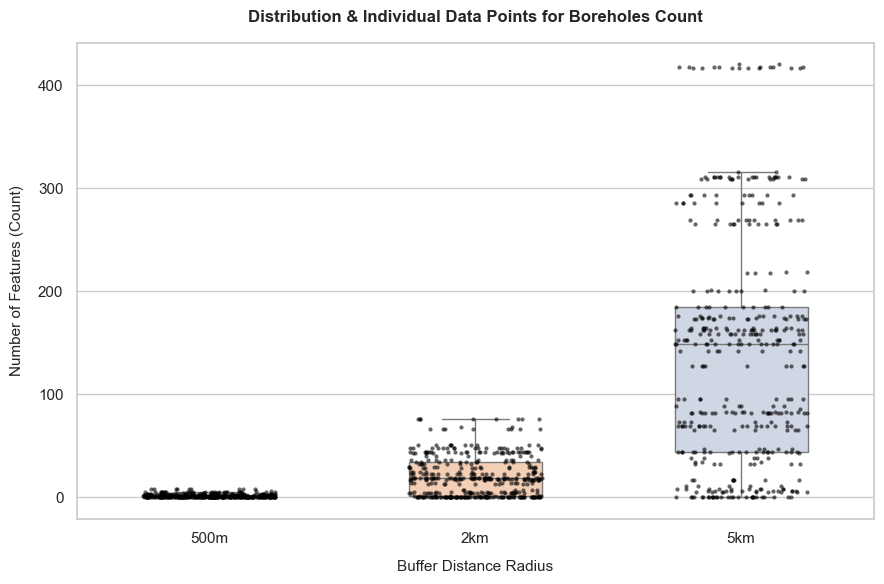

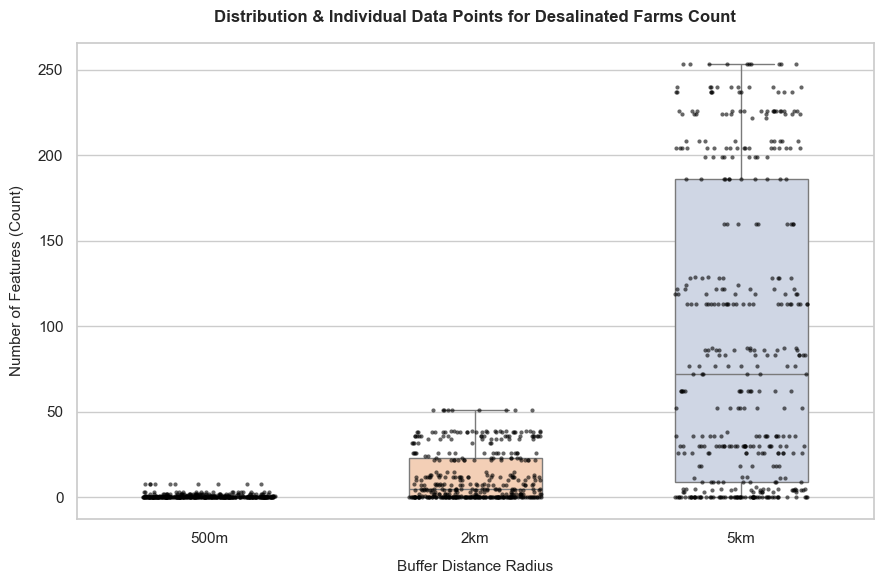

In [86]:
# Create output directory for jitter boxplots
output_dir = OUTPUT_DIR / "infrastructure_buffer_with_jitter"
output_dir.mkdir(parents=True, exist_ok=True)

# 2. Setup targets and chronological spatial distance order
# Mapping feature prefix to display name and column filter keyword
tasks = [
    {
        "name": "Boreholes Count",
        "prefix": "boreholes",
        "filename": "jitter_boxplot_boreholes.png",
        "cols": ["boreholes 500m", "boreholes 2km", "boreholes 5km"],
    },
    {
        "name": "Desalinated Farms Count",
        "prefix": "desalinated",
        "filename": "jitter_boxplot_desalinated_farms.png",
        "cols": [
            "desalinated farms 500m",
            "desalinated farms 2km",
            "desalinated farms 5km",
        ],
    },
]

distance_order = ["500m", "2km", "5km"]

print("Generating grouped box plots with jittered data points for infrastructure counts...\n")

# 3. Process each category
for task in tasks:
    matching_cols = [col for col in task["cols"] if col in df.columns]

    if not matching_cols:
        print(f"Skipping {task['name']}: Columns not found.")
        continue

    # Reshape from Wide to Long format
    sub_df = df[matching_cols].copy()
    melted_df = sub_df.melt(var_name="Buffer_Column", value_name="Count")

    # Extract distance label ('500m', '2km', '5km')
    melted_df["Distance"] = melted_df["Buffer_Column"].apply(
        lambda x: x.split(" ")[-1]
    )

    available_order = [
        dist
        for dist in distance_order
        if dist in melted_df["Distance"].unique()
    ]

    if not available_order:
        continue

    # 4. Plotting Configuration
    plt.figure(figsize=(9, 6))
    sns.set_theme(style="whitegrid")

    # Layer 1: Boxplots with semi-transparent fills and hidden standard outliers
    sns.boxplot(
        x="Distance",
        y="Count",
        data=melted_df,
        order=available_order,
        palette="Pastel2",  # Light background color palette
        width=0.5,
        showfliers=False,  # Stripplot handles point rendering cleanly
    )

    # Layer 2: Jittered Individual Observations (geom_jitter equivalent)
    sns.stripplot(
        x="Distance",
        y="Count",
        data=melted_df,
        order=available_order,
        color="black",  # Contrasting dot color
        size=3,  # Readable dot diameter
        jitter=0.25,  # Width spread of random noise shift
        alpha=0.6,  # Opacity for density view
        linewidth=0,
    )

    # Custom Titles & Labels
    plt.title(
        f"Distribution & Individual Data Points for {task['name']}",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Buffer Distance Radius", fontsize=11, labelpad=10)
    plt.ylabel("Number of Features (Count)", fontsize=11, labelpad=10)
    plt.tight_layout()

   # Save plot and release figure RAM
    file_path = output_dir / task["filename"]
    fig.savefig(file_path, dpi=130)
    plt.close(fig)

    print(f" -> Generated and saved jitter plot for: {task['name']}")

print(
    f"\n🎉 Finished! All infrastructure plots are saved in the '{output_dir}' directory."
)

**Create grouped boxplots with jittered points for median elevation across buffer distances**

C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\161091711.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


🎉 Successfully generated and saved plot to 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\elevation_buffer_with_jitter\jitter_boxplot_elevation_median.png'!


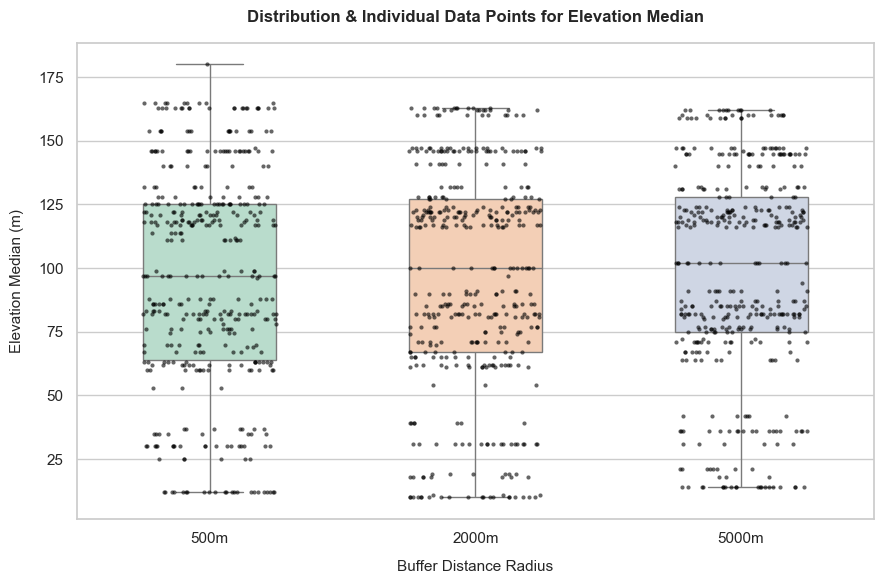

In [87]:
# Create output directory for the elevation plot
output_dir = OUTPUT_DIR / "elevation_buffer_with_jitter"
output_dir.mkdir(parents=True, exist_ok=True)

# 2. Target median elevation columns and define chronological distance order
elev_median_cols = [
    "elev_median_500m",
    "elev_median_2000m",
    "elev_median_5000m",
]
distance_order = ["500m", "2000m", "5000m"]

# 3. Reshape dataset from Wide to Long format
sub_df = df[elev_median_cols].copy()
melted_df = sub_df.melt(var_name="Buffer_Column", value_name="Elevation_m")

# Extract distance label ('500m', '2000m', '5000m')
melted_df["Distance"] = melted_df["Buffer_Column"].apply(
    lambda x: x.split("_")[-1]
)

# 4. Plotting Configuration
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Layer 1: Boxplots with semi-transparent fills and hidden standard outliers
sns.boxplot(
    x="Distance",
    y="Elevation_m",
    data=melted_df,
    order=distance_order,
    palette="Pastel2",  # Light background color palette
    width=0.5,
    showfliers=False,  # Stripplot handles point rendering cleanly
)

# Layer 2: Jittered Individual Observations
sns.stripplot(
    x="Distance",
    y="Elevation_m",
    data=melted_df,
    order=distance_order,
    color="black",  # Contrasting dot color
    size=3,  # Dot size
    jitter=0.25,  # Width spread of random noise shift
    alpha=0.6,  # Opacity for density view
    linewidth=0,
)

# Custom Titles & Labels
plt.title(
    "Distribution & Individual Data Points for Elevation Median",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Buffer Distance Radius", fontsize=11, labelpad=10)
plt.ylabel("Elevation Median (m)", fontsize=11, labelpad=10)
plt.tight_layout()

# 5. Save the output plot
file_path = output_dir / "jitter_boxplot_elevation_median.png"
fig.savefig(file_path, dpi=130)
plt.close(fig)

print(f"🎉 Successfully generated and saved plot to '{file_path}'!")

**Generates land cover statistical summary tables (mean and median) and jittered boxplots to compare coverage across different buffer distances**

Calculating statistical summary table...

=== LANDCOVER METRIC SUMMARY TABLE ===
Metric Distance  Croplands  Water  Trees  Built areas  BareGround  Rangeland  Flooded Vegetation
  Mean     500m     48.082  0.000  0.000       15.328      23.890     12.699                 0.0
  Mean    2000m     55.504  0.106  0.088        6.768      24.105     13.430                 0.0
  Mean    5000m     55.755  0.603  0.034        5.314      24.992     13.302                 0.0
  Mean   10000m     51.039  2.804  0.037        4.508      25.496     16.116                 0.0
Median     500m     49.666  0.000  0.000        0.000       1.257      0.000                 0.0
Median    2000m     66.357  0.000  0.000        1.648      14.379      0.081                 0.0
Median    5000m     57.586  0.000  0.000        3.041      21.564      0.684                 0.0
Median   10000m     51.035  0.006  0.000        1.447      24.296      1.670                 0.0
Saved → landcover_statistical_summary.csv

Gen

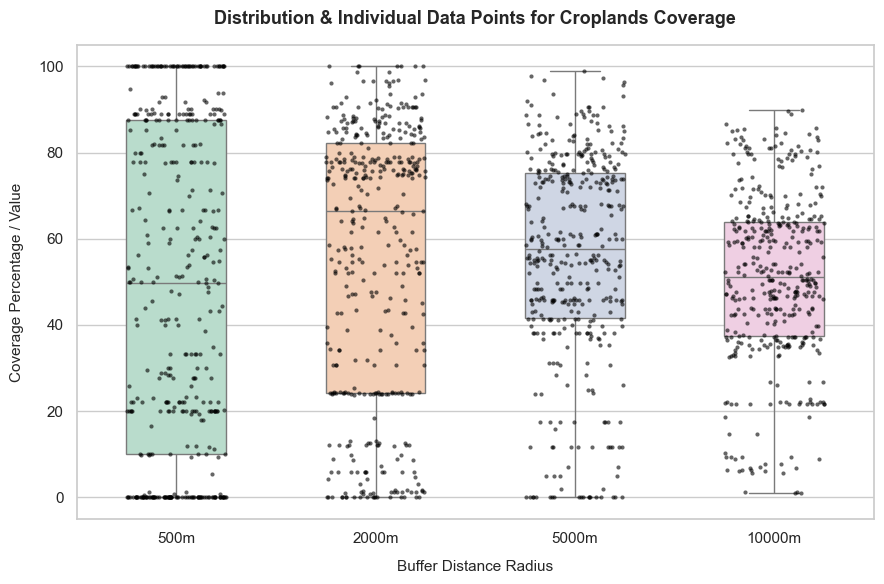

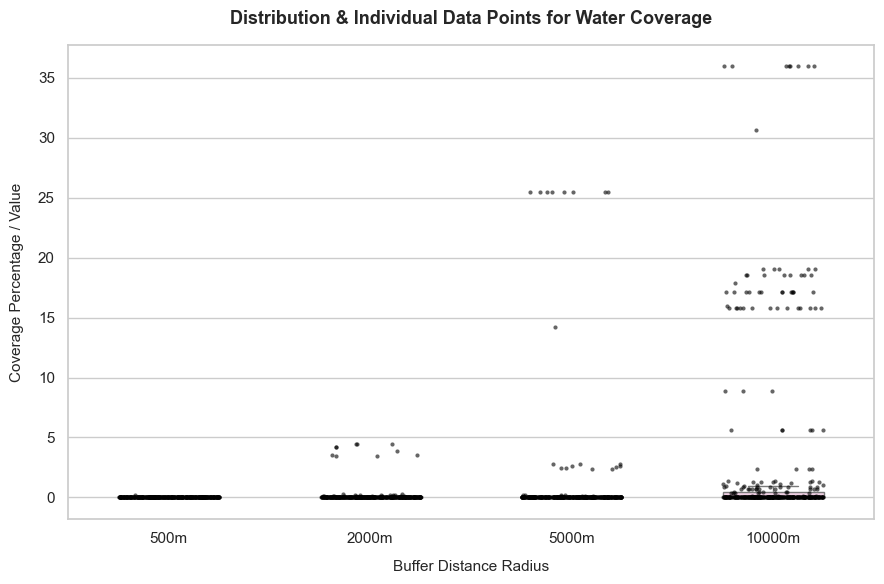

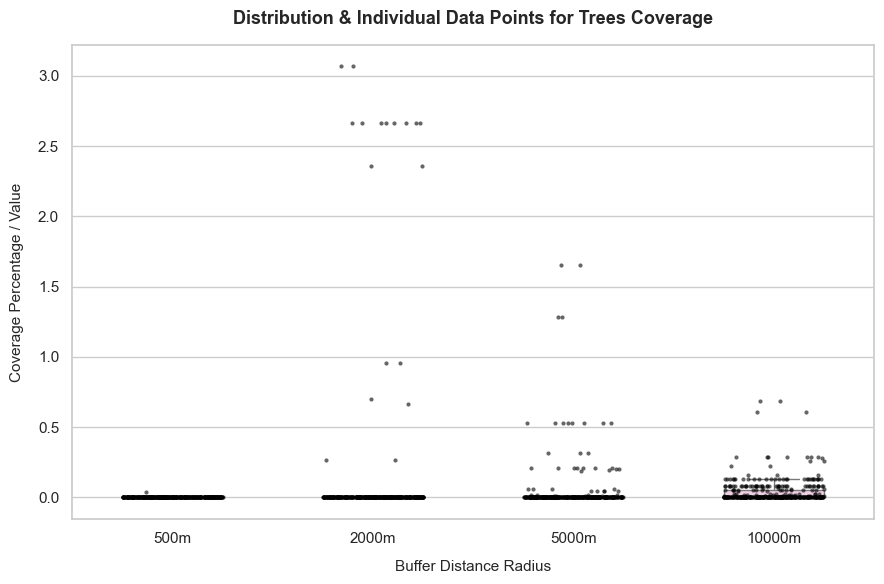

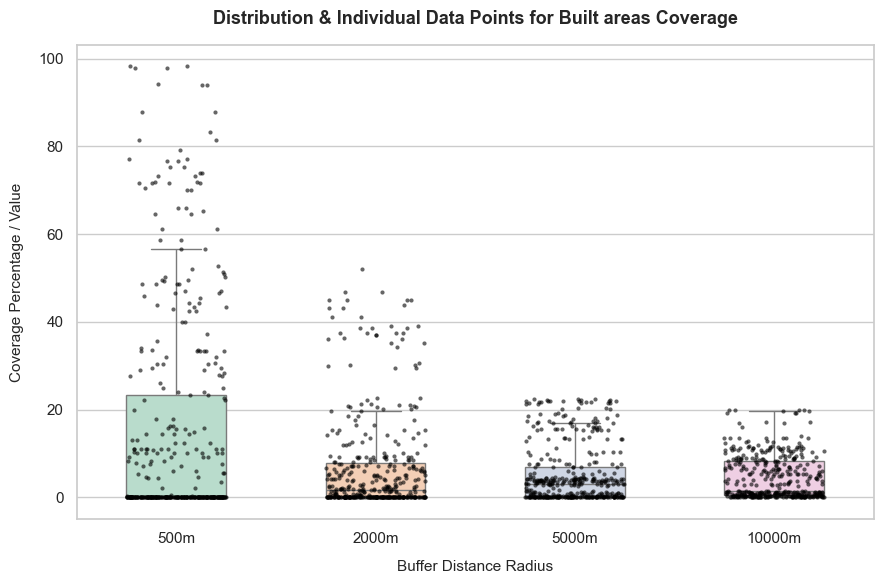

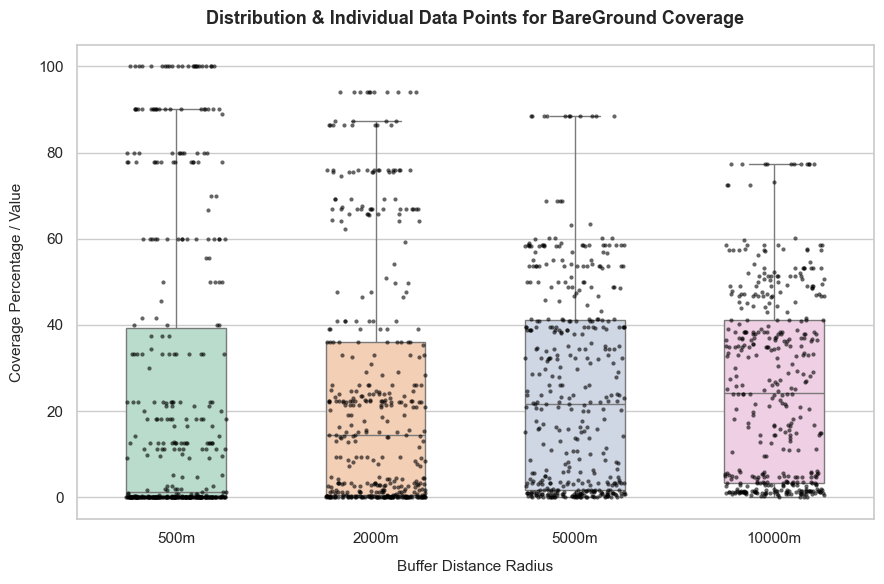

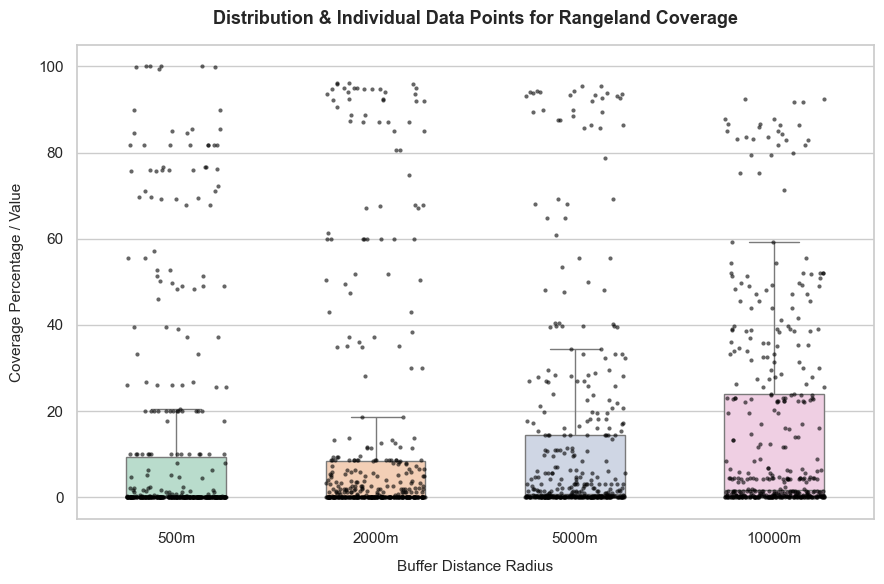

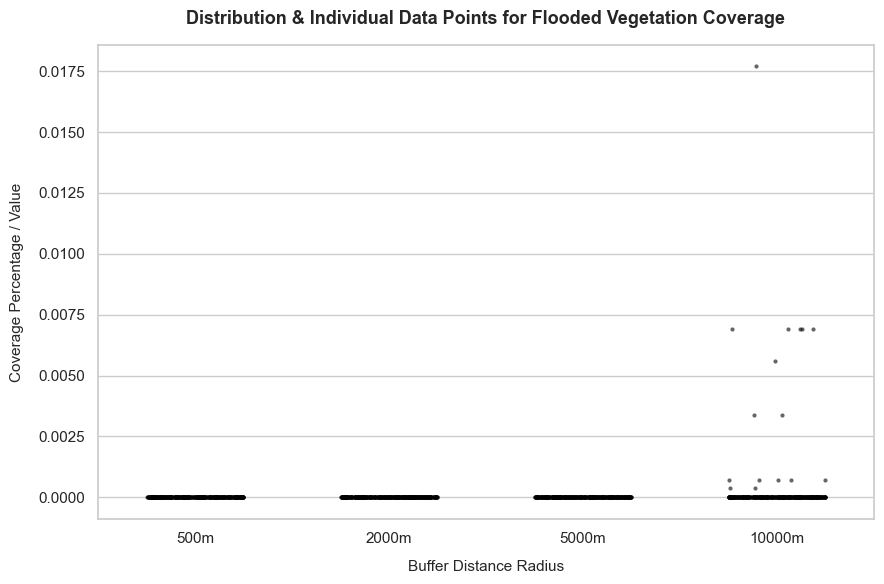

In [88]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# 1. LOAD THE DATASET
# ==========================================
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_temp_2m.csv"
)
df = pd.read_csv(input_path)

# Create clean output directories
plot_dir = OUTPUT_DIR / "landcover_buffer_with_jitter_new"
plot_dir.mkdir(parents=True, exist_ok=True)

# Define landcover mappings to align your dataset column variations with clean display names
# (Added FloodedVeg mapping here)
lc_mapping = {
    "Crops": "Croplands",
    "Water": "Water",
    "Trees": "Trees",
    "BuiltArea": "Built areas",
    "BareGround": "BareGround",
    "Rangeland": "Rangeland",
    "FloodedVeg": "Flooded Vegetation",
}
distance_order = ["500m", "2000m", "5000m", "10000m"]

# ==========================================
# 2. GENERATE THE STATISTICAL SUMMARY TABLE
# ==========================================
print("Calculating statistical summary table...")

# Initialize an empty list to compile our rows dynamically
summary_rows = []

# Loop twice to separate the layout blocks by Metric type
for metric in ["Mean", "Median"]:
    for dist in distance_order:
        # Each row will be identified by Metric (e.g., Mean) and Distance (e.g., 500m)
        row_dict = {"Metric": metric, "Distance": dist}

        for tech_name, clean_name in lc_mapping.items():
            # Build the exact column name used in the dataset (e.g., 'Crops_500m')
            col_name = f"{tech_name}_{dist}"

            if col_name in df.columns:
                # Calculate the statistic safely dropping any missing values
                if metric == "Mean":
                    val = df[col_name].mean()
                else:
                    val = df[col_name].median()
                row_dict[clean_name] = round(val, 3)  # Fills the column cell
            else:
                row_dict[clean_name] = (
                    "N/A"  # Safe fallback if a specific buffer size doesn't exist
                )

        summary_rows.append(row_dict)

# Convert the list of dictionaries into a clean Pandas DataFrame table layout
summary_table = pd.DataFrame(summary_rows)

# Save the table to a CSV file for your supervisor
summary_table_path = OUTPUT_DIR / "landcover_statistical_summary.csv"
summary_table.to_csv(summary_table_path, index=False)

print("\n=== LANDCOVER METRIC SUMMARY TABLE ===")
print(summary_table.to_string(index=False))
print("======================================\nSaved → landcover_statistical_summary.csv")


# ==========================================
# 3. GENERATE THE JITTER BOXPLOTS
# ==========================================
print("\nGenerating grouped box plots with jittered data points...")

for lc, clean_name in lc_mapping.items():
    lc_cols = [col for col in df.columns if col.startswith(f"{lc}_")]
    if not lc_cols:
        continue

    sub_df = df[lc_cols].copy()
    melted_df = sub_df.melt(var_name="Buffer_Column", value_name="Percentage")
    melted_df["Distance"] = melted_df["Buffer_Column"].apply(
        lambda x: x.split("_")[-1]
    )

    available_order = [
        dist for dist in distance_order if dist in melted_df["Distance"].unique()
    ]

    plt.figure(figsize=(9, 6))
    sns.set_theme(style="whitegrid")

    # Layer 1: Faint Boxplots
    sns.boxplot(
        x="Distance",
        y="Percentage",
        data=melted_df,
        order=available_order,
        hue="Distance",  # Explicit assignment to stay current with modern seaborn updates
        legend=False,
        palette="Pastel2",
        width=0.5,
        showfliers=False,
    )

    # Layer 2: Jittered observations (ggplot2 geom_jitter style)
    sns.stripplot(
        x="Distance",
        y="Percentage",
        data=melted_df,
        order=available_order,
        color="black",
        size=3,
        jitter=0.25,
        alpha=0.6,
        linewidth=0,
    )

    plt.title(
        f"Distribution & Individual Data Points for {clean_name} Coverage",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Buffer Distance Radius", fontsize=11, labelpad=10)
    plt.ylabel("Coverage Percentage / Value", fontsize=11, labelpad=10)
    plt.tight_layout()

    file_path = plot_dir / f"jitter_boxplot_{lc.lower()}.png"
    fig.savefig(file_path, dpi=130)
    plt.close(fig)

    print(f" -> Generated and saved jitter plot for: {clean_name}")

print(
    f"\n🎉 Finished! Plots saved to '{plot_dir}' and table saved to '{file_path}'."
)

**Creates a predictor summary table with median, mean, and variance values for each spatial variable across different buffer radius**

In [89]:
import os
import re
import pandas as pd

# 1. LOAD DATASET
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_temp_2m.csv"
)
df = pd.read_csv(input_path)

# 2. MATCH & GROUP SPATIAL COLUMNS
# This function automatically extracts the core variable name and its radius
def parse_spatial_column(col_name):
    match = re.search(r'(_|\s)?(500m|2000m|5000m|10000m)', col_name)
    if match:
        radius = match.group(2)
        # Strip away the distance indicator to isolate the clean Predictor name
        base_predictor = col_name.replace(match.group(0), '').strip('_ ')
        return base_predictor, radius
    return None, None

# 3. BUILD THE TABLE STRUCTURE
rows_list = []

# Scan all columns in the dataset
for col in df.columns:
    base_pred, radius = parse_spatial_column(col)
    
    # Process only if it is a valid spatial predictor column with a radius
    if base_pred and radius:
        # Calculate requested ML preprocessing metrics safely dropping missing rows
        median_val = df[col].median()
        mean_val = df[col].mean()
        variance_val = df[col].var()
        
        rows_list.append({
            'Predictor': base_pred,
            'Radius': radius,
            'Median': round(median_val, 3) if pd.notna(median_val) else "N/A",
            'Mean': round(mean_val, 3) if pd.notna(mean_val) else "N/A",
            'Variance': round(variance_val, 3) if pd.notna(variance_val) else "N/A"
        })

# 4. CONVERT TO DATAFRAME & SORT GEOGRAPHICALLY
summary_df = pd.DataFrame(rows_list)

# Define custom hierarchical sorting rules:
# First sort by Predictor name, then sequentially sequence the radius bounds
radius_rank = {'500m': 1, '2000m': 2, '5000m': 3, '10000m': 4}
summary_df['rank'] = summary_df['Radius'].map(radius_rank)
summary_df = summary_df.sort_values(by=['Predictor', 'rank']).drop(columns=['rank'])

# 5. CLEAN UP DISPLAY PRESENTATION
# To make it easy to read like your sample model layout, we can clear out repeating 
# predictor text so it looks grouped.
summary_df['Predictor'] = summary_df['Predictor'].mask(summary_df['Predictor'].duplicated(), '')

# 6. SAVE AND EXPORT
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

csv_output_path = OUTPUT_DIR / "ml_predictors_radius_summary.csv"
summary_df.to_csv(csv_output_path, index=False)

print("\n=== SAMPLE PREVIEW OF ML RADIAL SUMMARY TABLE ===")
print(summary_df.head(20).to_string(index=False))
print("\n=================================================")
print("🎉 Complete table compiled and saved → 'ml_predictors_radius_summary.csv'")


=== SAMPLE PREVIEW OF ML RADIAL SUMMARY TABLE ===
                      Predictor Radius  Median   Mean  Variance
                             A%   500m   0.000  0.000     0.000
                                 2000m   0.000  0.000     0.000
                                 5000m   0.000  0.000     0.000
                            AL%   500m   0.000  0.000     0.000
                                 2000m   0.000  0.011     0.002
                                 5000m   0.000  0.060     0.205
                     BareGround   500m   1.257 23.890  1153.045
                                 2000m  14.379 24.105   799.491
                                 5000m  21.564 24.992   555.813
                                10000m  24.296 25.496   469.155
                      BuiltArea   500m   0.000 15.328   628.841
                                 2000m   1.648  6.768   125.216
                                 5000m   3.041  5.314    45.436
                                10000m   1.447  4.508

**Creates ML preparation summary tables and generates boxplots for salinity and river distance variables to analyze predictor distributions**

In [90]:
# ==========================================
# 1. LOAD DATASET & PREPARE PATHS (PATHLIB)
# ==========================================
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_temp_2m.csv"
)
df = pd.read_csv(input_path)

output_dir = OUTPUT_DIR / "ml_prep_plots"
output_dir.mkdir(parents=True, exist_ok=True)

# Define landcover mappings
lc_mapping = {
    "Crops": "Croplands",
    "Water": "Water",
    "Trees": "Trees",
    "BuiltArea": "Built areas",
    "BareGround": "BareGround",
    "Rangeland": "Rangeland",
    "FloodedVeg": "Flooded Vegetation",
}
distance_order = ["500m", "2000m", "5000m", "10000m"]

# ==========================================
# 2. GENERATE COMPREHENSIVE SUMMARY TABLE
# ==========================================
print("Compiling summary table...")

# A. Calculate overall Salinity (EC) metrics first
ec_median = df["ec"].median() if "ec" in df.columns else None
ec_mean = df["ec"].mean() if "ec" in df.columns else None
ec_var = df["ec"].var() if "ec" in df.columns else None

summary_rows = [
    {
        "Predictor": "Salinity (EC)",
        "Radius": "Overall Basin",
        "Median": round(ec_median, 3) if pd.notna(ec_median) else "N/A",
        "Mean": round(ec_mean, 3) if pd.notna(ec_mean) else "N/A",
        "Variance": round(ec_var, 3) if pd.notna(ec_var) else "N/A",
    }
]

# B. Append grouped landcover metrics
for col_name in df.columns:
    match = re.search(r"(_|\s)?(500m|2000m|5000m|10000m)", col_name)
    if match:
        radius = match.group(2)
        base_pred = col_name.replace(match.group(0), "").strip("_ ")

        if base_pred in lc_mapping:
            clean_name = lc_mapping[base_pred]

            median_val = df[col_name].median()
            mean_val = df[col_name].mean()
            variance_val = df[col_name].var()

            summary_rows.append({
                "Predictor": clean_name,
                "Radius": radius,
                "Median": (
                    round(median_val, 3) if pd.notna(median_val) else "N/A"
                ),
                "Mean": round(mean_val, 3) if pd.notna(mean_val) else "N/A",
                "Variance": (
                    round(variance_val, 3) if pd.notna(variance_val) else "N/A"
                ),
            })

summary_df = pd.DataFrame(summary_rows)


# C. SORTING LOGIC
def compute_predictor_sort_order(pred_name):
    if pred_name == "Salinity (EC)":
        return 0
    return 1


radius_ranks = {
    "500m": 1,
    "2000m": 2,
    "5000m": 3,
    "10000m": 4,
    "Overall Basin": 0,
}

summary_df["pred_group"] = summary_df["Predictor"].apply(
    compute_predictor_sort_order
)
summary_df["rad_rank"] = summary_df["Radius"].map(radius_ranks)

summary_df = summary_df.sort_values(by=["pred_group", "Predictor", "rad_rank"])
summary_df = summary_df.drop(columns=["pred_group", "rad_rank"])

summary_df["Predictor"] = summary_df["Predictor"].mask(
    summary_df["Predictor"].duplicated()
    & (summary_df["Predictor"] != "Salinity (EC)"),
    "",
)

# Export summary CSV using pathlib
table_output_path = OUTPUT_DIR / "ml_predictors_radius_summary_2.csv"
summary_df.to_csv(table_output_path, index=False)
print(f" -> Saved table layout to '{table_output_path}'")


# ==========================================
# 3. GENERATE SALINITY (EC) BOXPLOT
# ==========================================
if "ec" in df.columns:
    print("\nPlotting Salinity (EC) Boxplot...")
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(6, 6))

    ec_data = df["ec"].dropna()
    sns.boxplot(
        y=ec_data,
        x=["Salinity"] * len(ec_data),
        hue=["Salinity"] * len(ec_data),
        legend=False,
        palette=["#fbc4b6"],
        width=0.3,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        y=ec_data,
        x=["Salinity"] * len(ec_data),
        color="black",
        size=4,
        jitter=0.15,
        alpha=0.5,
        linewidth=0,
        ax=ax,
    )

    ax.set_title(
        "Groundwater Salinity Distribution (EC)",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )
    ax.set_ylabel("Electrical Conductivity (µS/cm)", fontsize=11, labelpad=10)
    ax.set_xlabel("")
    fig.tight_layout()

    salinity_plot_path = output_dir / "boxplot_salinity_ec.png"
    fig.savefig(salinity_plot_path, dpi=130)
    plt.close(fig)


# ==========================================
# 4. GENERATE DISTANCE TO RIVERS BOXPLOT
# ==========================================
river_cols = [
    col
    for col in [
        "dist_to_river_class_1",
        "dist_to_river_class_2",
        "dist_to_river_class_3",
    ]
    if col in df.columns
]

if river_cols:
    print("Plotting Distance to River Classes Boxplot...")

    river_df = df[river_cols].melt(
        var_name="River_Class", value_name="Distance"
    )
    river_df["River_Class"] = river_df["River_Class"].replace({
        "dist_to_river_class_1": "Class 1 Major",
        "dist_to_river_class_2": "Class 2 Stream",
        "dist_to_river_class_3": "Class 3 Tributary",
    })

    fig, ax = plt.subplots(figsize=(9, 6))

    sns.boxplot(
        x="River_Class",
        y="Distance",
        data=river_df,
        hue="River_Class",
        legend=False,
        palette="Pastel1",
        width=0.4,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        x="River_Class",
        y="Distance",
        data=river_df,
        color="black",
        size=2.5,
        jitter=0.2,
        alpha=0.4,
        linewidth=0,
        ax=ax,
    )

    ax.set_title(
        "Proximity Distance Distribution to Hydrological Networks",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("River Classification Hierarchy", fontsize=11, labelpad=10)
    ax.set_ylabel("Proximity Distance Range (Meters)", fontsize=11, labelpad=10)
    fig.tight_layout()

    river_plot_path = output_dir / "boxplot_distance_to_rivers.png"
    fig.savefig(river_plot_path, dpi=130)
    plt.close(fig)

print(
    f"\n🎉 Verification complete! Plots saved in '{output_dir}' and table saved to '{table_output_path}'."
)

Compiling summary table...
 -> Saved table layout to 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\ml_predictors_radius_summary_2.csv'

Plotting Salinity (EC) Boxplot...
Plotting Distance to River Classes Boxplot...

🎉 Verification complete! Plots saved in 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\ml_prep_plots' and table saved to 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\ml_predictors_radius_summary_2.csv'.


**Adds salinity classes based on EC values and exports the updated dataset with the new classification column**

In [91]:
def assign_salinity_class(ec):
    if pd.isna(ec):
        return np.nan
    elif ec<700:
        return 1
    elif 700 <= ec <= 3000:
        return 2
    elif ec >3000:
        return 3
    return np.nan

df['Salinity_classes'] = df['ec'].apply(assign_salinity_class)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_filename = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_salinity_classes.csv"
)
df.to_csv(output_filename, index=False)

print(f"Successfully! added the salinity classes")
print(df['Salinity_classes'].value_counts())

Successfully! added the salinity classes
Salinity_classes
2    295
1     58
3     57
Name: count, dtype: int64


C:\Users\G.Mayuran\AppData\Local\Temp\ipykernel_7464\3977212963.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Salinity_classes'] = df['ec'].apply(assign_salinity_class)


**Calculates feature statistics (mean, median, variance, and percentage of zero values) to support feature reduction analysis**

In [92]:
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_salinity_classes.csv"
)
df = pd.read_csv(input_path)
# Select numeric spatial, land cover, geology, and distance columns for analysis
exclude_cols = ['code.x','date','longitude','latitude','t','p_h','ec','year','Salinity_classes']
numeric_cols = df.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

# Initialize list to hold statistical results
stats_list = []

for col in feature_cols:
    col_data = df[col].dropna()
    if len(col_data) == 0:
        continue

    mean_val = col_data.mean()
    median_val = col_data.median()
    variance_val = col_data.var()

    # Calculate percentage of zero values
    zero_count  = (col_data == 0).sum()
    pct_zero  = (zero_count /len(col_data)) *100

    stats_list.append({
        'variable':col,
        'mean':mean_val,
        'median':median_val,
        'variance':variance_val,
        'pct_zero':pct_zero
    })

#convert to dataframe
stats_df = pd.DataFrame(stats_list)

#Sort by ppercentage of zero descending(to identify sparse feature first)

stats_df = stats_df.sort_values(by='pct_zero', ascending=False)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_file = OUTPUT_DIR / "Feature_Reduction_Statistics.csv"
stats_df.to_csv(output_file, index=False)

print(f"Feature reduction statistics calculated and saved to: {output_file}")



Feature reduction statistics calculated and saved to: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\Feature_Reduction_Statistics.csv


**Replaces zero values with NA for selected variables and exports a cleaned dataset for further analysis**

In [93]:
import numpy as np
import pandas as pd

# 1. Load your dataset
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_salinity_classes.csv"
)
df = pd.read_csv(input_path)

# 2. Convert all zeros to safe NaN objects for columns: t, p_h, and ec
target_cols = ["t", "p_h", "ec"]
df[target_cols] = df[target_cols].replace(0, np.nan)

# 3. Export to CSV while mapping all NaN values to explicit 'NA' text strings
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_file = (
    OUTPUT_DIR
    / "Dataset_Combined_1986_2025_with_salinity_classes_cleaned.csv"
)
df.to_csv(output_file, index=False, na_rep="NA")

print("Processing complete! Zeros successfully replaced with 'NA'.")

Processing complete! Zeros successfully replaced with 'NA'.


**Generates historical EC timelines for wells with missing values and highlights missing records for quality assessment**

In [94]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the cleaned dataset
input_path = (
    OUTPUT_DIR
    / "Dataset_Combined_1986_2025_with_salinity_classes_cleaned.csv"
)
df = pd.read_csv(input_path, na_values=["NA"])
# 2. Parse dates and sort the dataset chronologically
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values(by=["code.x", "date"])

# 3. Identify which unique wells have missing EC records
missing_ec_wells = df[df["ec"].isna()]["code.x"].unique()
print(f"Wells with missing EC values: {missing_ec_wells}")

# 4. Set up the plotting canvas (3 rows, 2 columns)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))
axes = axes.flatten()  # Flatten the 2D grid array into a 1D list for easy looping

# 5. Loop through each well and build its timeline
for i, well in enumerate(missing_ec_wells):
    ax = axes[i]
    well_data = df[df["code.x"] == well]

    # Plot existing EC historical line and markers
    ax.plot(
        well_data["date"],
        well_data["ec"],
        marker="o",
        linestyle="-",
        color="teal",
        label="Available EC",
    )

    # Find the timestamps where EC is missing and draw red vertical dashed indicators
    missing_dates = well_data[well_data["ec"].isna()]["date"]
    for j, md in enumerate(missing_dates):
        # Apply the label only to the first vertical line to keep the legend clean
        label = "Missing EC (NA)" if j == 0 else ""
        ax.axvline(x=md, color="red", linestyle="--", alpha=0.7, label=label)

    # Subplot styling
    ax.set_title(f"Well {well} - Historical EC Timeline", fontsize=11, pad=8)
    ax.set_xlabel("Date", fontsize=9)
    ax.set_ylabel("EC", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="lower right", fontsize=9)

# Adjust layout structure cleanly to prevent overlapping labels
plt.tight_layout()

# 6. Save the high-resolution visualization block 
output_image = OUTPUT_DIR / "historical_ec_missing_wells.png"
plt.savefig(output_image, dpi=300)
plt.close()

print(f"Successfully generated and saved historical timeline grid as: {output_image}")

Wells with missing EC values: <StringArray>
['1037/69', '1205/78', '13/69', '4130/70', '471/69', '5089/70']
Length: 6, dtype: str
Successfully generated and saved historical timeline grid as: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\historical_ec_missing_wells.png


**Creates individual historical EC timeline plots for wells with missing values and saves them for inspection**

In [95]:
# ==========================================
# 1. LOAD DATASET VIA PATHLIB
# ==========================================
input_path = (
    OUTPUT_DIR
    / "Dataset_Combined_1986_2025_with_salinity_classes_cleaned.csv"
)
df = pd.read_csv(input_path, na_values="NA")

# ==========================================
# 2. PARSE DATES & CHRONOLOGICAL SORT
# ==========================================
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values(by=["code.x", "date"])

# ==========================================
# 3. IDENTIFY WELLS WITH MISSING EC & CREATE SUBDIRECTORY
# ==========================================
missing_ec_wells = df[df["ec"].isna()]["code.x"].unique()

# Define output folder as a Path object inside OUTPUT_DIR
output_folder = OUTPUT_DIR / "individual_ec_plots"
output_folder.mkdir(parents=True, exist_ok=True)

# ==========================================
# 4. LOOP THROUGH EACH WELL AND BUILD PLOT
# ==========================================
for well in missing_ec_wells:
    fig, ax = plt.subplots(figsize=(8, 5))

    well_data = df[df["code.x"] == well]

    # Plot existing EC historical line and markers
    ax.plot(
        well_data["date"],
        well_data["ec"],
        marker="o",
        linestyle="-",
        color="teal",
        label="Available EC",
    )

    # Find timestamps where EC is missing and draw red vertical dashed lines
    missing_dates = well_data[well_data["ec"].isna()]["date"]
    for j, md in enumerate(missing_dates):
        label = "Missing EC (NA)" if j == 0 else ""
        ax.axvline(x=md, color="red", linestyle="--", alpha=0.7, label=label)

    # Clean up well name to create a safe filename
    safe_well_name = str(well).replace("/", "_").replace("\\", "_")

    # Chart formatting and labeling
    ax.set_title(f"Well {well} - Historical EC Timeline", fontsize=12, pad=10)
    ax.set_xlabel("Date", fontsize=10)
    ax.set_ylabel("EC (µS/cm)", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="best", fontsize=10)
    fig.tight_layout()

    # ==========================================
    # 5. SAVE STANDALONE FILE VIA PATHLIB
    # ==========================================
    file_path = output_folder / f"well_{safe_well_name}_ec.png"
    fig.savefig(file_path, dpi=150)
    plt.close(fig)  # Clear memory for the next loop execution

print(
    f"Success! Saved individual plots for {len(missing_ec_wells)} wells in: {output_folder}"
)

Success! Saved individual plots for 6 wells in: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\individual_ec_plots


**Interpolate missing EC values and save the cleaned dataset**

In [96]:
import numpy as np
import pandas as pd

# 1. Load dataset - ensure 'NA' text strings are recognized as NaNs
input_path = (
    OUTPUT_DIR
    / "Dataset_Combined_1986_2025_with_salinity_classes_cleaned.csv"
)
df = pd.read_csv(input_path, na_values=["NA"])

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. Convert dates and sort chronologically
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values(by=["code.x", "date"]).reset_index(drop=True)

# 3. Target wells to impute
target_wells = ["471/69", "1037/69", "1205/78"]

print("=" * 60)
print(" 1. IMPUTATION REPORT FOR TARGET WELLS")
print("=" * 60)

# --- STEP A: Calculate and Print Imputed Values ---
for well in target_wells:
    mask = df["code.x"] == well
    well_df = df[mask].copy()

    # Find rows with missing EC
    missing_rows = well_df[well_df["ec"].isna()]

    if not missing_rows.empty:
        # Perform interpolation
        df.loc[mask, "ec"] = df.loc[mask, "ec"].interpolate(
            method="linear", limit_direction="both"
        )
        updated_well_df = df[mask]

        for idx in missing_rows.index:
            filled_val = updated_well_df.loc[idx, "ec"]
            date_val = updated_well_df.loc[idx, "date"].strftime("%Y-%m-%d")
            print(
                f"• Well: {well:<10} | Date: {date_val} | Filled EC Mean Value: {filled_val:.2f}"
            )
    else:
        print(f"• Well: {well:<10} | No missing EC records found.")

print("\n" + "=" * 60)
print(" 2. DROPPED ROWS REPORT FOR OTHER WELLS")
print("=" * 60)

# --- STEP B: Identify and Drop Missing Rows for Other Wells ---
other_wells_missing_mask = (~df["code.x"].isin(target_wells)) & (
    df["ec"].isna()
)
dropped_df = df[other_wells_missing_mask]

if not dropped_df.empty:
    print(f"Total rows removed: {len(dropped_df)}")
    print("\nSummary of removed rows by Well ID:")
    dropped_summary = (
        dropped_df.groupby("code.x")["date"]
        .apply(lambda dates: [d.strftime("%Y-%m-%d") for d in dates])
        .to_dict()
    )

    for well_id, dates in dropped_summary.items():
        print(f"• Well ID '{well_id}': Removed {len(dates)} row(s) on {dates}")
else:
    print("No rows needed to be dropped.")

# Create clean dataframe without the dropped rows
df_cleaned = df[~other_wells_missing_mask].copy()

print("\n" + "=" * 60)
# 4. Save updated dataset (na_rep="NA" ensures NaN values export as 'NA')
output_file = (
    OUTPUT_DIR
    / "Dataset_Combined_1986_2025_with__salinity_classes_cleaned_interpolated.csv"
)
df_cleaned.to_csv(output_file, index=False, na_rep="NA")
print(f"SUCCESS: Saved updated dataset to '{output_file}'.")

 1. IMPUTATION REPORT FOR TARGET WELLS
• Well: 471/69     | Date: 2014-01-01 | Filled EC Mean Value: 1345.00
• Well: 1037/69    | Date: 1991-08-09 | Filled EC Mean Value: 958.00
• Well: 1205/78    | Date: 1991-08-15 | Filled EC Mean Value: 930.00

 2. DROPPED ROWS REPORT FOR OTHER WELLS
Total rows removed: 3

Summary of removed rows by Well ID:
• Well ID '13/69': Removed 1 row(s) on ['2004-01-01']
• Well ID '4130/70': Removed 1 row(s) on ['1991-08-07']
• Well ID '5089/70': Removed 1 row(s) on ['1988-07-12']

SUCCESS: Saved updated dataset to 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\Dataset_Combined_1986_2025_with__salinity_classes_cleaned_interpolated.csv'.


**Merge NDVI data with the cleaned dataset and save the updated file**

In [97]:


# Load the NDVI dataset
ndvi_path = DATA_DIR / "DataBaseChtoukaFinal_WGS" / "Landsat_32Day_NDVI_Chtouka_Buffers_and_Basin_CSV_Final.csv"
df_ndvi = pd.read_csv(ndvi_path, na_values="NA")

# 1. Standardize dates to datetime format
df_cleaned["date"] = pd.to_datetime(df_cleaned["date"], errors="coerce")
df_ndvi["date"] = pd.to_datetime(df_ndvi["date"], errors="coerce")

# Determine well code column in df_cleaned (code.x or well_code)
well_col = "code.x" if "code.x" in df_cleaned.columns else "well_code"

# 2. Extract key columns from NDVI dataset
ndvi_cols = [
    "well_code",
    "date",
    "ndvi_30m_mean",
    "ndvi_100m_mean",
    "ndvi_500m_mean",
    "ndvi_allbasin_mean",
]
ndvi_subset = df_ndvi[ndvi_cols].drop_duplicates(subset=["well_code", "date"])

# 3. Merge ndvi columns into df_cleaned
df_cleaned = pd.merge(
    df_cleaned,
    ndvi_subset,
    left_on=[well_col, "date"],
    right_on=["well_code", "date"],
    how="left",
)

# Clean up duplicate 'well_code' column if created during merge
if "well_code" in df_cleaned.columns and well_col != "well_code":
    df_cleaned = df_cleaned.drop(columns=["well_code"])

# 4. Save the updated dataset (na_rep="NA" preserves 'NA' strings for missing t, p_h, and NDVI values)
output_file = (
    OUTPUT_DIR
    / "Dataset_Combined_1986_2025_with_NDVI_final.csv"
)
df_cleaned.to_csv(output_file, index=False, na_rep="NA")

print("SUCCESS!")
print(f"Total rows in df_cleaned: {len(df_cleaned)}")
print(f"Rows with merged ndvi_mean: {df_cleaned['ndvi_30m_mean'].notna().sum()}")
print(f"Saved to: '{output_file}'")

SUCCESS!
Total rows in df_cleaned: 407
Rows with merged ndvi_mean: 407
Saved to: 'C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\Dataset_Combined_1986_2025_with_NDVI_final.csv'


**Calculates feature statistics (mean, median, variance, and percentage of zero values) to support feature reduction analysis**

In [98]:
input_path = (
    OUTPUT_DIR / "Dataset_Combined_1986_2025_with_NDVI_final.csv"
)
df = pd.read_csv(input_path)
# Select numeric spatial, land cover, geology, and distance columns for analysis
exclude_cols = ['code.x','date','longitude','latitude','t','p_h','ec','year','Salinity_classes']
numeric_cols = df.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

# Initialize list to hold statistical results
stats_list = []

for col in feature_cols:
    col_data = df[col].dropna()
    if len(col_data) == 0:
        continue

    mean_val = col_data.mean()
    median_val = col_data.median()
    variance_val = col_data.var()

    # Calculate percentage of zero values
    zero_count  = (col_data == 0).sum()
    pct_zero  = (zero_count /len(col_data)) *100

    stats_list.append({
        'variable':col,
        'mean':mean_val,
        'median':median_val,
        'variance':variance_val,
        'pct_zero':pct_zero
    })

#convert to dataframe
stats_df = pd.DataFrame(stats_list)

#Sort by ppercentage of zero descending(to identify sparse feature first)

stats_df = stats_df.sort_values(by='pct_zero', ascending=False)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_file = OUTPUT_DIR / "Feature_Reduction_Statistics_latest_one.csv"
stats_df.to_csv(output_file, index=False)
 

print(f"Feature reduction statistics calculated and saved to: {output_file}")



Feature reduction statistics calculated and saved to: C:\Users\G.Mayuran\OneDrive - CGIAR\Desktop\geo_project\output\Feature_Reduction_Statistics_latest_one.csv
